## Roughness scaling: spatial decomposition

_T0/T1/T2 variance decomposition of n_e/⟨n⟩, OLS and ML regression models, hybrid predictions, and pattern–forcing interactions._


In [13]:
import warnings
warnings.filterwarnings("ignore")


import os
import os as _os
import sys
import shutil
import itertools as it
import contextlib
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler
import statsmodels.formula.api as smf
import json
from scipy.stats import gmean
import pandas as pd

sys.path.append("/Users/octaviacrompton/Projects/roughness-scale/swof_code")


import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

In [14]:
# ── Figure registry (src/figure_registry.py) ──────────────────────────────────
import sys as _sys
_sys.path.insert(0, "/Users/octaviacrompton/Projects/roughness-scale/src")
import figure_registry as _fig_reg

# Expose convenience names so all figure-saving cells work unchanged
_fig_dirs              = _fig_reg._fig_dirs
update_figure_registry = _fig_reg.update_figure_registry

# Note: call _fig_reg.configure(out_dir) once out_dir is set (see data-load cell)

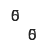

In [15]:
my_modules = ['plot_SWOF', "read_SWOF", "write_SWOF", 
              "plot_config", "topo", "source_functions_1p3"]

for mod in my_modules:
    if mod in sys.modules: 
        del sys.modules[mod] 

from plot_SWOF import *
from read_SWOF import *
from plot_config import *
from topo import *
from write_SWOF import *
from source_functions_1p3 import *

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [16]:
project_dir = "/Users/octaviacrompton/Dropbox/FullCSWOF/Tests/"
cases = [d for d in os.listdir(project_dir) if 
            ('DS_Store' not in d) and ('figures' not in d)]


In [17]:

# out_dir must match what was used in roughness_scale-load-compute
out_dir   = os.path.join(project_dir, 'runaround_smooth')
slim_path = os.path.join(out_dir, 'summary_slim.pkl')

summary = pd.read_pickle(slim_path)
summary.loc[summary['veg_type'] == 'band',   'aniso'] =  3
summary.loc[summary['veg_type'] == 'v_band', 'aniso'] = -3
print(f'Loaded summary_slim: shape = {summary.shape}')
print('Columns:', sorted(summary.columns.tolist()))

# initialise figure registry for this session
_fig_reg.configure(out_dir, notebook_name='roughness_scale-decomp.ipynb')

Loaded summary_slim: shape = (1260, 342)
Columns: ['$p t_r$', '<Sf>', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_T0', '<Sf>_T0_hyb', '<Sf>_T1', '<Sf>_T2', '<Sf>_Ubar2_np2', '<Sf>_cross_nU', '<Sf>_direct', '<Sf>_direct_minus_exp2', '<Sf>_direct_wet', '<Sf>_exp2', '<Sf>_hyb_Up2', '<Sf>_hyb_base', '<Sf>_hyb_cross', '<Sf>_hyb_np2', '<Sf>_hyb_num_sum', '<Sf>_hybrid_quad', '<Sf>_nbar2_Ubar2', '<Sf>_nbar2_Up2', '<Sf>_nd_T0', '<Sf>_nd_T1', '<Sf>_nd_T2', '<Sf>_nd_sumK2', '<Sf>_series2', '<U dU/dx>', '<U>', '<U>/<h>', '<U><dU/dx>', '<U>^2/<Up^2>', '<U>_CF', '<Ua>', '<Uh>', '<Up dUp/dx>', '<Up hp>', '<Up2>', '<dU/dx>', '<dh/dx>', '<dhp/dx>', '<eta ups>', '<eta2>', '<h>', '<h>_CF', '<h^2/3>', '<ha>', '<hp2>', '<n2>', '<n2><h>^-4/3', '<n>', '<n>2', '<n><U>', '<nU>', '<na>', '<np Up>', '<np hp>', '<np2>', '<q>_direct', '<q>_hform', '<q>_uform', '<r eta>', '<r ups>', '<r2>', '<ups2>', 'B_bc_NF', 'B_bc_init', 'Bbound', 'C', 'CPU_time', 'Cd', 'Cd_misc', 'Choice_dt_specific_points', 'Choice_points', 'F

In [18]:
# ── Variable naming / display labels ──────────────────────────────────────────
# Shared labels, colour maps, and helpers live in src/labels.py
import sys as _sys
_sys.path.insert(0, "/Users/octaviacrompton/Projects/roughness-scale/src")
from labels import (
    updates, rename, renameit,
    VEG_COLORS, VEG_LABELS,
    FS_LABEL, FS_TITLE, FS_TICK, FS_LEG,
    VAR_CMAPS,
    format_name as _format_name_raw,
)

# Wrap format_name so callers don't need to pass `names` explicitly
def format_name(fld, updates=updates):
    return _format_name_raw(fld, names, updates=updates)

summary['LB_std'] = [l.std() for l in summary.LB_dist]

# ── Toggle: set USE_HYDRO = True to make 'effect_ratio' use hydrograph-based n_e
USE_HYDRO = False
if USE_HYDRO:
    summary['effect']       = summary['effect_hydro']
    summary['effect_ratio'] = summary['effect_ratio_hydro']


In [19]:
## 

## Spatial pattern 

In [20]:
summary['effect_ratio_T0'] = np.sqrt(1 + summary['<r2>'] + summary['<ups2>'] + 4*summary['<r ups>'])

# T1: adds first-order depth-fluctuation correction (negative sign)
summary['effect_ratio_T1'] = np.sqrt(1 + summary['<r2>'] + summary['<ups2>'] + 4*summary['<r ups>'])
        #    - 8/3*(summary['<r eta>'] + summary['<eta ups>'])    
        
summary['effect_ratio_T2'] = np.sqrt(
    1 + summary['<r2>'] + summary['<ups2>'] + 4*summary['<r ups>']
    - 8/3*(summary['<r eta>'] + summary['<eta ups>'])
    + 14/9*summary['<eta2>'])        
       
    
# Aliases for convenience
summary["ER_obs"] = summary["effect_ratio"]
summary["ER_Q"]   = summary.get("effect_ratio_Q", np.nan)
summary["ER_leading"] =  summary['So'] / summary['<Sf>_nbar2_Ubar2']

# ---------------------------
# 1) Residuals vs observed
# ---------------------------
summary["res_Q"] = summary["ER_Q"] - summary["ER_obs"]

# ---------------------------
# 2) Fit metrics (bias, MAE, RMSE, R^2)
# ---------------------------
def fit_metrics(yhat, y):
    m = np.isfinite(yhat) & np.isfinite(y)
    if m.sum() < 3:
        return dict(n=int(m.sum()), bias=np.nan, mae=np.nan, rmse=np.nan, r2=np.nan)
    dy = yhat[m] - y[m]
    bias = float(np.mean(dy))
    mae  = float(np.mean(np.abs(dy)))
    rmse = float(np.sqrt(np.mean(dy**2)))
    r = float(np.corrcoef(yhat[m], y[m])[0,1])
    return dict(n=int(m.sum()), bias=bias, mae=mae, rmse=rmse, r2=r**2)

m_Q = fit_metrics(summary["ER_Q"].to_numpy(float), summary["ER_obs"].to_numpy(float))
m_Qpred2 = fit_metrics(summary["effect_ratio_Qpred2"].to_numpy(float), summary["ER_obs"].to_numpy(float))

m_T0 = fit_metrics(summary["effect_ratio_T0"].to_numpy(float), summary["ER_obs"].to_numpy(float))
m_T1 = fit_metrics(summary["effect_ratio_T1"].to_numpy(float), summary["ER_obs"].to_numpy(float))
m_T2 = fit_metrics(summary["effect_ratio_T2"].to_numpy(float), summary["ER_obs"].to_numpy(float))

m_L = fit_metrics(summary["ER_leading"].to_numpy(float), summary["ER_obs"].to_numpy(float))

def print_metrics(label, m):
    print(f"{label}: n={m['n']}, "
          f"bias={m['bias']:.3f}, mae={m['mae']:.3f}, "
          f"rmse={m['rmse']:.3f}, r2={m['r2']:.3f}")

print("\n=== Effect ratio vs observed ===")
print_metrics("Q-based  vs obs", m_Q)

# ---------------------------
# 3) Correlate residuals with drivers → combined table
# ---------------------------
drivers = ["<r2>", "<ups2>", "<eta2>", "<r ups>", "<r eta>", "<n>"]
drivers = [c for c in drivers if c in summary.columns]

def corr_to_res(yname):
    rows = []
    for d in drivers:
        xy = summary[[yname, d]].dropna()
        if len(xy) >= 3:
            r = np.corrcoef(xy[yname], xy[d])[0, 1]
            rows.append({"variable": yname, "var": d, "pearson_r": r})
    return pd.DataFrame(rows)

# Compute for Q residuals
residuals = ["res_Q"]
combined_corr = pd.concat([corr_to_res(r) for r in residuals], ignore_index=True)

ERs = ["effect_ratio_Q"]
combined_ER = pd.concat([corr_to_res(r) for r in residuals], ignore_index=True)


# Add |r| and round for display
combined_corr["abs_r"] = combined_corr["pearson_r"].abs()
combined_corr_disp = combined_corr.copy()
combined_corr_disp["pearson_r"] = combined_corr_disp["pearson_r"].round(3)
combined_corr_disp["abs_r"]     = combined_corr_disp["abs_r"].round(3)

# Sort (strongest correlations first within each residual)
combined_corr_disp = (combined_corr_disp
    .sort_values(["variable", "abs_r"], ascending=[True, False])
    .reset_index(drop=True)
)

# Heatmap-friendly pivot (rows: residuals, columns: drivers)
corr_pivot = (combined_corr
    .pivot(index="variable", columns="var", values="pearson_r")
    .sort_index()
)

# If you want a neatly rounded pivot for quick viewing:
corr_pivot_disp = corr_pivot.round(3)

# --- LaTeX label maps ---
var_tex = {
    "<r2>":    r"$\langle r^2\rangle$",
    "<ups2>":  r"$\langle \upsilon^2\rangle$",
    "<eta2>":  r"$\langle \eta^2\rangle$",
    "<r ups>": r"$\langle r\,\upsilon\rangle$",
    "<r eta>": r"$\langle r\,\eta\rangle$",
    "fV":      r"$f_V$",
    "<n>":     r"$\langle n\rangle$",
}
res_tex = {
    "res_Q": r"$ER_Q - ER$",
}

er_tex = {
    "effect_ratio_Q": r"$ER_Q$",
    "effect_ratio":    r"$ER$",
}

# ---------- 1) Set a single canonical driver order ----------
driver_order_raw = ["<r2>", "<ups2>", "<eta2>", "<r ups>", "<r eta>", "<n>"]

# LaTeX labels for that order

x_order_tex = [var_tex[d] for d in driver_order_raw]

# Add LaTeX label columns for plotting
combined_corr_disp = combined_corr_disp.copy()
combined_corr_disp["var_tex"] = combined_corr_disp["var"].map(var_tex).fillna(combined_corr_disp["var"])
combined_corr_disp["variable_tex"] = combined_corr_disp["variable"].map(res_tex).fillna(combined_corr_disp["variable"])


=== Effect ratio vs observed ===
Q-based  vs obs: n=1258, bias=-0.025, mae=0.043, rmse=0.053, r2=0.795


Coloring by: sigma


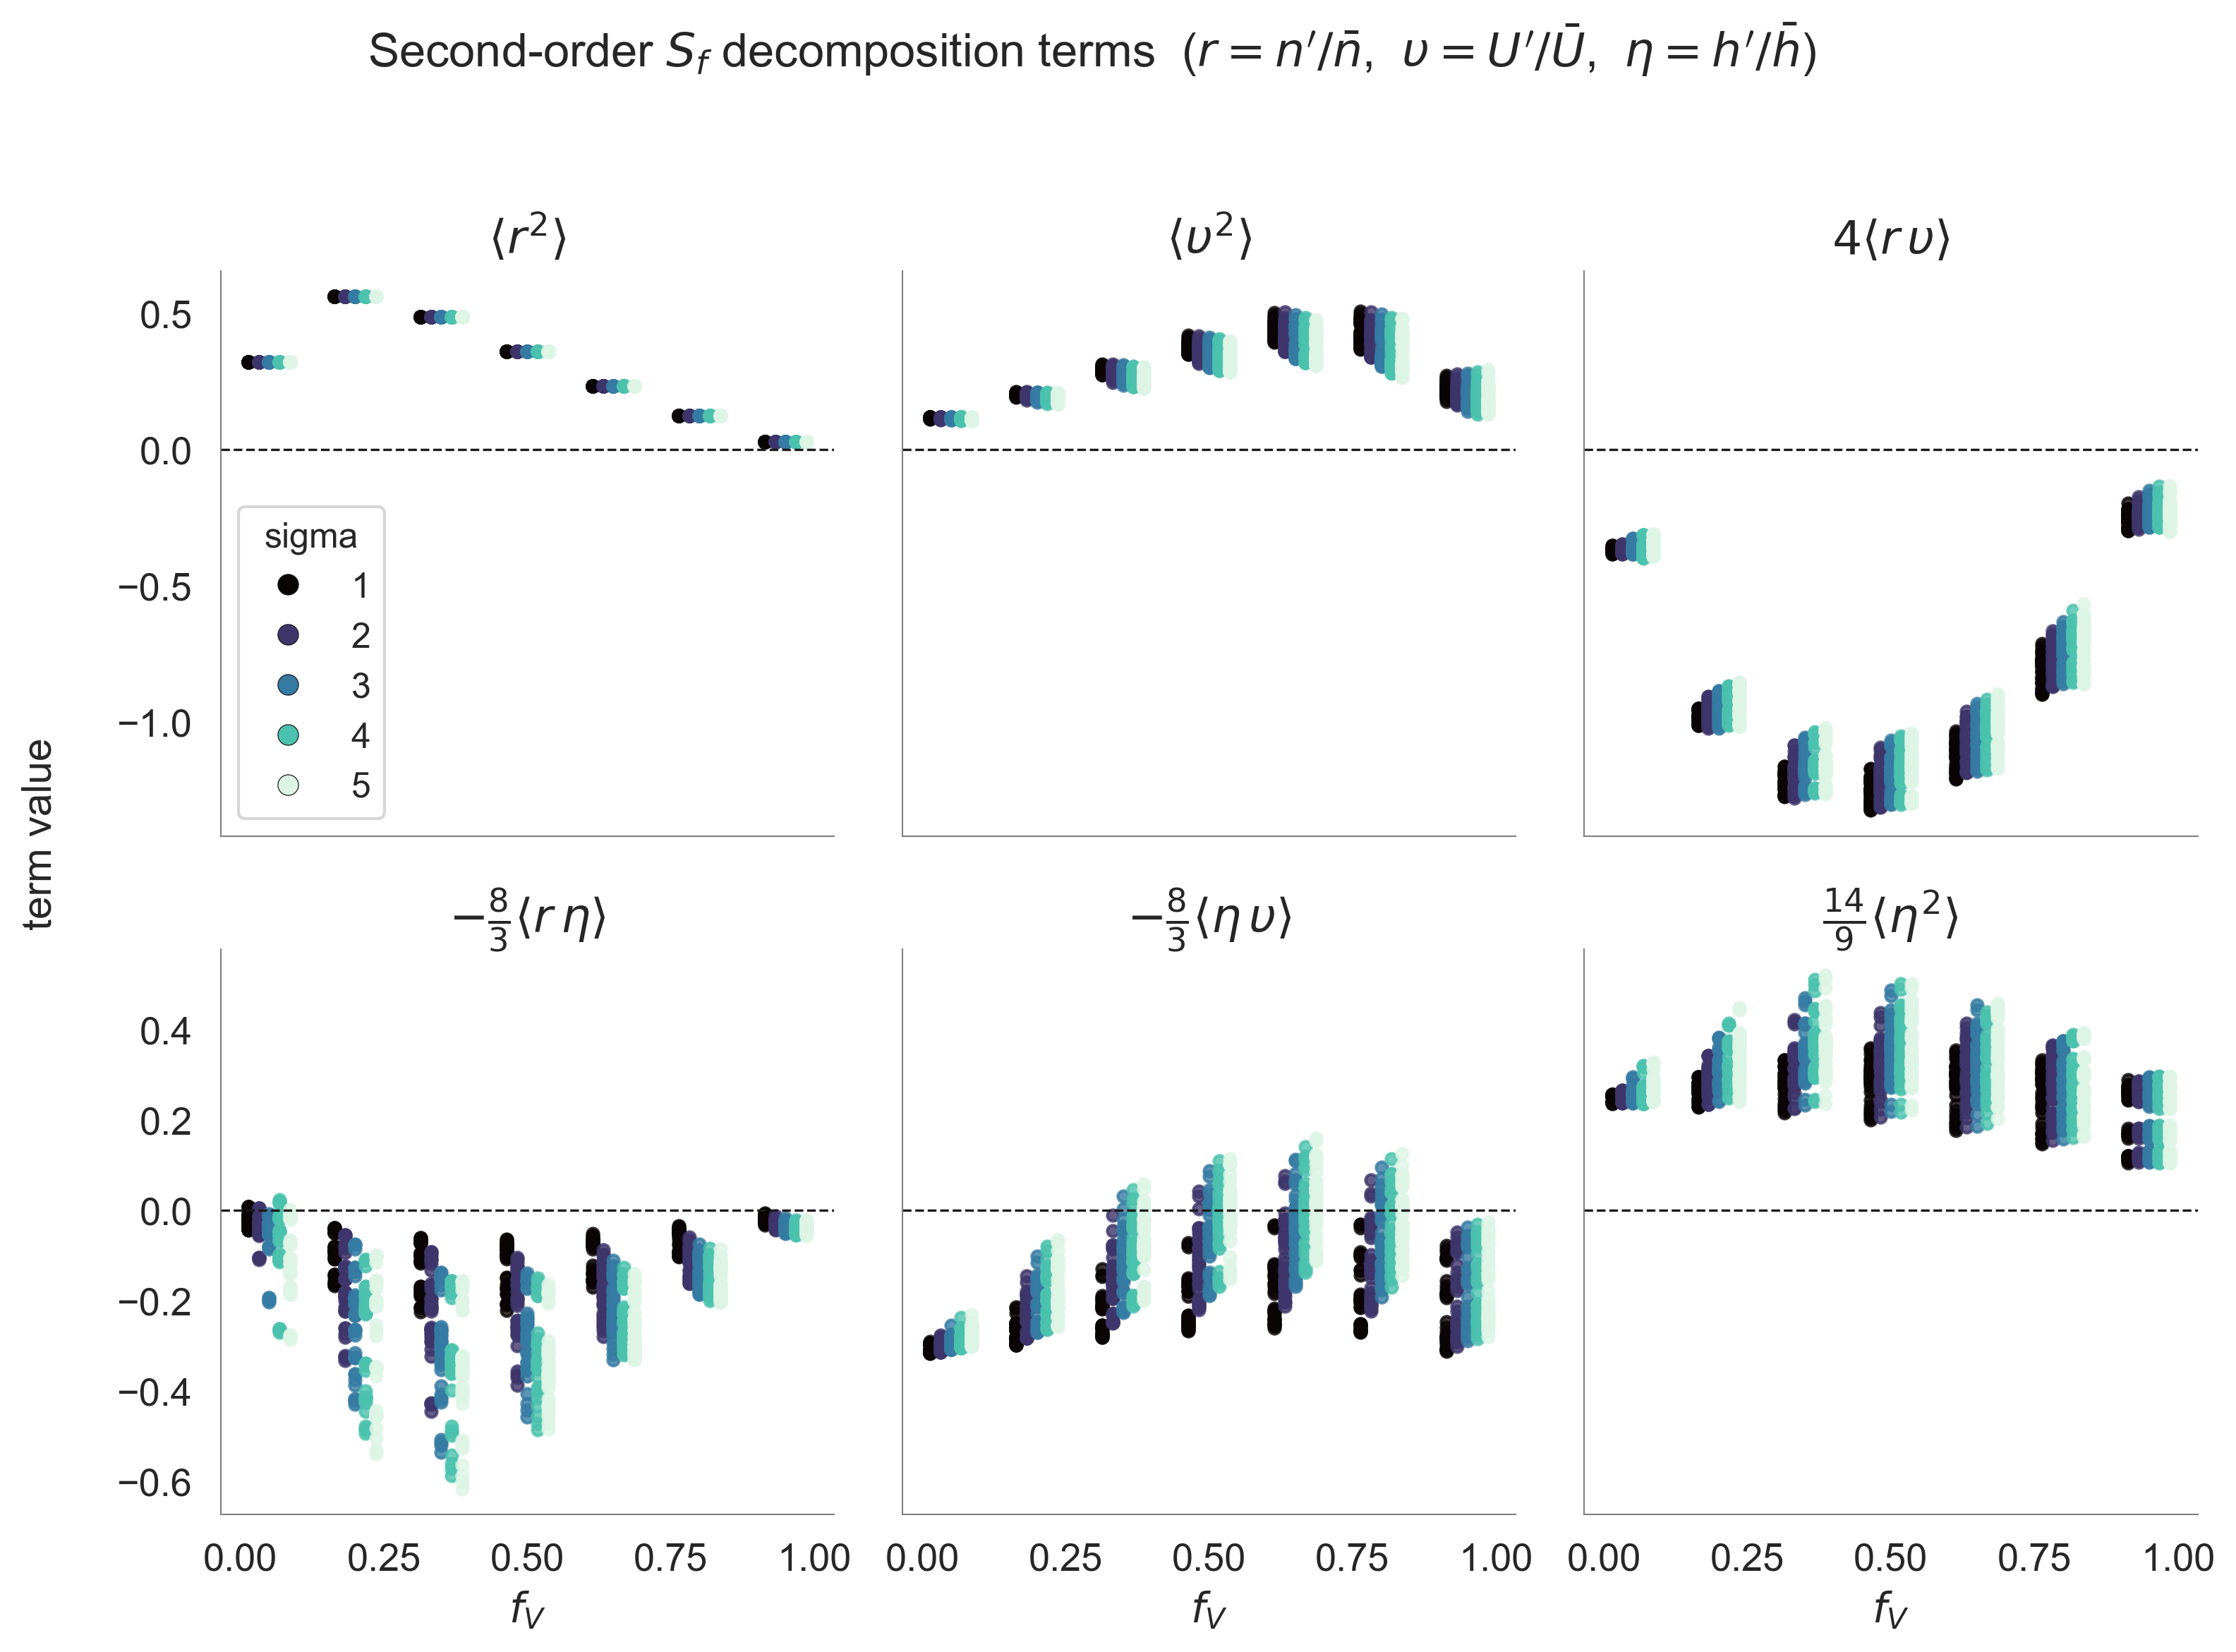

In [21]:
_term_titles = [
    r"$\langle r^2 \rangle$",
    r"$\langle \upsilon^2 \rangle$",
    r"$4\langle r\,\upsilon \rangle$",
    r"$-\frac{8}{3}\langle r\,\eta \rangle$",
    r"$-\frac{8}{3}\langle \eta\,\upsilon \rangle$",
    r"$\frac{14}{9}\langle \eta^2 \rangle$",
]

_term_series = [summary['<r2>'], summary['<ups2>'], 4*summary['<r ups>'],
     -8/3*summary['<r eta>'], -8/3*summary['<eta ups>'], 14/9*summary['<eta2>']]

_color_by = 'sigma'  # 'veg_type', 'aniso', 'sigma', or a column name

_best_var = _color_by
if _color_by == 'veg_type':
    _best_label = 'pattern'
elif _color_by == 'aniso':
    _best_label = 'orientation'
else:
    _best_label = _color_by
print(f"Coloring by: {_best_var}")

# orientation labels
_aniso_labels = {-3: 'gradient-aligned', 1: 'isotropic', 3: 'contour-aligned'}

# ── build discrete colormap ───────────────────────────────────────────────────
if _best_var == 'veg_type':
    _bv_uniq   = [k for k in VEG_COLORS if k in summary['veg_type'].values]
    _bv_colors = {v: VEG_COLORS[v] for v in _bv_uniq}
    _n_levels  = len(_bv_uniq)
    _bv_codes  = np.array([_bv_uniq.index(v) if v in _bv_uniq else -1
                            for v in summary['veg_type']], dtype=int)
elif _best_var == 'aniso':
    _bv_raw    = pd.to_numeric(summary['aniso'], errors='coerce')
    _bv_uniq   = sorted(_bv_raw.dropna().unique())
    _n_levels  = len(_bv_uniq)
    _cmap_obj  = plt.get_cmap('Blues')
    _bv_colors = {v: _cmap_obj(0.50 + 0.40 * i / max(_n_levels - 1, 1))
                  for i, v in enumerate(_bv_uniq)}
    _bv_codes  = np.array([_bv_uniq.index(v) if v in _bv_uniq else -1
                            for v in _bv_raw], dtype=int)
else:
    _bv_raw   = pd.to_numeric(summary[_best_var], errors='coerce')
    _bv_uniq  = sorted(_bv_raw.dropna().unique())
    _n_levels = len(_bv_uniq)
    _cmap_obj = plt.get_cmap(VAR_CMAPS.get(_best_var, 'viridis'))
    _bv_colors = {v: _cmap_obj(i / max(_n_levels - 1, 1)) for i, v in enumerate(_bv_uniq)}
    _bv_codes  = np.array([_bv_uniq.index(v) if v in _bv_uniq else -1
                            for v in _bv_raw], dtype=int)

_fV_vals = summary['fV'].to_numpy(float)
_fV_range = np.nanmax(_fV_vals) - np.nanmin(_fV_vals)

# constant x-offset per level (centred around the true fV value)
_fV_offset_step = 0.02 * _fV_range
_bv_offsets = {v: (i - (_n_levels - 1) / 2) * _fV_offset_step
               for i, v in enumerate(_bv_uniq)}

fig, axes = plt.subplots(2, 3, figsize=(11, 8), sharey='row', sharex=True)
axes = axes.ravel()
for i, (_ts, title) in enumerate(zip(_term_series, _term_titles)):
    for j, _val in enumerate(_bv_uniq):
        _sel = _bv_codes == j
        if _sel.any():
            axes[i].scatter(_fV_vals[_sel] + _bv_offsets[_val], _ts[_sel],
                            color=_bv_colors[_val], s=15, alpha=0.8)
    axes[i].set_title(title, fontsize=FS_TITLE + 3)
    axes[i].axhline(0, color='k', lw=0.8, ls='--')
    axes[i].tick_params(labelsize=FS_TICK + 1)

for ax in axes[3:]:
    ax.set_xlabel(r'$f_V$', fontsize=FS_LABEL + 2)

# discrete color legend
from matplotlib.lines import Line2D

def _label_for(v):
    if _best_var == 'veg_type':
        return VEG_LABELS.get(v, str(v))
    elif _best_var == 'aniso':
        return _aniso_labels.get(v, f'{v:g}')
    return f'{v:g}'

_leg_handles = [Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=_bv_colors[v], markersize=7,
                       markeredgecolor='k', markeredgewidth=0.3,
                       label=_label_for(v))
                for v in _bv_uniq]
axes[0].legend(handles=_leg_handles, title=_best_label, fontsize=FS_LEG,
               title_fontsize=FS_LEG, loc='best', frameon=True)

fig.text(0.04, 0.5, 'term value', va='center', rotation='vertical', fontsize=FS_LABEL + 2)
fig.suptitle(r"Second-order $S_f$ decomposition terms  ($r = n'/\bar{n}$,  $\upsilon = U'/\bar{U}$,  $\eta = h'/\bar{h}$)", fontsize=FS_TITLE + 3)
fig.tight_layout(rect=[0.06, 0, 1, 0.96])
plt.show()


Coloring by: sigma


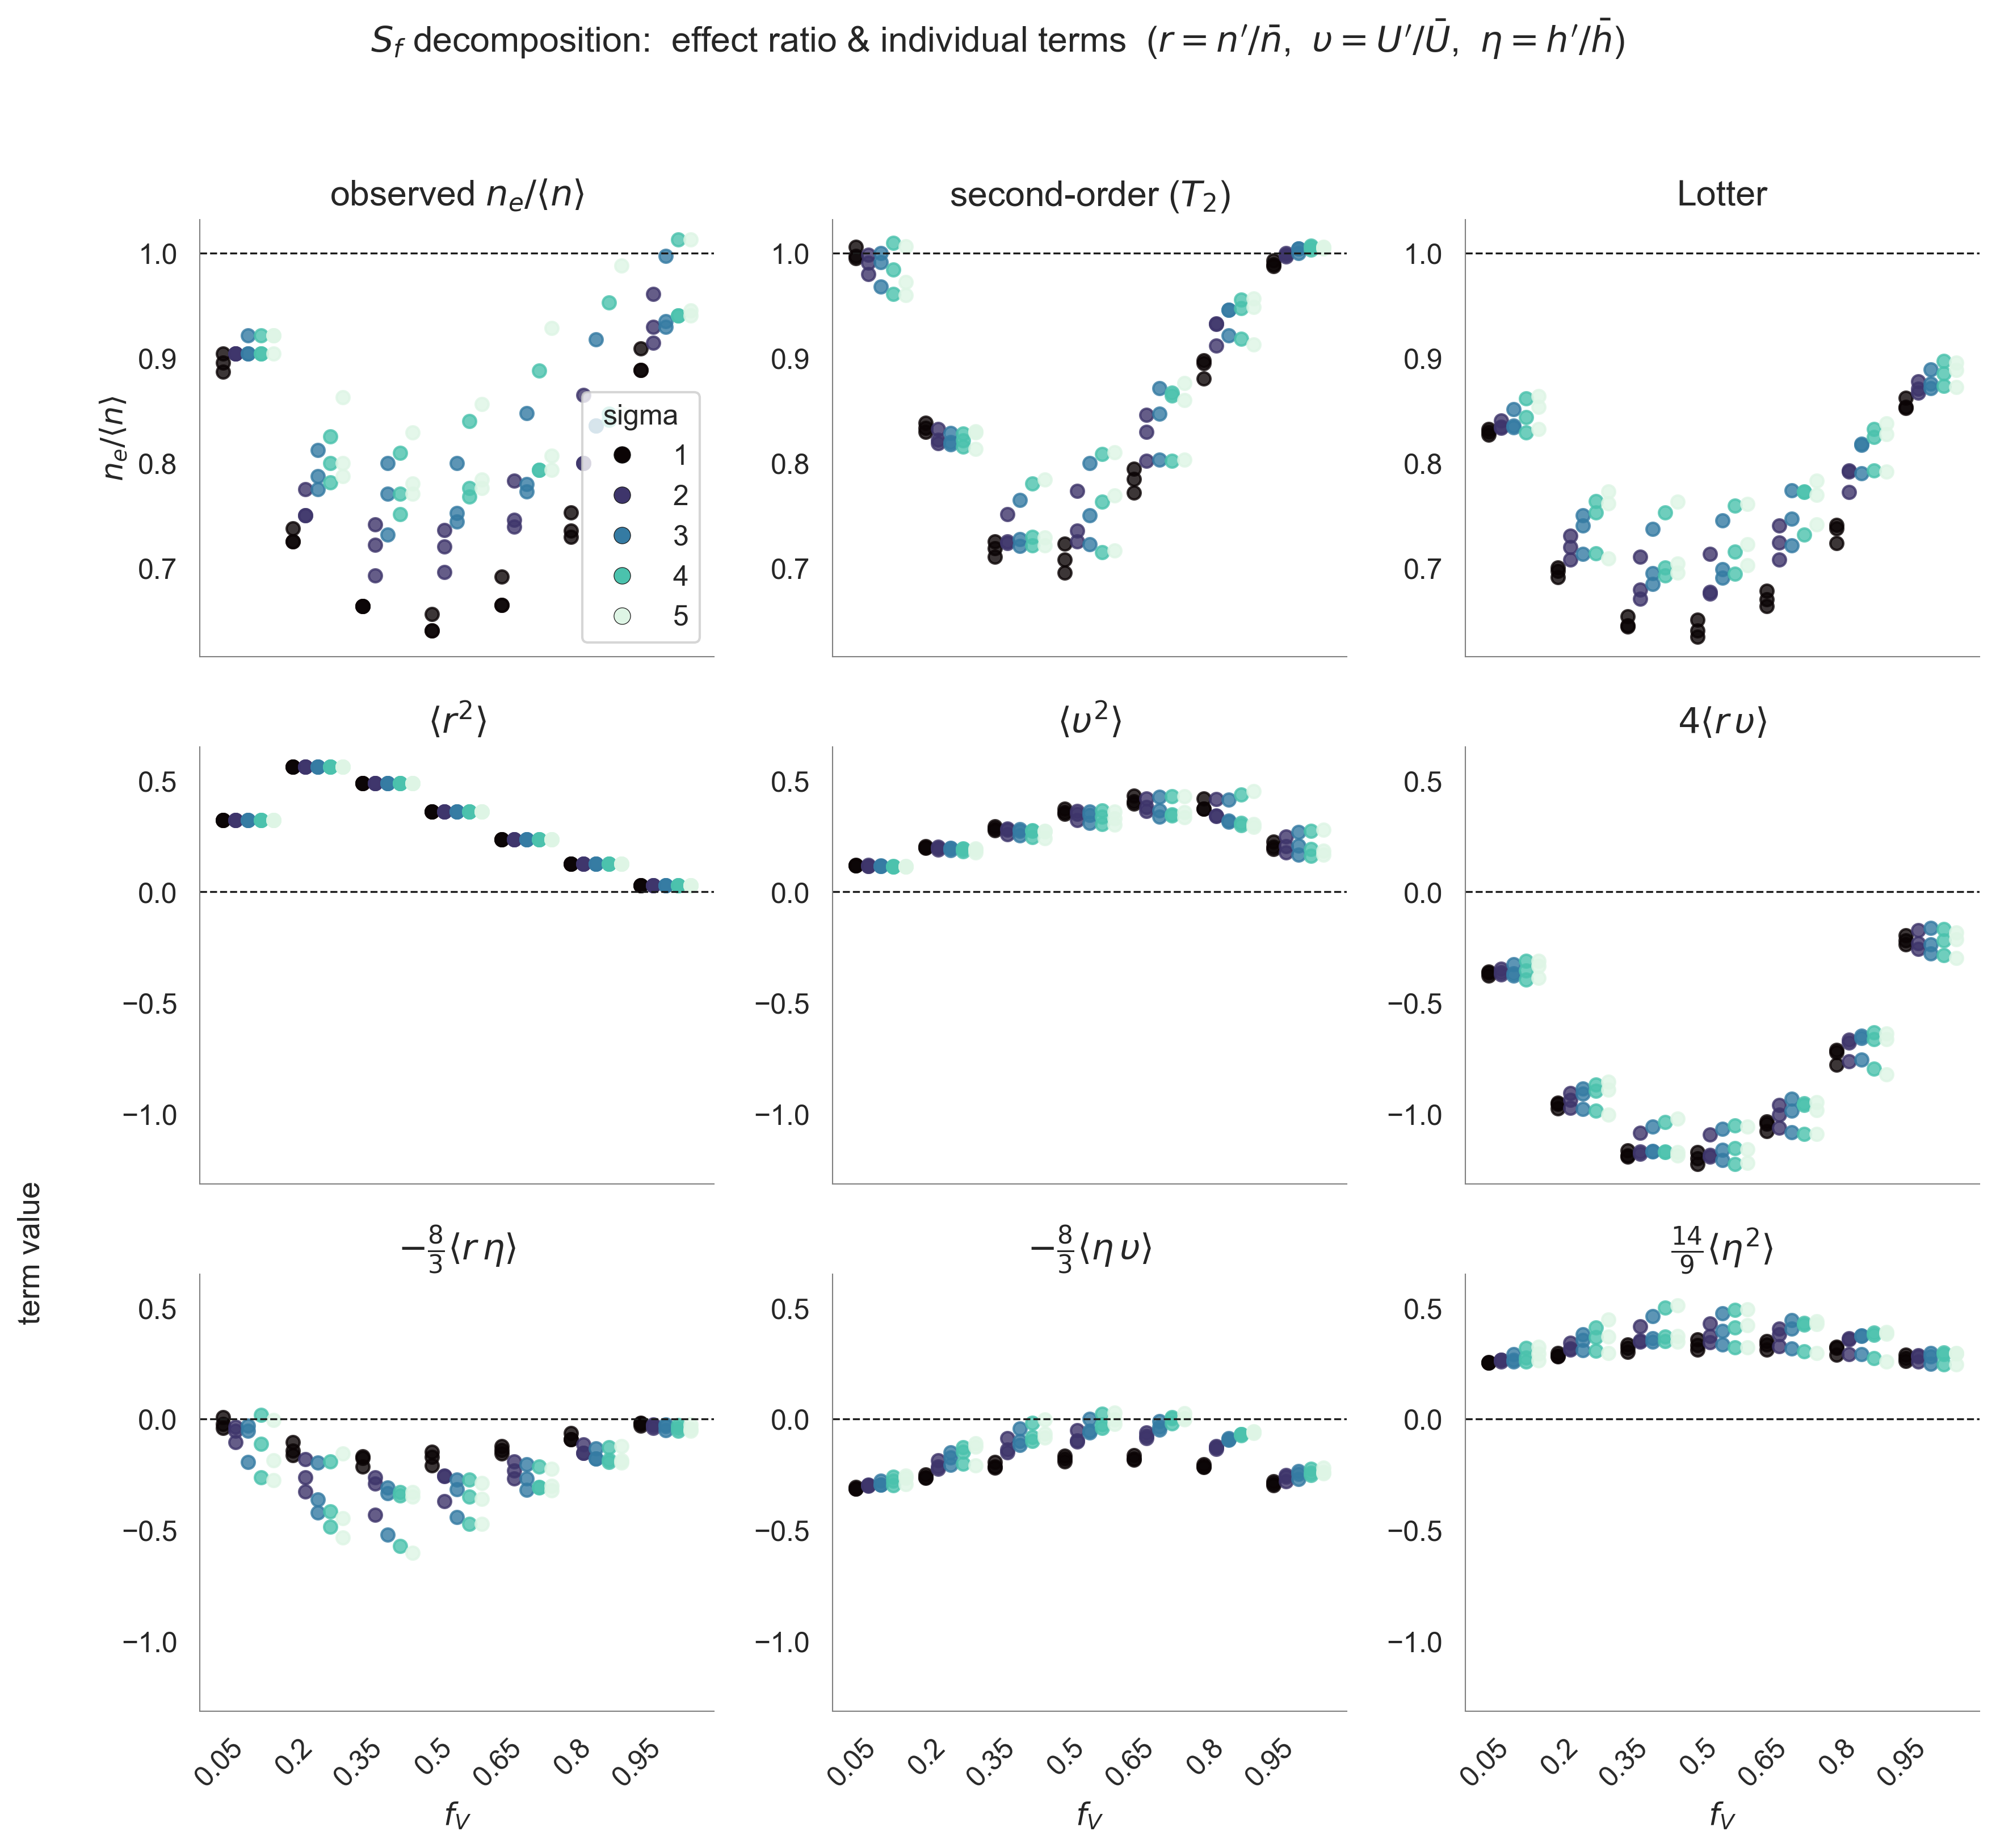

In [50]:
_term_titles = [
    r"$\langle r^2 \rangle$",
    r"$\langle \upsilon^2 \rangle$",
    r"$4\langle r\,\upsilon \rangle$",
    r"$-\frac{8}{3}\langle r\,\eta \rangle$",
    r"$-\frac{8}{3}\langle \eta\,\upsilon \rangle$",
    r"$\frac{14}{9}\langle \eta^2 \rangle$",
]
subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and aniso == 1")
_color_by = 'sigma'  # 'veg_type', 'aniso', 'sigma', or 'auto'

_term_series = [subset['<r2>'], subset['<ups2>'], 4*subset['<r ups>'],
     -8/3*subset['<r eta>'], -8/3*subset['<eta ups>'], 14/9*subset['<eta2>']]

# ── top-row series: observed, second-order, Lotter ────────────────────────────
_top_titles = [
    r"observed $n_e/\langle n\rangle$",
    r"second-order ($T_2$)",
    r"Lotter",
]
_top_series = [subset['effect_ratio'], subset['effect_ratio_T2'], subset['effect_ratio_Q']]

# ── color-by setup ───────────────────────────────────────────────────────────
_best_var = _color_by
if _color_by == 'veg_type':
    _best_label = 'pattern'
elif _color_by == 'aniso':
    _best_label = 'orientation'
else:
    _best_label = _color_by
print(f"Coloring by: {_best_var}")

# map sigma → median vegetation patch lengthscale
_sigma_to_LV = summary.groupby('sigma')['LV'].median().to_dict()

# orientation labels
_aniso_labels = {-3: 'gradient-aligned', 1: 'isotropic', 3: 'contour-aligned'}

# ── build discrete colormap ──────────────────────────────────────────────────
if _best_var == 'veg_type':
    _bv_uniq   = [k for k in VEG_COLORS if k in subset['veg_type'].values]
    _bv_colors = {v: VEG_COLORS[v] for v in _bv_uniq}
    _n_levels  = len(_bv_uniq)
    _bv_codes  = np.array([_bv_uniq.index(v) if v in _bv_uniq else -1
                            for v in subset['veg_type']], dtype=int)
elif _best_var == 'aniso':
    _bv_raw    = pd.to_numeric(subset['aniso'], errors='coerce')
    _bv_uniq   = sorted(_bv_raw.dropna().unique())
    _n_levels  = len(_bv_uniq)
    _cmap_obj  = plt.get_cmap('Blues')
    _bv_colors = {v: _cmap_obj(0.50 + 0.40 * i / max(_n_levels - 1, 1))
                  for i, v in enumerate(_bv_uniq)}
    _bv_codes  = np.array([_bv_uniq.index(v) if v in _bv_uniq else -1
                            for v in _bv_raw], dtype=int)
else:
    _bv_raw   = pd.to_numeric(subset[_best_var], errors='coerce')
    _bv_uniq  = sorted(_bv_raw.dropna().unique())
    _n_levels = len(_bv_uniq)
    _cmap_obj = plt.get_cmap(VAR_CMAPS.get(_best_var, 'viridis'))
    _bv_colors = {v: _cmap_obj(i / max(_n_levels - 1, 1)) for i, v in enumerate(_bv_uniq)}
    _bv_codes  = np.array([_bv_uniq.index(v) if v in _bv_uniq else -1
                            for v in _bv_raw], dtype=int)

# ── uniform x-axis ───────────────────────────────────────────────────────────
_fv_levels = sorted(subset['fV'].dropna().unique())
_fv_to_pos = {v: float(i) for i, v in enumerate(_fv_levels)}
_fV_vals = subset['fV'].map(_fv_to_pos).to_numpy(float)
_tick_pos  = list(range(len(_fv_levels)))
_tick_lbls = [f'{v:g}' for v in _fv_levels]
# show every other label to reduce crowding
_stride = max(1, len(_fv_levels) // 5)
_tick_lbls = [lbl if i % _stride == 0 else '' for i, lbl in enumerate(_tick_lbls)]

_fV_offset_step = 0.18
_bv_offsets = {v: (i - (_n_levels - 1) / 2) * _fV_offset_step
               for i, v in enumerate(_bv_uniq)}

# ── 3×3 figure ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(12, 11), sharex=True)

# Share y-axis: row 0 within itself, rows 1-2 together
for col in range(1, 3):
    axes[0, col].sharey(axes[0, 0])
for row in range(1, 3):
    for col in range(3):
        if (row, col) != (1, 0):
            axes[row, col].sharey(axes[1, 0])

# --- helper to scatter one panel ---
def _scatter_panel(ax, ys, title, share_y_row=None):
    for j, _val in enumerate(_bv_uniq):
        _sel = _bv_codes == j
        if _sel.any():
            ax.scatter(_fV_vals[_sel] + _bv_offsets[_val], ys.to_numpy(float)[_sel],
                       color=_bv_colors[_val], s=30, alpha=0.8)
    ax.set_title(title, fontsize=FS_TITLE + 2)
    ax.axhline(0 if share_y_row != 0 else 1, color='k', lw=0.8, ls='--')
    ax.tick_params(labelsize=FS_TICK)

# Row 0: effect ratios (shared y within row)
for ci, (ts, title) in enumerate(zip(_top_series, _top_titles)):
    _scatter_panel(axes[0, ci], ts, title, share_y_row=0)

# Rows 1-2: decomposition terms (shared y within rows 1-2)
for i, (ts, title) in enumerate(zip(_term_series, _term_titles)):
    row, col = divmod(i, 3)
    _scatter_panel(axes[row + 1, col], ts, title)
# x-labels on bottom row only
for ax in axes[2, :]:
    ax.set_xlabel(r'$f_V$', fontsize=FS_LABEL + 1)
for ax in axes.ravel():
    ax.set_xticks(_tick_pos)
    ax.set_xticklabels(_tick_lbls, rotation=45, ha='right', fontsize=FS_TICK)

# legend
from matplotlib.lines import Line2D
def _label_for(v):
    if _best_var == 'veg_type':
        return VEG_LABELS.get(v, str(v))
    elif _best_var == 'aniso':
        return _aniso_labels.get(v, f'{v:g}')
    elif _best_var == 'sigma' and v in _sigma_to_LV:
        return f'{_sigma_to_LV[v]:.0f} m'
    else:
        return f'{v:g}'
_leg_handles = [Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=_bv_colors[v], markersize=7,
                       markeredgecolor='k', markeredgewidth=0.3,
                       label=_label_for(v))
                for v in _bv_uniq]
axes[0, 2].legend(handles=_leg_handles, title=r'$L_V$ (patch scale)',
                  fontsize=FS_LEG, title_fontsize=FS_LEG,
                  loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=True)

# y-labels
axes[0, 0].set_ylabel(r'$n_e/\langle n\rangle$', fontsize=FS_LABEL + 1)
fig.text(0.02, 0.33, 'term value', va='center', rotation='vertical', fontsize=FS_LABEL + 1)

fig.suptitle(r"$S_f$ decomposition:  effect ratio & individual terms  ($r = n'/\bar{n}$,  $\upsilon = U'/\bar{U}$,  $\eta = h'/\bar{h}$)",
             fontsize=FS_TITLE + 2, y=0.99)
fig.tight_layout(rect=[0.04, 0, 1, 0.97])
plt.show()


In [49]:
summary.groupby("sigma").LV.median()

sigma
1     3.451677
2     6.339144
3     9.114583
4    12.068966
5    15.243902
Name: LV, dtype: float64

Coloring by: aniso


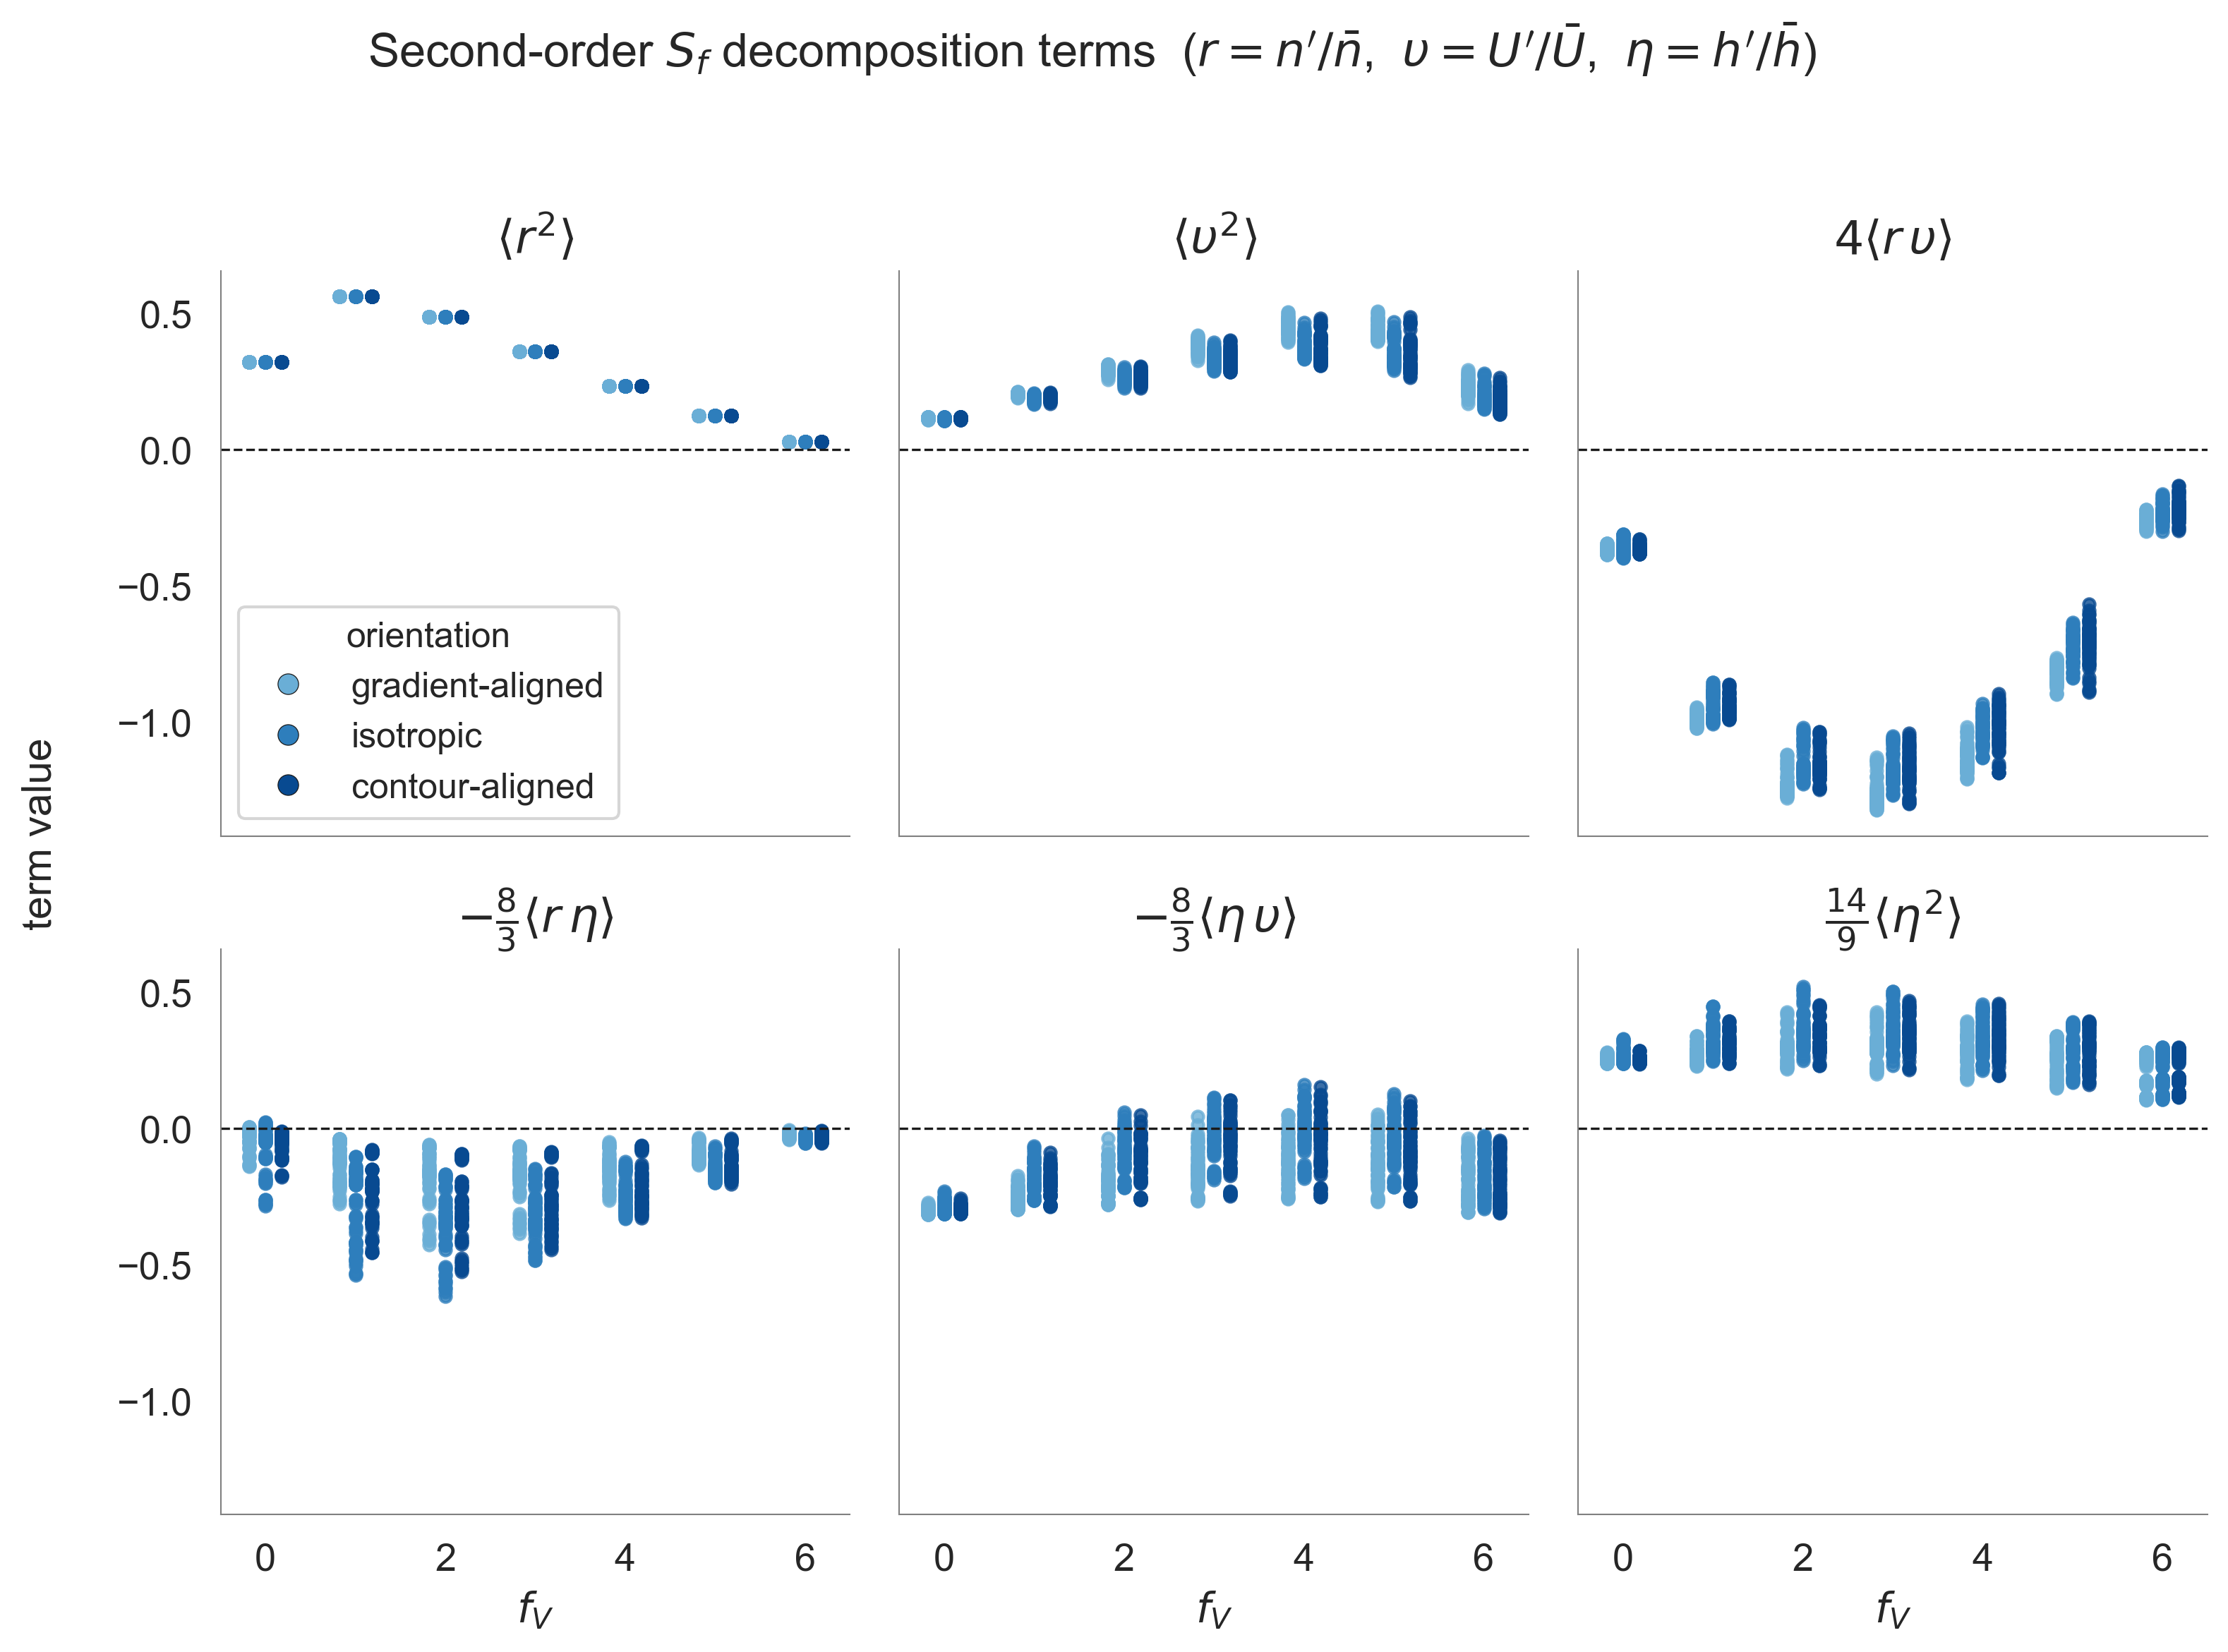

In [23]:
_term_titles = [
    r"$\langle r^2 \rangle$",
    r"$\langle \upsilon^2 \rangle$",
    r"$4\langle r\,\upsilon \rangle$",
    r"$-\frac{8}{3}\langle r\,\eta \rangle$",
    r"$-\frac{8}{3}\langle \eta\,\upsilon \rangle$",
    r"$\frac{14}{9}\langle \eta^2 \rangle$",
]
subset = summary
_color_by = 'aniso'  # 'veg_type' or 'auto' (auto-detect best design param)

_term_series = [subset['<r2>'], subset['<ups2>'], 4*subset['<r ups>'],
     -8/3*subset['<r eta>'], -8/3*subset['<eta ups>'], 14/9*subset['<eta2>']]

# ── auto-detect the design parameter explaining the most variance ────────────
_design_candidates = ['sigma', 'aniso', 'p', 'tr', 'l', 'So', 'alpha_v', 'alpha_b']  # exclude fV (x-axis)
_design_candidates = [c for c in _design_candidates if c in subset.columns]

_mean_abs_corr = {}
for _dc in _design_candidates:
    _dv = pd.to_numeric(subset[_dc], errors='coerce')
    if _dv.nunique() < 2:
        continue
    _corrs = []
    for _ts in _term_series:
        _finite = np.isfinite(_dv) & np.isfinite(_ts)
        if _finite.sum() > 5:
            _corrs.append(abs(np.corrcoef(_dv[_finite], _ts[_finite])[0, 1]))
    if _corrs:
        _mean_abs_corr[_dc] = np.mean(_corrs)

_best_var = _color_by
if _color_by == 'veg_type':
    _best_label = 'pattern'
elif _color_by == 'aniso':
    _best_label = 'orientation'
else:
    _pretty_terms = {'fV': r'$f_V$', 'sigma': r'$\sigma$', 'aniso': 'orientation',
                     'p': r'$p$', 'tr': r'$t_r$', 'l': r'$L$', 'So': r'$S_0$',
                     'alpha_v': r'$n_v$', 'alpha_b': r'$n_b$'}
    _best_label = _pretty_terms.get(_best_var, _best_var)
print(f"Coloring by: {_best_var}")

# ── orientation labels & colors (Blues, truncated 0.50-0.90) ─────────────────
_aniso_labels = {-3: 'gradient-aligned', 1: 'isotropic', 3: 'contour-aligned'}

# ── build discrete colormap for the chosen variable ──────────────────────────
if _best_var == 'veg_type':
    _bv_uniq   = [k for k in VEG_COLORS if k in subset['veg_type'].values]
    _bv_colors = {v: VEG_COLORS[v] for v in _bv_uniq}
    _n_levels  = len(_bv_uniq)
    _bv_codes  = np.array([_bv_uniq.index(v) if v in _bv_uniq else -1
                            for v in subset['veg_type']], dtype=int)
elif _best_var == 'aniso':
    _bv_raw    = pd.to_numeric(subset['aniso'], errors='coerce')
    _bv_uniq   = sorted(_bv_raw.dropna().unique())
    _n_levels  = len(_bv_uniq)
    _cmap_obj  = plt.get_cmap('Blues')
    _bv_colors = {v: _cmap_obj(0.50 + 0.40 * i / max(_n_levels - 1, 1)) for i, v in enumerate(_bv_uniq)}
    _bv_codes  = np.array([_bv_uniq.index(v) if v in _bv_uniq else -1
                            for v in _bv_raw], dtype=int)
else:
    _bv_raw   = pd.to_numeric(subset[_best_var], errors='coerce')
    _bv_uniq  = sorted(_bv_raw.dropna().unique())
    _n_levels = len(_bv_uniq)
    _cmap_obj = plt.get_cmap(VAR_CMAPS.get(_best_var, 'viridis'))
    _bv_colors = {v: _cmap_obj(i / max(_n_levels - 1, 1)) for i, v in enumerate(_bv_uniq)}
    _bv_codes  = np.array([_bv_uniq.index(v) if v in _bv_uniq else -1
                            for v in _bv_raw], dtype=int)

# Map fV to uniform integer positions (like cell 14) to avoid crowded labels
_fv_levels = sorted(subset['fV'].dropna().unique())
_fv_to_pos = {v: float(i) for i, v in enumerate(_fv_levels)}
_fV_vals = subset['fV'].map(_fv_to_pos).to_numpy(float)
_tick_pos  = list(range(len(_fv_levels)))
_tick_lbls = [f'{v:g}' for v in _fv_levels]

# constant x-offset per level (centred around the true fV value)
_fV_offset_step = 0.18  # fraction of unit spacing
_bv_offsets = {v: (i - (_n_levels - 1) / 2) * _fV_offset_step
               for i, v in enumerate(_bv_uniq)}

fig, axes = plt.subplots(2, 3, figsize=(11, 8), sharey=True, sharex=True)
axes = axes.ravel()
for i, (_ts, title) in enumerate(zip(_term_series, _term_titles)):
    for j, _val in enumerate(_bv_uniq):
        _sel = _bv_codes == j
        if _sel.any():
            axes[i].scatter(_fV_vals[_sel] + _bv_offsets[_val], _ts[_sel],
                            color=_bv_colors[_val], s=15, alpha=0.8)
    axes[i].set_title(title, fontsize=FS_TITLE + 3)
    axes[i].axhline(0, color='k', lw=0.8, ls='--')
    axes[i].tick_params(labelsize=FS_TICK + 1)

for ax in axes[3:]:
    ax.set_xlabel(r'$f_V$', fontsize=FS_LABEL + 2)

# discrete color legend
from matplotlib.lines import Line2D
_leg_handles = [Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=_bv_colors[v], markersize=7,
                       markeredgecolor='k', markeredgewidth=0.3,
                       label=VEG_LABELS.get(v, str(v)) if _best_var == 'veg_type' else _aniso_labels.get(v, f'{v:g}') if _best_var == 'aniso' else f'{v:g}')
                for v in _bv_uniq]
axes[0].legend(handles=_leg_handles, title=_best_label, fontsize=FS_LEG,
               title_fontsize=FS_LEG, loc='best', frameon=True)

fig.text(0.04, 0.5, 'term value', va='center', rotation='vertical', fontsize=FS_LABEL + 2)
fig.suptitle(r"Second-order $S_f$ decomposition terms  ($r = n'/\bar{n}$,  $\upsilon = U'/\bar{U}$,  $\eta = h'/\bar{h}$)", fontsize=FS_TITLE + 3)
fig.tight_layout(rect=[0.06, 0, 1, 0.96])
plt.show()


In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as _mticker
import ipywidgets as widgets
from IPython.display import display
from matplotlib.lines import Line2D as _Line2D

# ── Color-by options: (cmap, lo, hi, legend_title, {val: label} or None) ─────
_COLOR_OPTIONS = {
    'sigma':       ('mako',     0.25, 0.90, r'$\sigma$',    None),
    'fV':          ('Greens',   0.25, 0.90, r'$f_V$',        None),
    'orientation': ('Blues',    0.50, 0.90, 'orientation',
                    {-2: 'along-slope', 1: 'isotropic', 2: 'banded'}),
    'p':           ('BuGn',   0.20, 0.90, r'$p$ (mm/hr)', None),
    'tr':          ('Blues',    0.25, 0.90, r'$t_r$ (min)', None),
    '<n>':         ('GnBu',     0.25, 0.90, r'$\langle n \rangle$', None),
}
# Map option key → actual summary column (only needed where they differ)
_COL_LOOKUP = {'orientation': 'aniso'}

def _build_colors(col):
    """Returns (colors, raw_offsets, handles, label).
    raw_offsets: dict mapping color-variable level -> unitless index offset.
    Uses _COL_LOOKUP to resolve option key -> actual summary column.
    """
    base_cmap, lo, hi, label, level_labels = _COLOR_OPTIONS[col]
    actual_col = _COL_LOOKUP.get(col, col)
    cmap = _mcolors.LinearSegmentedColormap.from_list(
        f"{base_cmap}_trunc", _cm.get_cmap(base_cmap)(np.linspace(lo, hi, 256)))
    vals = pd.to_numeric(summary[actual_col], errors='coerce')
    norm = _mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
    colors = vals.map(lambda v: cmap(norm(v)) if np.isfinite(v) else (0.5, 0.5, 0.5, 1))
    levels = sorted(vals.dropna().unique())
    _n = len(levels)
    raw_offsets = {v: (i - (_n - 1) / 2) for i, v in enumerate(levels)}
    # cap legend to <=8 entries for readability
    leg_levels = levels
    if len(levels) > 8:
        idx = np.round(np.linspace(0, len(levels) - 1, 8)).astype(int)
        leg_levels = [levels[i] for i in idx]
    handles = [
        _Line2D([0], [0], marker='o', linestyle='None',
                color=cmap(norm(v)), markersize=6,
                label=(level_labels[v] if level_labels and v in level_labels else f'{v:g}'))
        for v in leg_levels
    ]
    return colors, raw_offsets, handles, label

def _make_diag_plots(color_by='orientation', uniform_x=True):
    colors, raw_offsets, handles, leg_label = _build_colors(color_by)

    # ── compute x positions ──────────────────────────────────────────────────
    _fv_levels = sorted(summary["fV"].dropna().unique())
    if uniform_x:
        _fv_to_pos = {v: float(i) for i, v in enumerate(_fv_levels)}
        _unit = 1.0
        _tick_pos  = list(range(len(_fv_levels)))
        _tick_lbls = [f'{v:g}' for v in _fv_levels]
    else:
        _fv_to_pos = {v: v for v in _fv_levels}
        _unit = float(np.median(np.diff(_fv_levels))) if len(_fv_levels) > 1 else 1.0
        _tick_pos  = None
        _tick_lbls = None

    _step = 0.18 * _unit   # 18% of inter-category gap
    col_vals = pd.to_numeric(summary[_COL_LOOKUP.get(color_by, color_by)], errors='coerce')
    fv_x = (summary["fV"].map(lambda v: _fv_to_pos.get(v, v))
            + col_vals.map(lambda v: _step * raw_offsets.get(v, 0.0) if np.isfinite(v) else 0.0))

    def _set_xticks(ax):
        if uniform_x:
            ax.set_xticks(_tick_pos)
            ax.set_xticklabels(_tick_lbls, rotation=45, ha='right', fontsize=FS_TICK)

    def _style_y_ticks(ax):
        ax.yaxis.set_major_locator(_mticker.MaxNLocator(nbins=5))

    def _add_legend(ax):
        ax.legend(handles=handles, title=leg_label,
                  fontsize=12, title_fontsize=13,
                  loc='upper left', frameon=True)

    _xlabel = r"$f_V$ (uniform)" if uniform_x else r"$f_V$"

    # ---------- Velocity moments ----------
    # Share y-axis between left and center only
    fig = plt.figure(figsize=(14, 4))
    gs = fig.add_gridspec(1, 5, width_ratios=[1, 0.12, 1, 0.22, 1], wspace=0.0)
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 2], sharey=ax0)
    ax2 = fig.add_subplot(gs[0, 4])
    axes = [ax0, ax1, ax2]

    axes[0].scatter(fv_x, summary["<Up2>"], c=colors, s=20)
    axes[0].set_xlabel(_xlabel); axes[0].set_ylabel(r"$\langle U^{\prime 2}\rangle$")
    axes[0].set_title("Velocity variance"); axes[0].grid(True, alpha=0.3); _set_xticks(axes[0]); _style_y_ticks(axes[0]); axes[0].tick_params(axis='both', labelsize=FS_TICK); axes[0].tick_params(axis='y', which='both', left=True, labelleft=True)
    axes[1].scatter(fv_x, summary["<U>"]**2, c=colors, s=20)
    axes[1].set_xlabel(_xlabel); axes[1].set_ylabel(r"$\langle U\rangle^2$")
    axes[1].set_title("Mean-squared velocity"); axes[1].grid(True, alpha=0.3); _set_xticks(axes[1]); _style_y_ticks(axes[1]); axes[1].tick_params(axis='both', labelsize=FS_TICK); axes[1].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[2].scatter(fv_x, summary["<Up2>"] / summary["<U>"]**2, c=colors, s=20)
    axes[2].set_xlabel(_xlabel); axes[2].set_ylabel(r"$\langle U^{\prime 2}\rangle/\langle U\rangle^2$")
    axes[2].set_title("Velocity variance ratio"); axes[2].grid(True, alpha=0.3); _set_xticks(axes[2]); _style_y_ticks(axes[2]); axes[2].tick_params(axis='both', labelsize=FS_TICK)
    _add_legend(axes[0])
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    # ---------- Depth moments ----------
    fig = plt.figure(figsize=(14, 4))
    gs = fig.add_gridspec(1, 5, width_ratios=[1, 0.12, 1, 0.22, 1], wspace=0.0)
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 2], sharey=ax0)
    ax2 = fig.add_subplot(gs[0, 4])
    axes = [ax0, ax1, ax2]

    axes[0].scatter(fv_x, summary["<hp2>"], c=colors, s=20)
    axes[0].set_xlabel(_xlabel); axes[0].set_ylabel(r"$\langle h^{\prime 2}\rangle$")
    axes[0].set_title("Depth variance"); axes[0].grid(True, alpha=0.3); _set_xticks(axes[0]); _style_y_ticks(axes[0]); axes[0].tick_params(axis='both', labelsize=FS_TICK); axes[0].tick_params(axis='y', which='both', left=True, labelleft=True)
    axes[1].scatter(fv_x, summary["<h>"]**2, c=colors, s=20)
    axes[1].set_xlabel(_xlabel); axes[1].set_ylabel(r"$\langle h\rangle^2$")
    axes[1].set_title("Mean-squared depth"); axes[1].grid(True, alpha=0.3); _set_xticks(axes[1]); _style_y_ticks(axes[1]); axes[1].tick_params(axis='both', labelsize=FS_TICK); axes[1].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[2].scatter(fv_x, summary["<hp2>"] / summary["<h>"]**2, c=colors, s=20)
    axes[2].set_xlabel(_xlabel); axes[2].set_ylabel(r"$\langle h^{\prime 2}\rangle/\langle h\rangle^2$")
    axes[2].set_title("Depth variance ratio"); axes[2].grid(True, alpha=0.3); _set_xticks(axes[2]); _style_y_ticks(axes[2]); axes[2].tick_params(axis='both', labelsize=FS_TICK)
    _add_legend(axes[0])
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    # ---------- Cross-covariances & n-variance ----------
    fig = plt.figure(figsize=(14, 4))
    gs = fig.add_gridspec(1, 5, width_ratios=[1, 0.12, 1, 0.22, 1], wspace=0.0)
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 2], sharey=ax0)
    ax2 = fig.add_subplot(gs[0, 4])
    axes = [ax0, ax1, ax2]

    axes[0].scatter(fv_x, summary["<r ups>"], c=colors, s=20)
    axes[0].set_xlabel(_xlabel); axes[0].set_ylabel(r"$\langle r\,\upsilon\rangle$")
    axes[0].set_title(r"$n$--$U$ normalized covariance"); axes[0].grid(True, alpha=0.3); _set_xticks(axes[0]); _style_y_ticks(axes[0]); axes[0].tick_params(axis='both', labelsize=FS_TICK); axes[0].tick_params(axis='y', which='both', left=True, labelleft=True)
    axes[1].scatter(fv_x, summary["<r eta>"], c=colors, s=20)
    axes[1].set_xlabel(_xlabel); axes[1].set_ylabel(r"$\langle r\,\eta\rangle$")
    axes[1].set_title(r"$n$--$h$ normalized covariance"); axes[1].grid(True, alpha=0.3); _set_xticks(axes[1]); _style_y_ticks(axes[1]); axes[1].tick_params(axis='both', labelsize=FS_TICK); axes[1].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[2].scatter(fv_x, summary["<r2>"], c=colors, s=20)
    axes[2].set_xlabel(_xlabel); axes[2].set_ylabel(r"$\langle r^2\rangle$")
    axes[2].set_title(r"$n$ normalized variance"); axes[2].grid(True, alpha=0.3); _set_xticks(axes[2]); _style_y_ticks(axes[2]); axes[2].tick_params(axis='both', labelsize=FS_TICK)
    _add_legend(axes[0])
    fig.tight_layout()
    plt.show()
    plt.close(fig)


_dd = widgets.Dropdown(
    options=list(_COLOR_OPTIONS.keys()),
    value='orientation',
    description='Colour by:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='220px'),
)
_cb = widgets.Checkbox(
    value=True,
    description='Uniform x spacing',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px'),
)

_diag_out = widgets.Output()

def _trigger_diag(change=None):
    with _diag_out:
        _diag_out.clear_output(wait=True)
        _make_diag_plots(_dd.value, _cb.value)

_dd.observe(_trigger_diag, names='value')
_cb.observe(_trigger_diag, names='value')
_trigger_diag()
display(widgets.VBox([widgets.HBox([_dd, _cb]), _diag_out]))

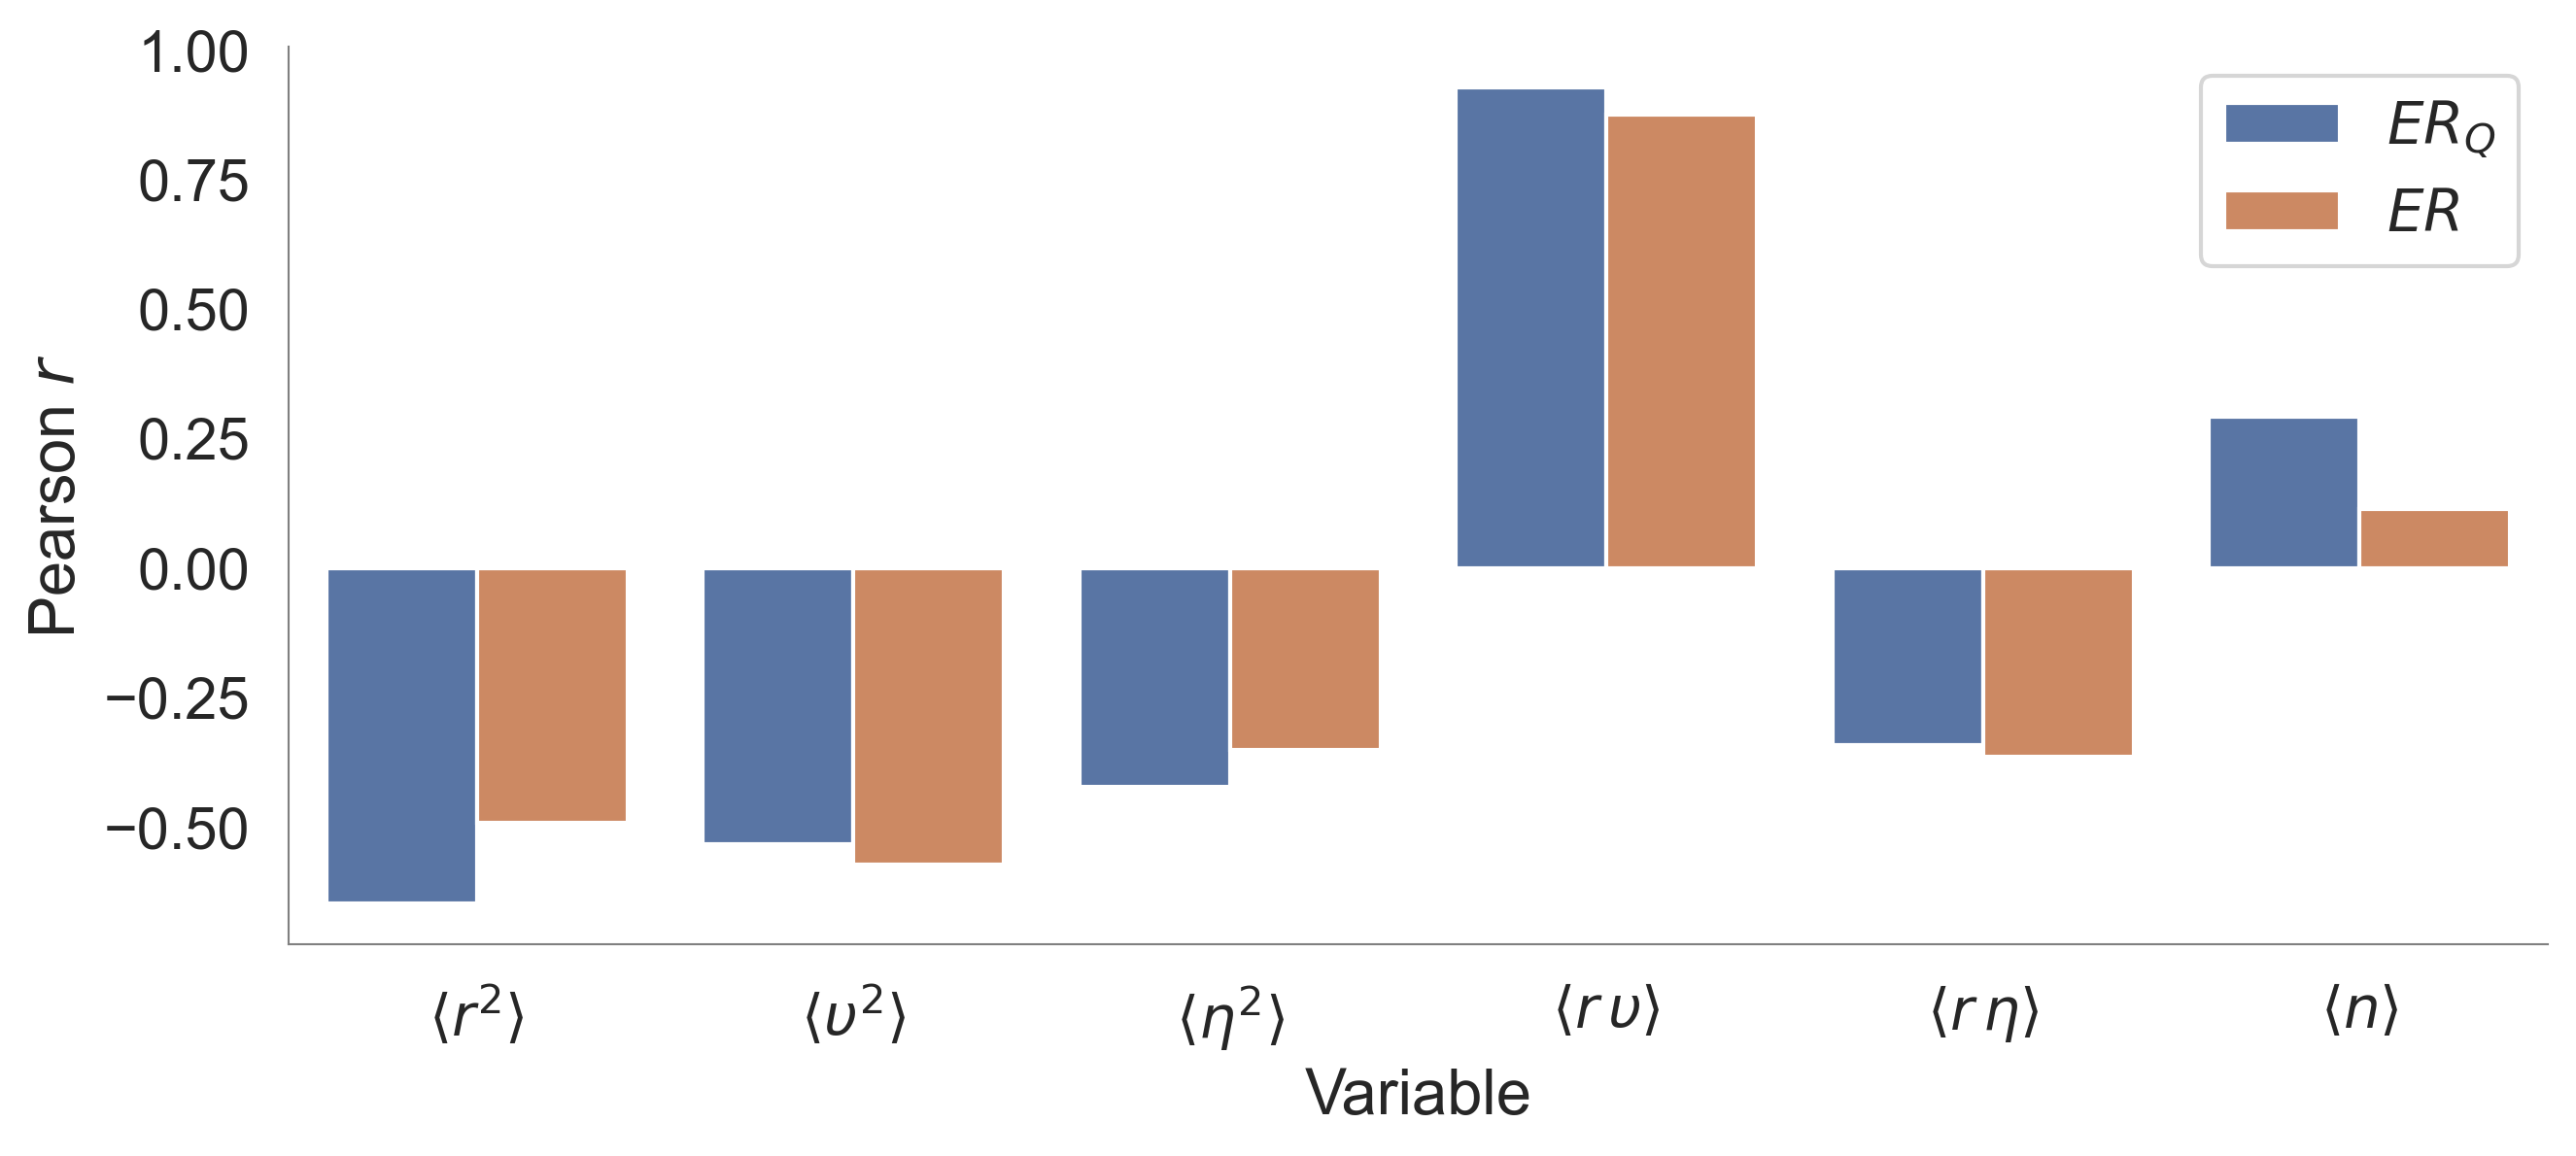

In [25]:
# ------------- Effect ratios to analyze -------------
# include observed ER if available
ERs = [c for c in ["effect_ratio_Q", "effect_ratio"] if c in summary.columns]

def corr_to_target(yname):
    rows = []
    for d in drivers:
        xy = summary[[yname, d]].dropna()
        if len(xy) >= 3:
            r = np.corrcoef(xy[yname], xy[d])[0, 1]
            rows.append({"variable": yname, "var": d, "pearson_r": r})
    return pd.DataFrame(rows)

# Build effect-ratio correlation table
combined_ER = pd.concat([corr_to_target(er) for er in ERs], ignore_index=True)

# Add |r| and make a display copy
combined_ER["abs_r"] = combined_ER["pearson_r"].abs()
combined_ER_disp = combined_ER.copy()
combined_ER_disp["pearson_r"] = combined_ER_disp["pearson_r"].round(3)
combined_ER_disp["abs_r"]     = combined_ER_disp["abs_r"].round(3)

# Sort within each ER by |r|
combined_ER_disp = (combined_ER_disp
    .sort_values(["variable", "abs_r"], ascending=[True, False])
    .reset_index(drop=True))

# Pivot (rows: ERs, cols: drivers) for quick inspection/heatmap if desired
ER_corr_pivot = (combined_ER
    .pivot(index="variable", columns="var", values="pearson_r")
    .sort_index()
)
ER_corr_pivot_disp = ER_corr_pivot.round(3)

er_order      = [e for e in ["effect_ratio_Q", "effect_ratio"] if e in ERs]
er_order_tex  = [er_tex[e] for e in er_order]

# Map LaTeX labels for plotting
combined_ER_disp = combined_ER_disp.copy()
combined_ER_disp["var_tex"] = combined_ER_disp["var"].map(var_tex).fillna(combined_ER_disp["var"])
combined_ER_disp["variable_tex"] = combined_ER_disp["variable"].map(er_tex).fillna(combined_ER_disp["variable"])

# --- Barplot of correlations (effect ratios vs drivers) ---
plt.figure(figsize=(10, 4))
sns.barplot(data=combined_ER_disp, x="var_tex", y="pearson_r", hue="variable_tex", order = x_order_tex,
            hue_order=er_order_tex)
plt.xlabel("Variable")
plt.ylabel(r"Pearson $r$")
plt.xticks(rotation=0);
plt.legend(title = '')
plt.show()



## Comparing effect-ratio predictions

_Benchmarks and diagnostics for decomposition-based predictions of $n_e / \langle n \rangle$._


In [26]:
# -------------------------------------------------------------------
# Diagnostic: predicted vs. observed n_e and effect ratio (n_e/<n>)
#
# Top row (obs on x, pred on y):
#   A \u2014 n_e: equivalent roughness from Lotter vs hydrograph calibration
#   B \u2014 effect ratio: Lotter ER_Q vs calibrated n_e/<n>
# Bottom row:
#   C \u2014 effect ratio residuals vs predicted
#   D \u2014 residual histogram
# -------------------------------------------------------------------

import ipywidgets as _widgets2
from IPython.display import display as _disp2
import matplotlib.colors as _mcolors2
from matplotlib import cm as _cm2
from matplotlib.lines import Line2D as _Line2D2
from stats import r2, mae

# ── Color-by options ────────────────────────────────────────────────
_PO_COLOR_OPTS = {
    'sigma':       ('mako',     0.25, 0.90, r'$\sigma$',              None),
    'fV':          ('Greens',   0.25, 0.90, r'$f_V$',                  None),
    'orientation': ('coolwarm', 0.15, 0.85, 'orientation',
                    {-2: 'along-slope', 1: 'isotropic', 2: 'banded'}),
    'p':           ('YlOrRd',   0.20, 0.90, r'$p$ (mm/hr)',            None),
    'tr':          ('Blues',    0.25, 0.90, r'$t_r$ (min)',            None),
    '<n>':         ('GnBu',     0.25, 0.90, r'$\langle n \rangle$',  None),
}
_PO_COL_LOOKUP = {'orientation': 'aniso'}

def _po_build_colors(color_by):
    base_cmap, lo, hi, label, level_labels = _PO_COLOR_OPTS[color_by]
    actual_col = _PO_COL_LOOKUP.get(color_by, color_by)
    cmap = _mcolors2.LinearSegmentedColormap.from_list(
        f"{base_cmap}_trunc", _cm2.get_cmap(base_cmap)(np.linspace(lo, hi, 256)))
    vals = pd.to_numeric(summary[actual_col], errors='coerce').to_numpy(float)
    norm = _mcolors2.Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals))
    c_arr = np.array([cmap(norm(v)) if np.isfinite(v) else (0.5, 0.5, 0.5, 1.0)
                      for v in vals])   # shape (N, 4)
    unique_vals = sorted(pd.to_numeric(summary[actual_col], errors='coerce').dropna().unique())
    leg_vals = unique_vals
    if len(unique_vals) > 8:
        idx = np.round(np.linspace(0, len(unique_vals) - 1, 8)).astype(int)
        leg_vals = [unique_vals[i] for i in idx]
    handles = [
        _Line2D2([0], [0], marker='o', linestyle='None', color=cmap(norm(v)),
                 markersize=6,
                 label=(level_labels[v] if level_labels and v in level_labels
                        else f'{v:g}'))
        for v in leg_vals
    ]
    return c_arr, handles, label

def _plot_pred_obs(color_by='sigma'):
    c_arr, handles, leg_label = _po_build_colors(color_by)

    er_obs = summary['effect_ratio'].to_numpy(float)
    er_hat = summary['effect_ratio_Q'].to_numpy(float)
    ne_obs = summary['r_equiv5'].to_numpy(float)
    summary['n_e_Qpred'] = summary['effect_ratio_Q'] * summary['<n>']
    ne_hat = summary['n_e_Qpred'].to_numpy(float)

    m_er = np.isfinite(er_obs) & np.isfinite(er_hat)
    m_ne = np.isfinite(ne_obs) & np.isfinite(ne_hat)

    fig, axs = plt.subplots(2, 2, figsize=(11, 9))
    (ax1, ax2), (ax3, ax4) = axs

    # --- A: n_e pred(y) vs obs(x) ---
    x, y = ne_obs[m_ne], ne_hat[m_ne]
    ax1.scatter(x, y, c=c_arr[m_ne], s=18, alpha=0.8)
    lo, hi = np.nanmin([x.min(), y.min()]), np.nanmax([x.max(), y.max()])
    ax1.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    ax1.set_xlabel(r"$n_e$ observed (hydrograph calibration)", fontsize=FS_LABEL)
    ax1.set_ylabel(r"$n_e$ predicted (Lotter)", fontsize=FS_LABEL)
    ax1.text(0.05, 0.95, f"Equivalent roughness $n_e$\n$R^2$={r2(x,y):.3f},  MAE={mae(x,y):.3g}",
             transform=ax1.transAxes, fontsize=FS_TITLE, va='top', ha='left',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
    ax1.grid(True, alpha=0.3)
    

    # --- B: effect ratio pred(y) vs obs(x) ---
    x, y = er_obs[m_er], er_hat[m_er]
    ax2.scatter(x, y, c=c_arr[m_er], s=18, alpha=0.8)
    lo, hi = np.nanmin([x.min(), y.min()]), np.nanmax([x.max(), y.max()])
    ax2.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    ax2.set_xlabel(r"$n_e/\langle n\rangle$ observed", fontsize=FS_LABEL)
    ax2.set_ylabel(r"$n_e/\langle n\rangle$ predicted (Lotter)", fontsize=FS_LABEL)
    ax2.text(0.05, 0.95, f"Effective roughness ratio\n$R^2$={r2(x,y):.3f},  MAE={mae(x,y):.3g}",
             transform=ax2.transAxes, fontsize=FS_TITLE, va='top', ha='left',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
    ax2.grid(True, alpha=0.3)
    ax2.legend(handles=handles, title=leg_label, fontsize=11, title_fontsize=12,
               loc='upper right', frameon=True)
              

    # --- C: residuals vs predicted ---
    res = er_obs[m_er] - er_hat[m_er]
    ax3.scatter(er_hat[m_er], res, c=c_arr[m_er], s=14, alpha=0.8)
    ax3.axhline(0, linewidth=1)
    ax3.set_xlabel(r"$n_e/\langle n\rangle$ predicted (Lotter)", fontsize=FS_LABEL)
    ax3.set_ylabel("Residual (obs \u2212 pred)", fontsize=FS_LABEL)
    ax3.text(0.05, 0.95, "Effect ratio residuals vs prediction",
             transform=ax3.transAxes, fontsize=FS_TITLE, va='top', ha='left',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
    ax3.grid(True, alpha=0.3)

    # --- D: residual histogram (no color) ---
    ax4.hist(res[~np.isnan(res)], bins=30)
    ax4.set_xlabel("Residual (obs \u2212 pred)", fontsize=FS_LABEL)
    ax4.set_ylabel("Count", fontsize=FS_LABEL)
    ax4.text(0.05, 0.95, "Residual distribution",
             transform=ax4.transAxes, fontsize=FS_TITLE, va='top', ha='left',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
    ax4.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show(); plt.close(fig) 
    

_dd_po = _widgets2.Dropdown(
    options=list(_PO_COLOR_OPTS.keys()),
    value='sigma',
    description='Colour by:',
    style={'description_width': 'initial'},
    layout=_widgets2.Layout(width='220px'),
)

_po_out = _widgets2.Output()

def _trigger_po(change=None):
    with _po_out:
        _po_out.clear_output(wait=True)
        _plot_pred_obs(_dd_po.value)

_dd_po.observe(_trigger_po, names='value')
_trigger_po()
_disp2(_widgets2.VBox([_dd_po, _po_out]))

In [27]:
### Something important here? 
# A = summary['<h>']**(4/3.)/summary['<n>']**(2)/summary['<U>']**(2.)
# summary['<Sf>_nbar2_Ubar2'] == -  1/A

# summary.query("fV < 0.4")[['effect_ratio', 'ER_leading', 'effect_ratio_T0','effect_ratio_T1',
#          'effect_ratio_T2', 'ER_Q']].corr().round(2)

Saved → ../figures/runaround_smooth/scratch/pred_vs_obs_2panel.png


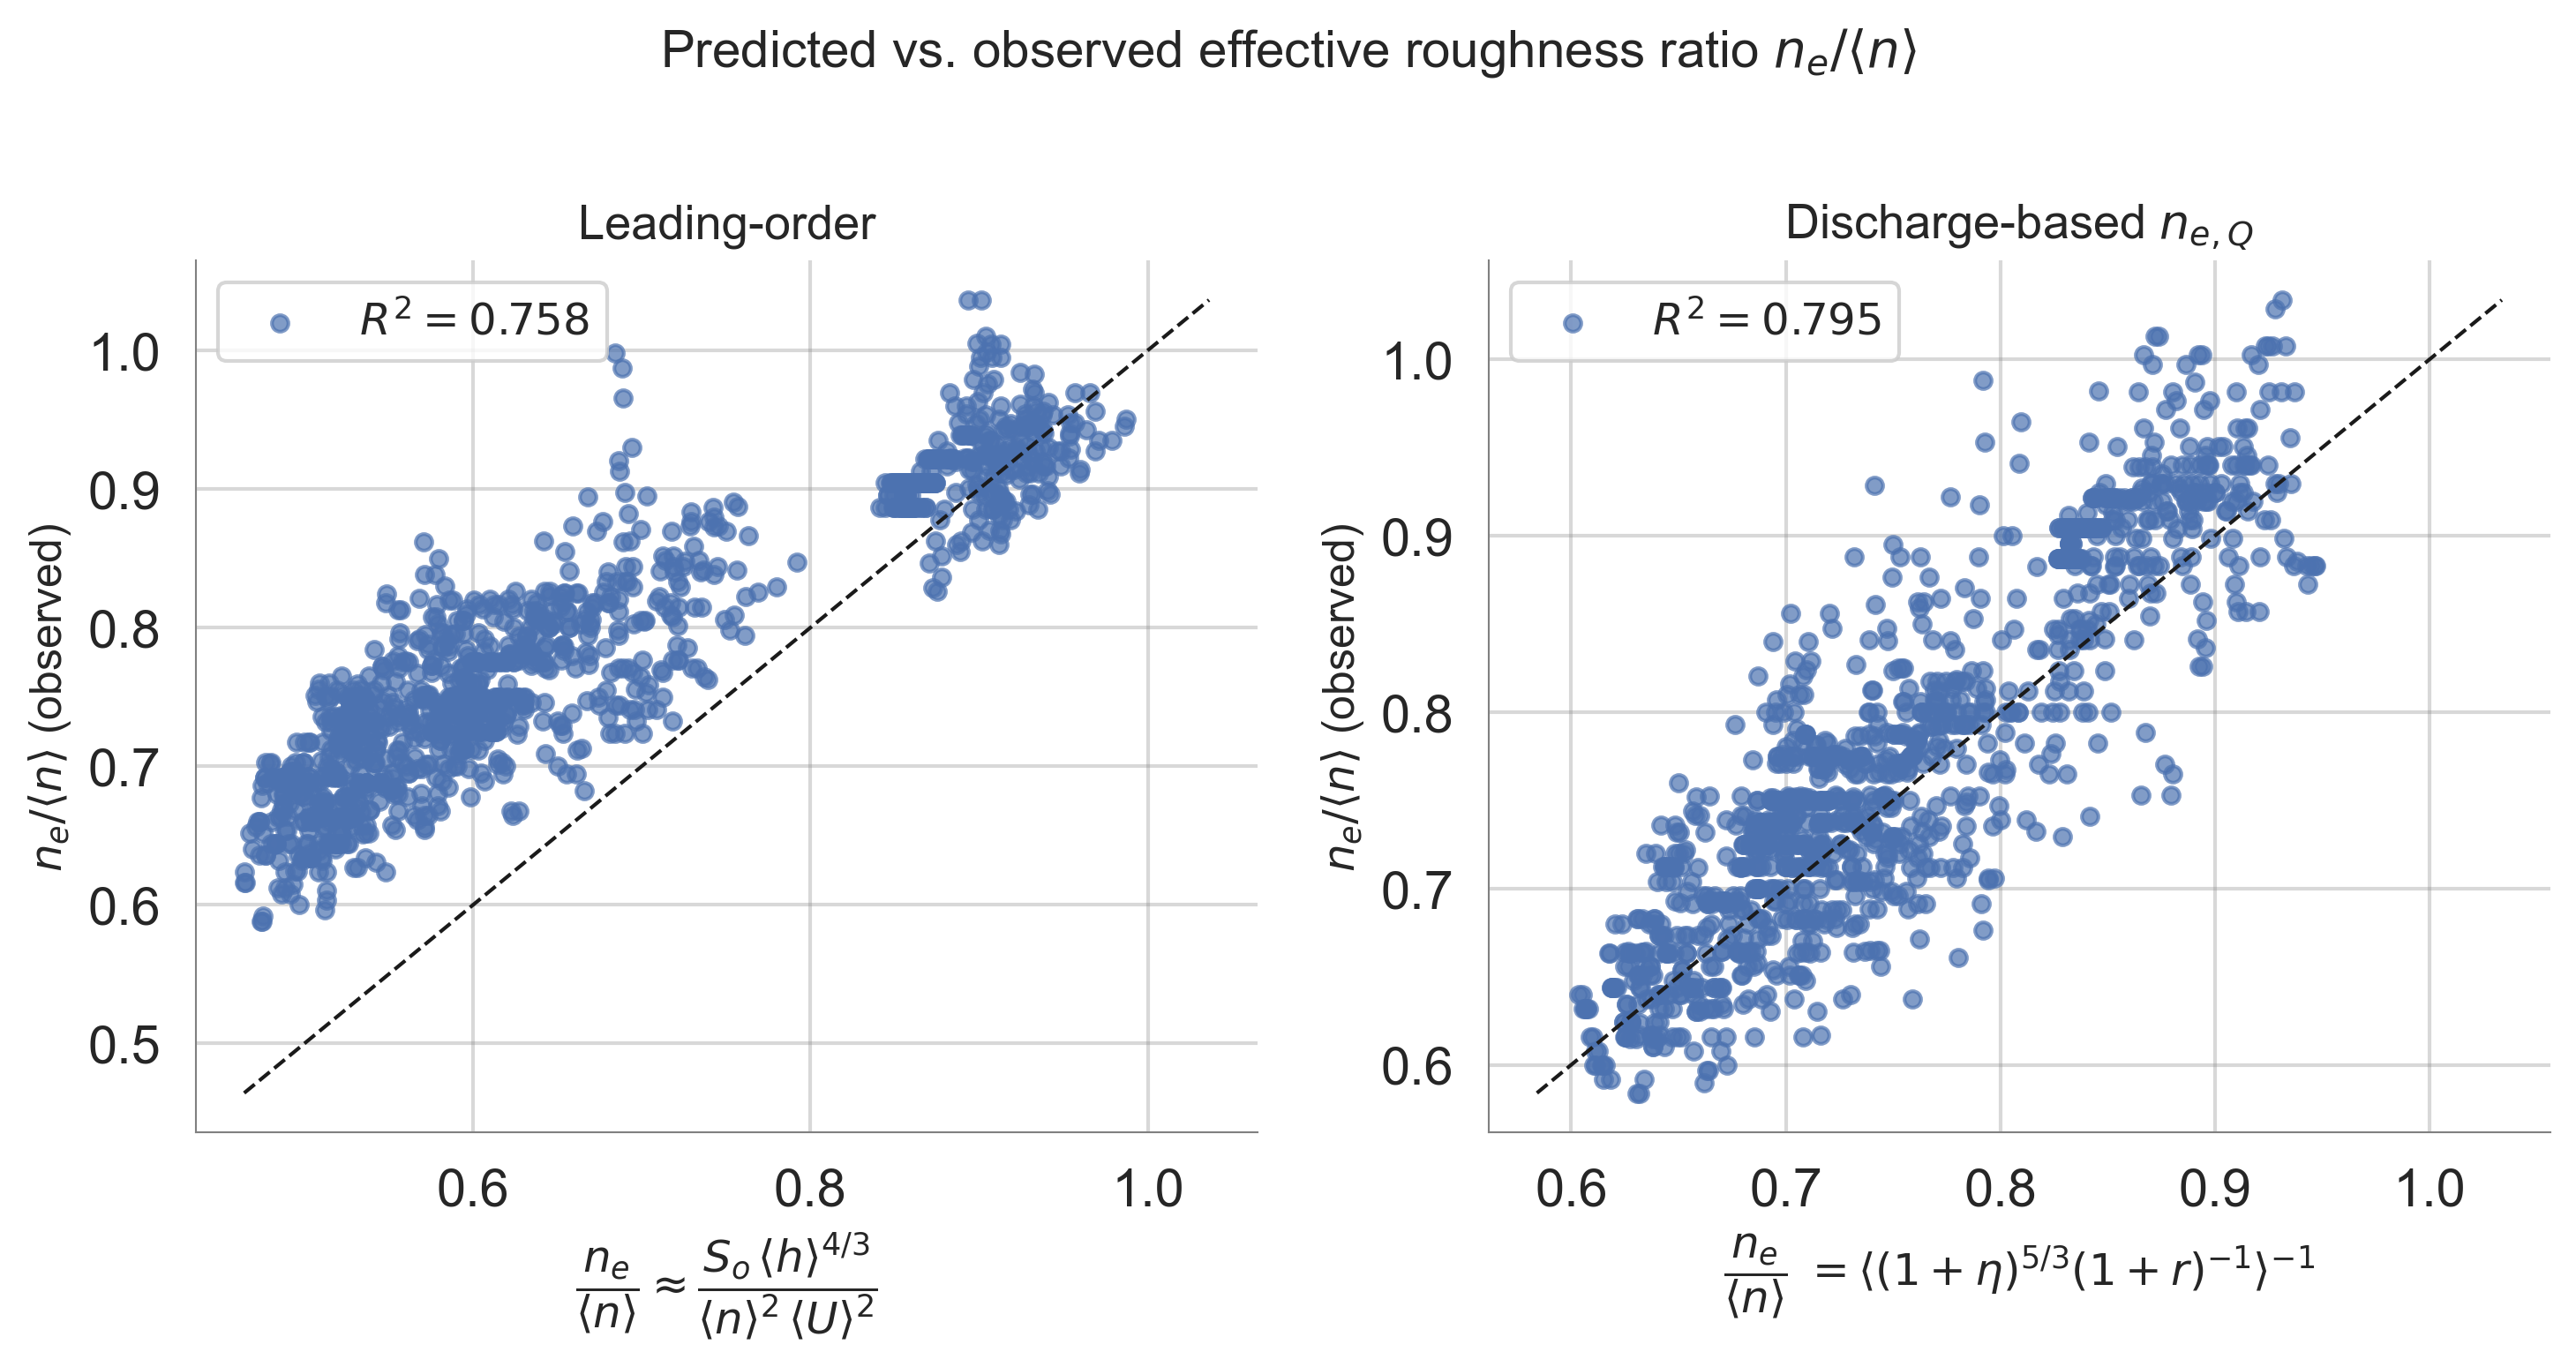

In [28]:

# Predicted vs observed — two analytic approximations
fig, axes = plt.subplots(1, 2, figsize=(10, 5.2))

# --- axis 0: leading-order (mean-roughness only) ---
ax = axes[0]
xy0 = (
    summary.assign(_obs=summary['So'] / summary['<Sf>_nbar2_Ubar2'])
           [['_obs', 'effect_ratio_hydro']]
           .dropna()
           .to_numpy(float))
if xy0.size:
    ax.scatter(xy0[:, 0], xy0[:, 1], alpha=0.7, s=20, label=f'$R^2 = {m_L["r2"]:.3f}$')
    mn0, mx0 = np.nanmin(xy0), np.nanmax(xy0)
    ax.plot([mn0, mx0], [mn0, mx0], 'k--', linewidth=1)

ax.set_xlabel(
    r'$\dfrac{n_e}{\langle n\rangle} \approx \dfrac{S_o\,\langle h\rangle^{4/3}}{\langle n\rangle^2\,\langle U\rangle^2}$',
    fontsize=FS_LABEL)
ax.set_ylabel(r'$n_e/\langle n\rangle$ (observed)', fontsize=FS_LABEL)
ax.set_title('Leading-order', fontsize=FS_TITLE)
ax.legend(fontsize=FS_LEG, loc='upper left')
ax.grid(True, alpha=0.3)

# --- axis 1: discharge-based effective roughness ---
ax = axes[1]
xy = summary[['effect_ratio_Q', 'effect_ratio']].dropna().to_numpy(float)
if xy.size:
    ax.scatter(xy[:, 0], xy[:, 1], alpha=0.7, s=20, label=f'$R^2 = {m_Q["r2"]:.3f}$')
    mn, mx = np.nanmin(xy), np.nanmax(xy)
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1)

ax.set_xlabel(
    r'$\dfrac{n_e}{\langle n\rangle}  $'
    + r' $= \langle(1+\eta)^{5/3}(1+r)^{-1}\rangle^{-1}$',
    #  \dfrac{\langle h\rangle^{5/3}}{\langle n\rangle\,\langle h^{5/3}/n\rangle}
    fontsize=FS_LABEL)
ax.set_ylabel(r'$n_e/\langle n\rangle$ (observed)', fontsize=FS_LABEL)
ax.set_title(f'Discharge-based $n_{{e,Q}}$', fontsize=FS_TITLE)
ax.legend(fontsize=FS_LEG, loc='upper left')
ax.grid(True, alpha=0.3)

fig.suptitle(r'Predicted vs. observed effective roughness ratio $n_e/\langle n\rangle$',
             fontsize=FS_TITLE + 1, y=1.0)
fig.tight_layout()

_, _scratch, _ = _fig_dirs()
fig.savefig(_os.path.join(_scratch, 'pred_vs_obs_2panel.png'), dpi=200, bbox_inches='tight')
print(f'Saved → {_scratch}/pred_vs_obs_2panel.png')

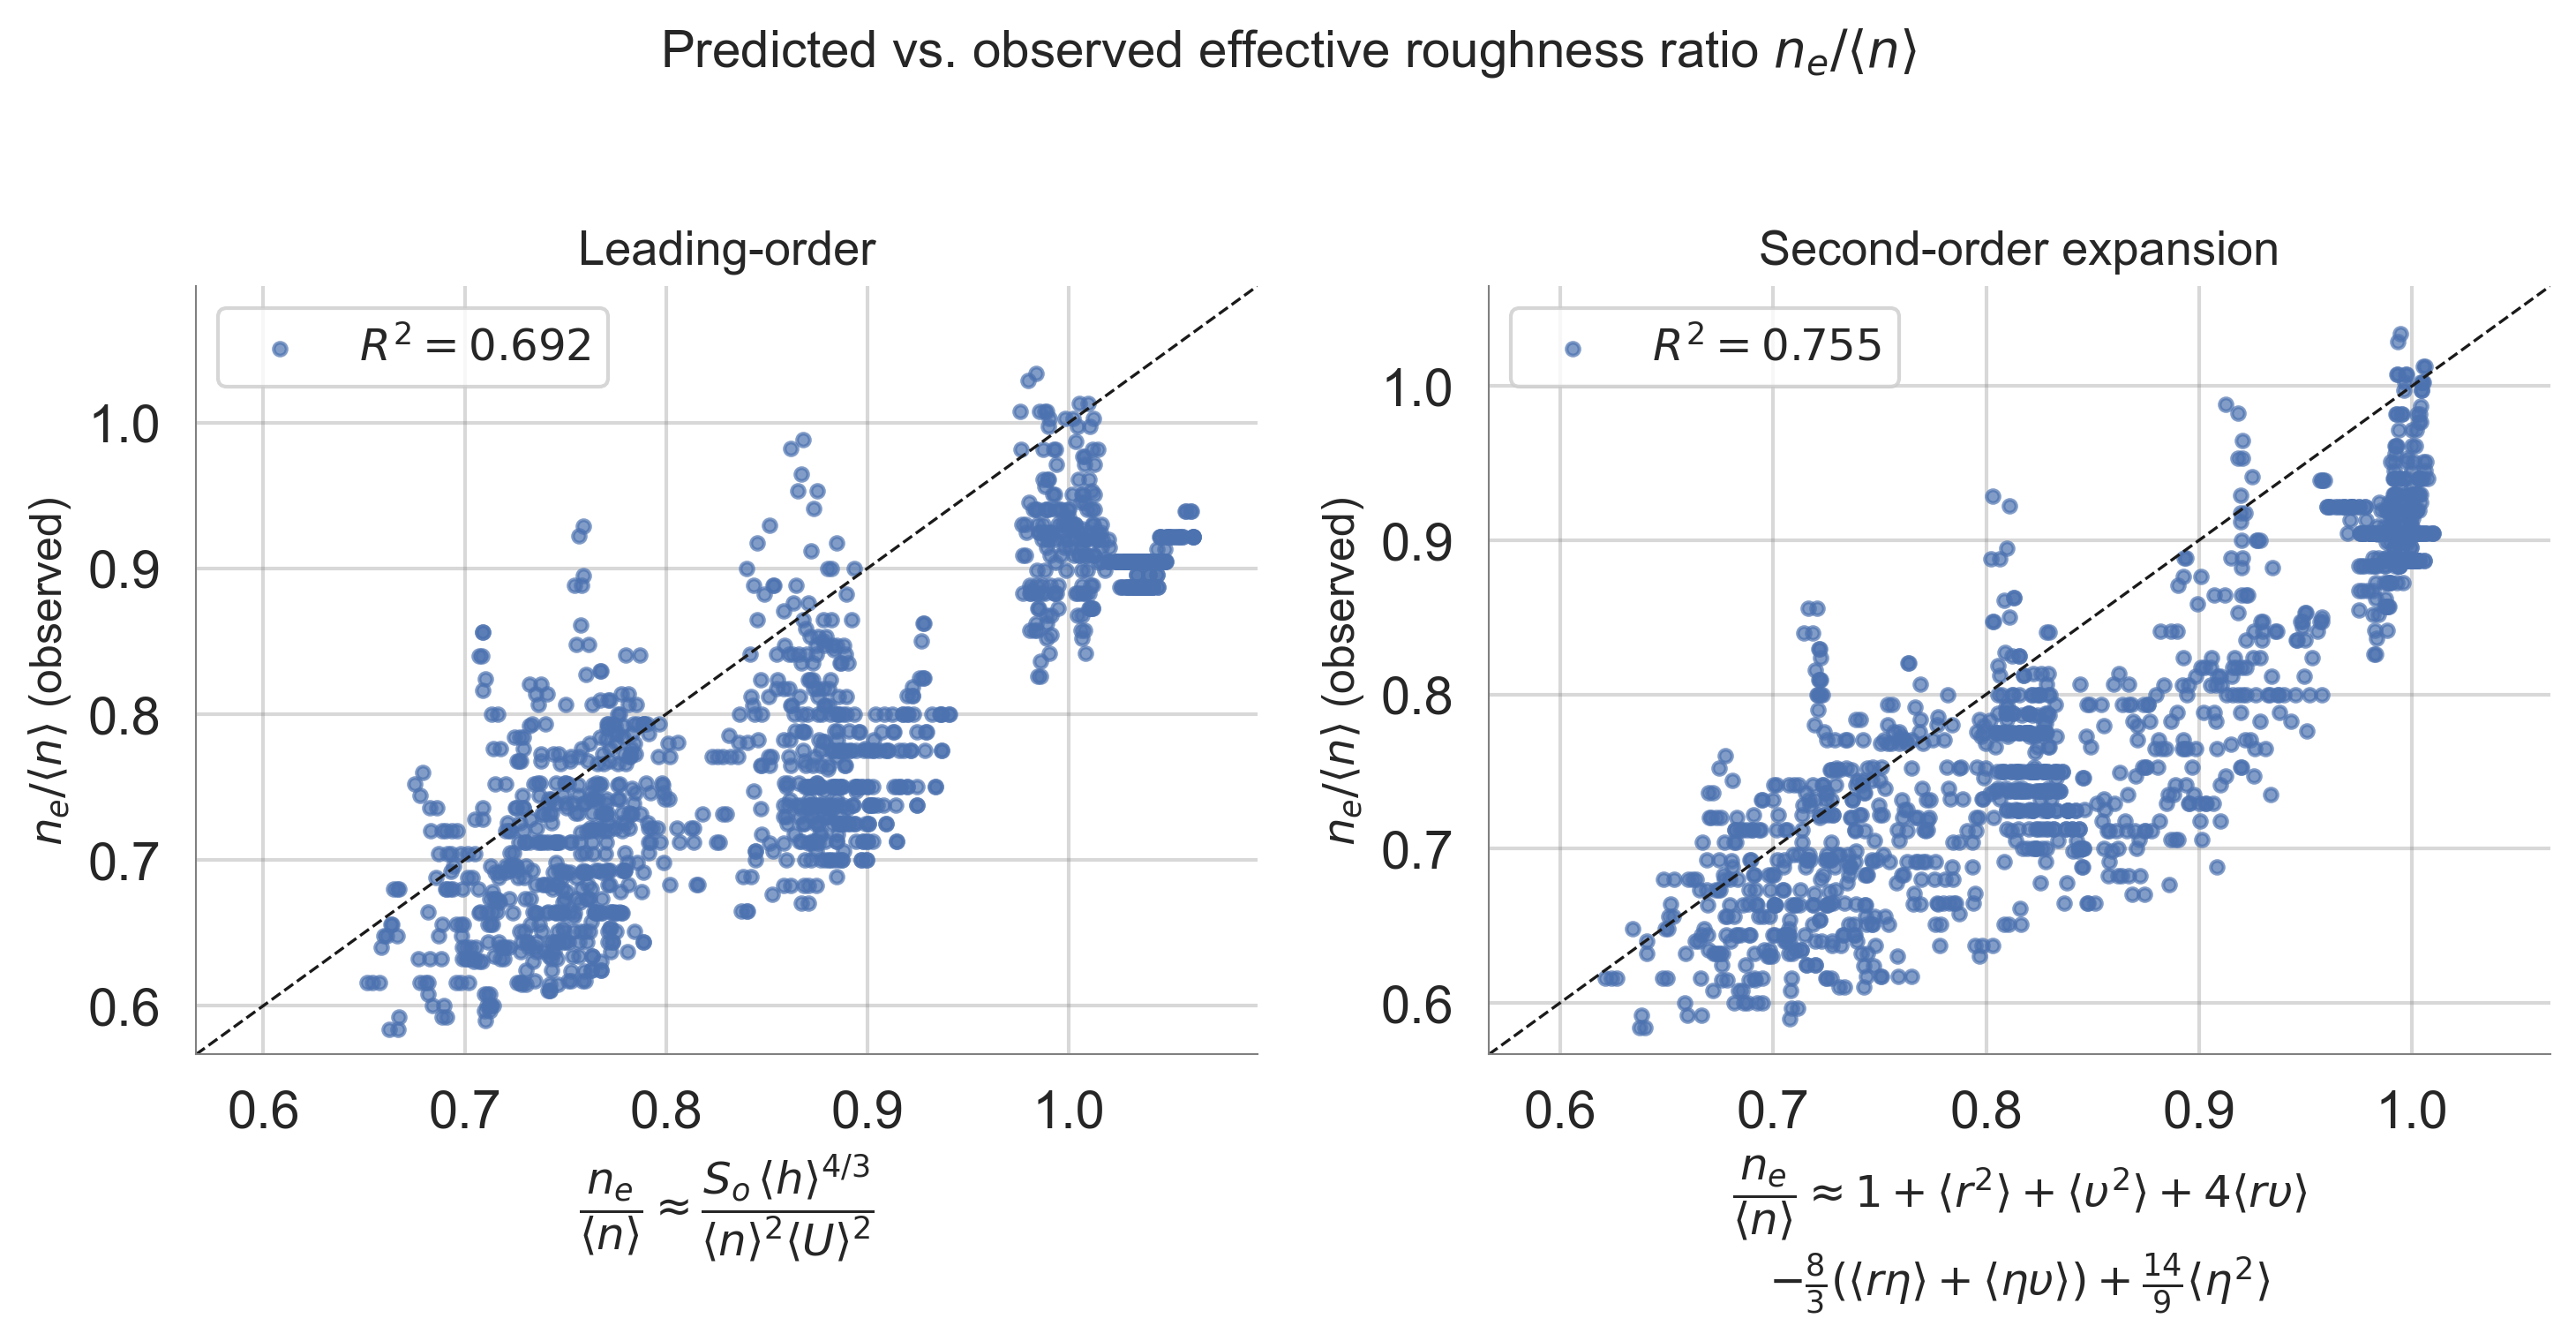

In [29]:
# Predicted vs observed (Q)
fig, axes = plt.subplots(1, 2, figsize = (10, 5))

_configs = [
    ('effect_ratio_T0',
     'Leading-order',
     r'$\dfrac{n_e}{\langle n\rangle} \approx \dfrac{S_o\,\langle h\rangle^{4/3}}{\langle n\rangle^2\langle U\rangle^2}$'),

    ('effect_ratio_T2',
     'Second-order expansion',
     r'$\dfrac{n_e}{\langle n\rangle} \approx 1 + \langle r^2\rangle + \langle\upsilon^2\rangle + 4\langle r\upsilon\rangle$'
     '\n'
     r'$- \frac{8}{3}(\langle r\eta\rangle + \langle\eta\upsilon\rangle) + \frac{14}{9}\langle\eta^2\rangle$'),

]

for ax, (xcol, title, xlabel) in zip(axes, _configs):
    xy = summary[[xcol, 'effect_ratio']].dropna().to_numpy(float)
    x, y = xy[:, 0], xy[:, 1]
    r2 = float(np.corrcoef(x, y)[0, 1]**2) if len(x) > 2 else float('nan')
    ax.scatter(x, y, s=12, alpha=0.7, label=f'$R^2 = {r2:.3f}$')
    lims = [min(x.min(), y.min()) * 0.97, max(x.max(), y.max()) * 1.03]
    ax.plot(lims, lims, 'k--', linewidth=0.8)
    ax.set_xlabel(xlabel, fontsize=FS_LABEL)
    ax.set_ylabel(r'$n_e / \langle n \rangle$ (observed)', fontsize=FS_LABEL)
    ax.set_title(title, fontsize=FS_TITLE )
    ax.legend(fontsize=FS_LEG, loc='upper left')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.grid(True, alpha=0.3)

fig.suptitle(r"Predicted vs. observed effective roughness ratio $n_e/\langle n\rangle$",
             fontsize=FS_TITLE + 1, y=1.02)
fig.tight_layout()
plt.show()
plt.close(fig)


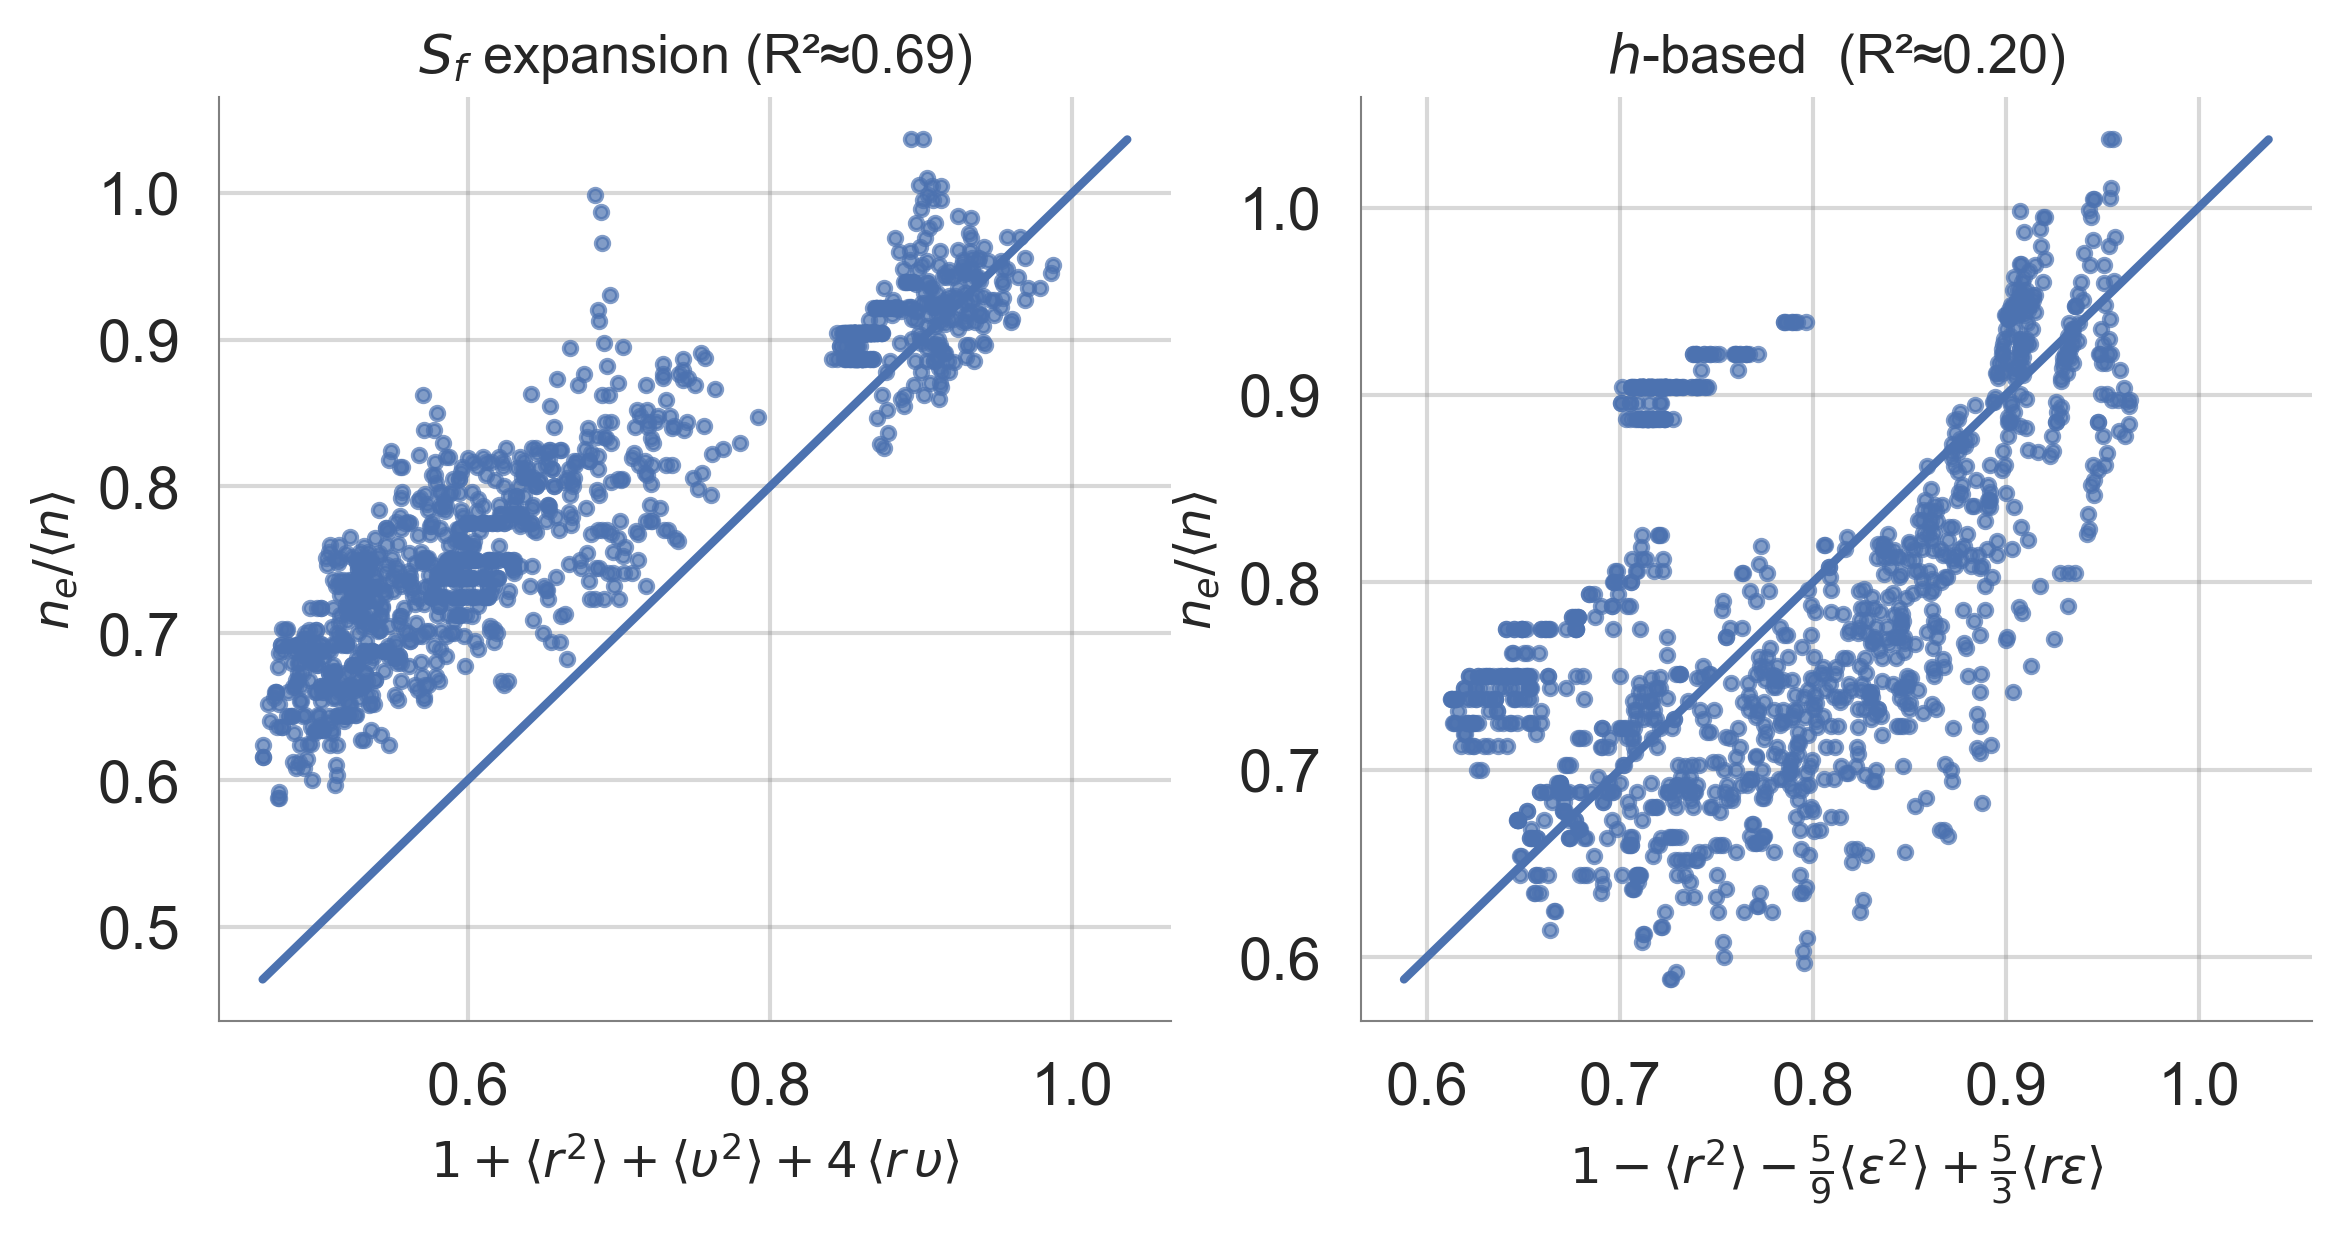

In [30]:
# Predicted vs observed (Q)
fig, axes = plt.subplots(1, 2, figsize = (9, 4))

# --- axis 0 ---
ax = axes[0]
xy0 = (
    summary.assign(_obs = summary['So'] / summary['<Sf>_nbar2_Ubar2'])
           [[ '_obs', 'effect_ratio_hydro']]
           .dropna()
           .to_numpy(float))
if xy0.size:
    ax.scatter(xy0[:, 0], xy0[:, 1], alpha=0.7, s= 10)
    mn0, mx0 = np.nanmin(xy0), np.nanmax(xy0)
    ax.plot([mn0, mx0], [mn0, mx0], linewidth=2)


    
label =  r'$1 + \langle r^{2}\rangle + \langle \upsilon^{2}\rangle + 4\,\langle r\,\upsilon\rangle$'
ax.set_xlabel(label, fontsize=12)
ax.set_ylabel(r"${n_e}/{\langle n\rangle}$", fontsize=12)
ax.set_title(r'$S_f$ expansion' + f" (R²≈{m_T0['r2']:.2f})", fontsize=13)
ax.grid(True, alpha=0.3)

# --- axis 1: Q-based vs observed ---
ax = axes[1]
xy = summary[["effect_ratio_Qpred2", "effect_ratio_hydro"]].dropna().to_numpy(float)
if xy.size:
    ax.scatter(xy[:,0], xy[:,1],  s= 10, alpha=0.7)
    mn, mx = np.nanmin(xy), np.nanmax(xy)
    ax.plot([mn,mx],[mn,mx], linewidth=2)


ax.set_ylabel(r"${n_e}/{\langle n\rangle}$", fontsize=12)
ax.set_xlabel(r"$1 - \langle r^2 \rangle - \frac{5}{9}\langle \epsilon^2 \rangle + \frac{5}{3}\left\langle r \epsilon \right\rangle$", fontsize=12)
ax.set_title(f"$h$-based  (R²≈{m_Qpred2['r2']:.2f})", fontsize=13)
ax.grid(True, alpha=0.3)
plt.show()


In [31]:
# summary['effect_ratio'] = 1/summary['effect_ratio']
(summary.query("hydro_err < 1")[['effect_ratio_hydro', '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU',  
                                 '<Sf>_Ubar2_np2',  '<Sf>_nbar2_Up2']].corr()).round(3)


,effect_ratio_hydro,<Sf>_nbar2_Ubar2,<Sf>_cross_nU,<Sf>_Ubar2_np2,<Sf>_nbar2_Up2
effect_ratio_hydro,1.000,-0.922,0.921,-0.683,-0.771
<Sf>_nbar2_Ubar2,-0.922,1.000,-0.999,0.748,0.811
<Sf>_cross_nU,0.921,-0.999,1.000,-0.749,-0.809
<Sf>_Ubar2_np2,-0.683,0.748,-0.749,1.000,0.242
<Sf>_nbar2_Up2,-0.771,0.811,-0.809,0.242,1.000


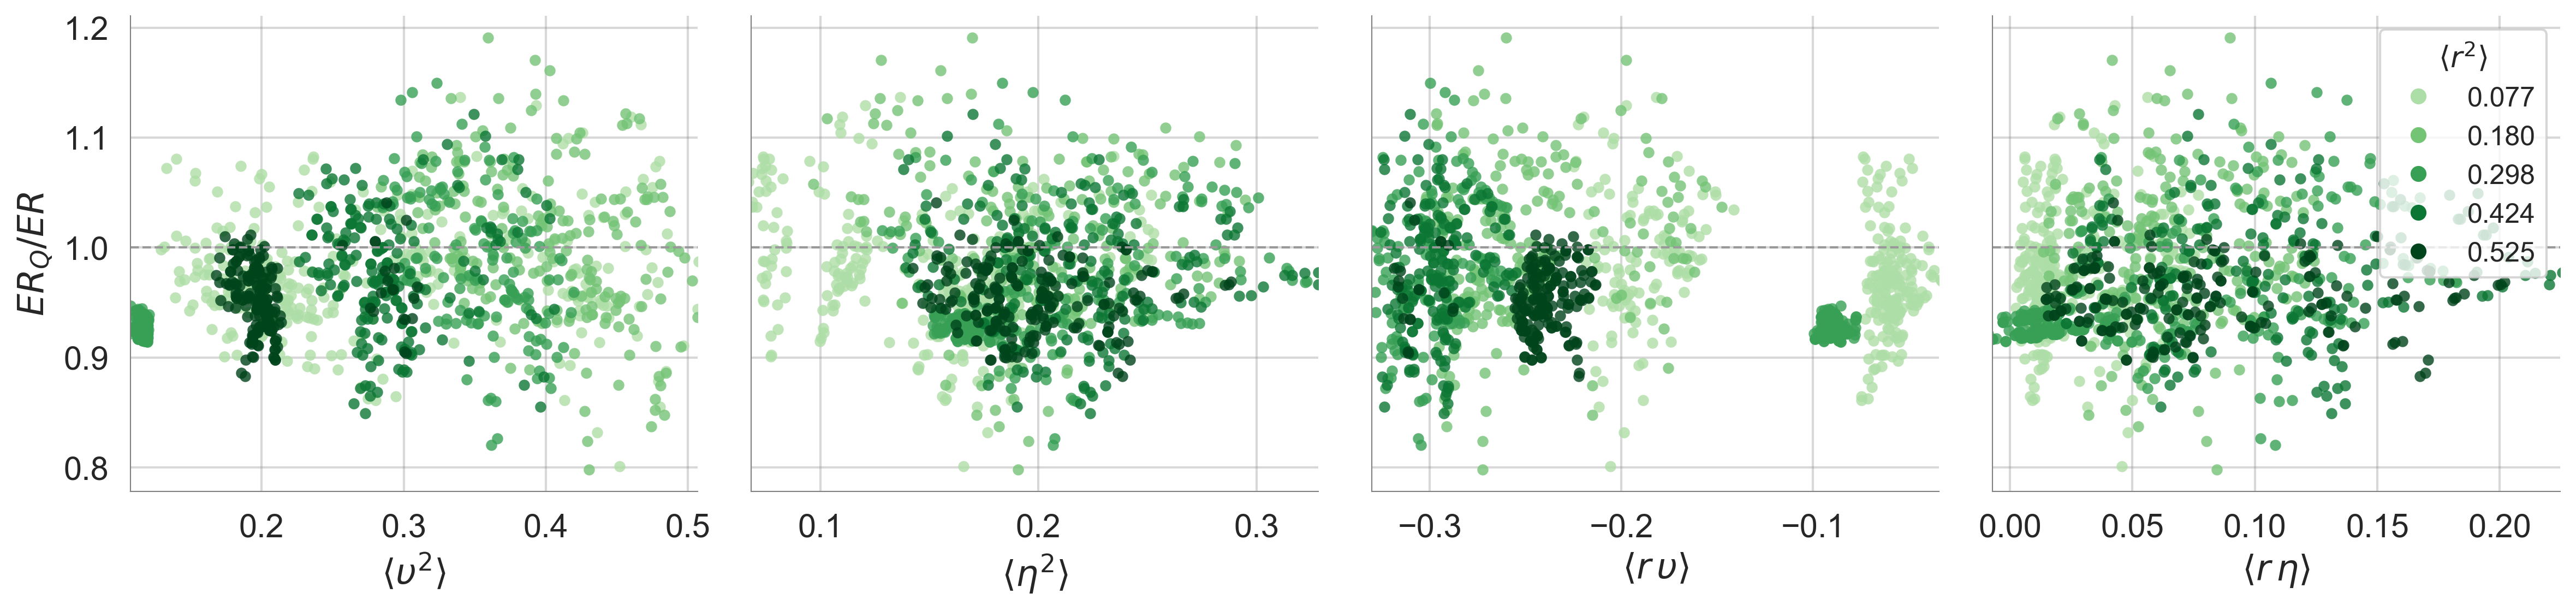

In [32]:

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def plot_er_ratio_4cols(summary: pd.DataFrame,
                        err_thresh: float = 0.05,    # filter on hydro_err
                        figsize=(16, 4),
                        s: float = 24, alpha: float = 0.8,
                        n_bins: int = 5,             # number of discrete <r2> bins
                        clip_percentiles=None):      # e.g., (1,99) to clip x/y
    """
    Four-panel plot of ER_Q/ER vs <ups2>, <eta2>, <r ups>, <r eta>,
    colored by binned <r2> with a point legend showing bin midpoints.
    Returns (fig, axes).
    """
    er_col = "effect_ratio_Q"

    # Observed ER
    if "effect_ratio" in summary.columns:
        ER_obs = summary["effect_ratio"]
    elif {"r_equiv5", "<n>"}.issubset(summary.columns):
        ER_obs = summary["r_equiv5"] / summary["<n>"]
    else:
        raise ValueError("Need 'effect_ratio' or both 'r_equiv5' and '<n>'.")

    # Filter once
    df = summary.query("hydro_err < @err_thresh").copy()

    # Coerce to numeric
    cols_needed = ["<ups2>", "<eta2>", "<r ups>", "<r eta>", "<r2>", er_col]
    for c in cols_needed:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")
        df[c] = pd.to_numeric(df[c], errors="coerce")
    ERo = pd.to_numeric(ER_obs.loc[df.index], errors="coerce")

    # Response
    y = df[er_col] / ERo

    # Bin <r2> into discrete categories
    r2 = df["<r2>"]
    valid = r2.notna() & y.notna() & np.isfinite(y)
    bin_edges = np.nanpercentile(r2[valid], np.linspace(0, 100, n_bins + 1))
    bin_edges = np.unique(bin_edges)
    n_actual = len(bin_edges) - 1
    bin_mids = [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(n_actual)]
    bin_mid_labels = [f"{m:.3f}" for m in bin_mids]
    bin_range_labels = [
        f"[{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f})"
        for i in range(n_actual)
    ]
    r2_binned = pd.cut(r2, bins=bin_edges, labels=bin_range_labels, include_lowest=True)

    cmap = plt.get_cmap("Greens", n_actual + 2)  # +2 to avoid very light start
    bin_colors = {lbl: cmap((i + 2) / (n_actual + 2)) for i, lbl in enumerate(bin_range_labels)}

    # Panel definitions
    xcols  = ["<ups2>", "<eta2>", "<r ups>", "<r eta>"]
    xlabels = [r"$\langle \upsilon^{2}\rangle$",
               r"$\langle \eta^{2}\rangle$",
               r"$\langle r\,\upsilon\rangle$",
               r"$\langle r\,\eta\rangle$"]

    fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=True)

    for ax, xcol, xlab in zip(axes, xcols, xlabels):
        x = df[xcol]
        for lbl in bin_range_labels:
            m = (r2_binned == lbl) & x.notna() & y.notna() & np.isfinite(y)
            if m.any():
                ax.scatter(x[m], y[m], color=bin_colors[lbl],
                           s=s, alpha=alpha, linewidths=0)
        ax.axhline(1.0, color="0.6", lw=1, ls="--")
        ax.set_xlabel(xlab)
        ax.grid(True, alpha=0.3)

        if clip_percentiles is not None:
            lo, hi = clip_percentiles
            m_all = x.notna() & np.isfinite(y)
            if m_all.any():
                ax.set_xlim(*np.nanpercentile(x[m_all], [lo, hi]))

    axes[0].set_ylabel(r"$ER_Q/ER$")

    # Point legend: one entry per bin, label = midpoint value
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               color=bin_colors[lbl], markersize=6, label=bin_mid_labels[i])
        for i, lbl in enumerate(bin_range_labels)
    ]
    axes[-1].legend(handles=legend_handles, title=r"$\langle r^{2}\rangle$",
                    fontsize=12, title_fontsize=13,
                    loc="best", frameon=True)

    fig.tight_layout()
    return fig, axes

# Call with Q-based only:
fig, axes = plot_er_ratio_4cols(summary, err_thresh=0.05, clip_percentiles=(.1,99.9))

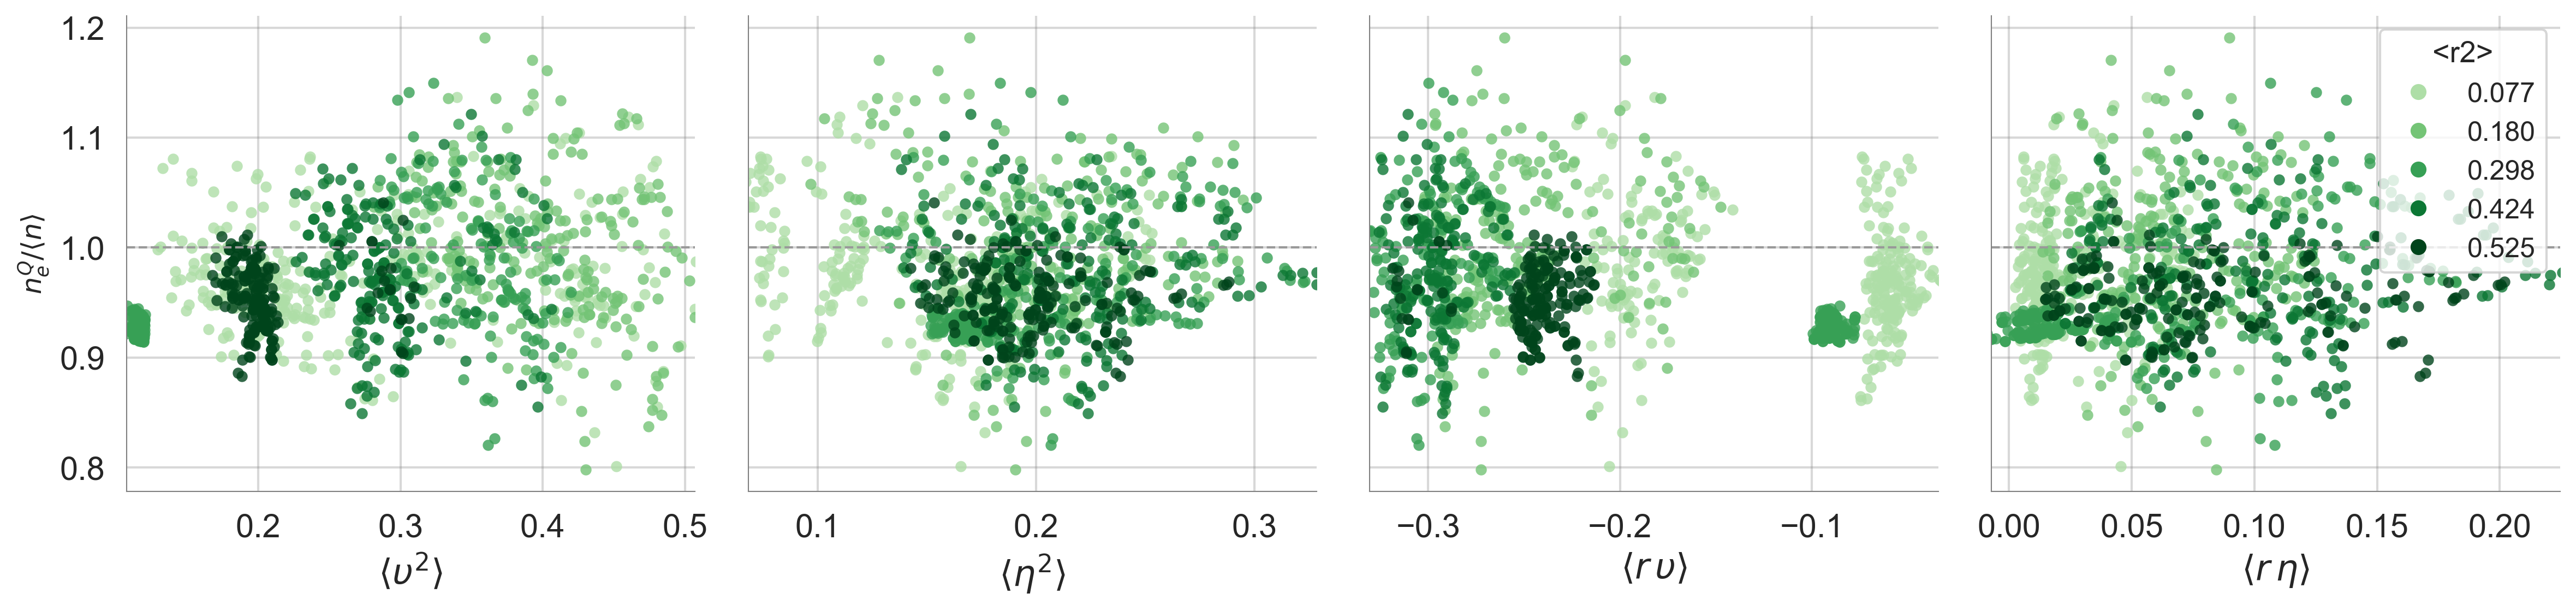

In [33]:
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def plot_er_ratio_4cols(summary: pd.DataFrame,
                        err_thresh: float = 0.05,    # filter on hydro_err
                        figsize=(16, 4),
                        s: float = 24, alpha: float = 0.8,
                        n_bins: int = 5,             # number of discrete <r2> bins
                        clip_percentiles=None):      # e.g., (1,99) to clip x/y
    """
    Four-panel plot of ER_Q/ER vs <ups2>, <eta2>, <r ups>, <r eta>,
    colored by binned <r2> with a point legend showing bin midpoints.
    Returns (fig, axes).
    """
    er_col = "effect_ratio_Q"

    # Observed ER
    if "effect_ratio" in summary.columns:
        ER_obs = summary["effect_ratio"]
    elif {"r_equiv5", "<n>"}.issubset(summary.columns):
        ER_obs = summary["r_equiv5"] / summary["<n>"]
    else:
        raise ValueError("Need 'effect_ratio' or both 'r_equiv5' and '<n>'.")

    # Filter once
    df = summary.query("hydro_err < @err_thresh").copy()

    # Coerce to numeric
    cols_needed = ["<ups2>", "<eta2>", "<r ups>", "<r eta>", "<r2>", er_col]
    for c in cols_needed:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")
        df[c] = pd.to_numeric(df[c], errors="coerce")
    ERo = pd.to_numeric(ER_obs.loc[df.index], errors="coerce")

    # Response
    y = df[er_col] / ERo

    # Bin <r2> into discrete categories
    r2 = df["<r2>"]
    valid = r2.notna() & y.notna() & np.isfinite(y)
    bin_edges = np.nanpercentile(r2[valid], np.linspace(0, 100, n_bins + 1))
    bin_edges = np.unique(bin_edges)
    n_actual = len(bin_edges) - 1
    bin_mids = [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(n_actual)]
    bin_mid_labels = [f"{m:.3f}" for m in bin_mids]
    bin_range_labels = [
        f"[{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f})"
        for i in range(n_actual)
    ]
    r2_binned = pd.cut(r2, bins=bin_edges, labels=bin_range_labels, include_lowest=True)

    cmap = plt.get_cmap("Greens", n_actual + 2)  # +2 to avoid very light start
    bin_colors = {lbl: cmap((i + 2) / (n_actual + 2)) for i, lbl in enumerate(bin_range_labels)}

    # Panel definitions
    xcols  = ["<ups2>", "<eta2>", "<r ups>", "<r eta>"]
    xlabels = [r"$\langle \upsilon^{2}\rangle$",
               r"$\langle \eta^{2}\rangle$",
               r"$\langle r\,\upsilon\rangle$",
               r"$\langle r\,\eta\rangle$"]

    fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=True)

    for ax, xcol, xlab in zip(axes, xcols, xlabels):
        x = df[xcol]
        for lbl in bin_range_labels:
            m = (r2_binned == lbl) & x.notna() & y.notna() & np.isfinite(y)
            if m.any():
                ax.scatter(x[m], y[m], color=bin_colors[lbl],
                           s=s, alpha=alpha, linewidths=0)
        ax.axhline(1.0, color="0.6", lw=1, ls="--")
        ax.set_xlabel(xlab)
        ax.grid(True, alpha=0.3)

        if clip_percentiles is not None:
            lo, hi = clip_percentiles
            m_all = x.notna() & np.isfinite(y)
            if m_all.any():
                ax.set_xlim(*np.nanpercentile(x[m_all], [lo, hi]))

    axes[0].set_ylabel(renameit(er_col, rename), fontsize=FS_LABEL)

    # Point legend: one entry per bin, label = midpoint value
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               color=bin_colors[lbl], markersize=6, label=bin_mid_labels[i])
        for i, lbl in enumerate(bin_range_labels)
    ]
    axes[-1].legend(handles=legend_handles, title=renameit('<r2>', rename),
                    fontsize=12, title_fontsize=13,
                    loc="best", frameon=True)

    fig.tight_layout()
    return fig, axes

# Call with Q-based only:
fig, axes = plot_er_ratio_4cols(summary, err_thresh=0.05, clip_percentiles=(.1,99.9))

### OLS regression of $n_e/\langle n\rangle$ on second-order variance components

In [34]:
# --- build table (observed & components) ---
cols = ["effect_ratio", "<r2>", "<eta2>", "<r eta>"]
df = summary.copy()
for c in cols:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")
dfM = df[cols].apply(pd.to_numeric, errors="coerce").dropna()

y    = dfM["effect_ratio"].to_numpy(float)
x_r2 = dfM["<r2>"].to_numpy(float)
x_e2 = dfM["<eta2>"].to_numpy(float)
x_re = dfM["<r eta>"].to_numpy(float)

from stats import fit_ols, eval_yhat

results = []

# ----- Full model: effect_ratio ~ 1 + <r2> + <eta2> + <r eta> -----
X_full = np.column_stack([np.ones_like(y), x_r2, x_e2, x_re])
b, r2_full, adj_full, yhat_full = fit_ols(X_full, y)
results.append({
    "model": "full",
    "R2":  r2_full,
    "adjR2": adj_full,
    "b0": b[0], "b_<r2>": b[1], "b_<eta2>": b[2], "b_<r eta>": b[3]
})

# ----- Drop <r2> -----
X_drop_r2 = np.column_stack([np.ones_like(y), x_e2, x_re])
b2, r2_dr, adj_dr, _ = fit_ols(X_drop_r2, y)
results.append({
    "model": "drop <r2>",
    "R2": r2_dr, "adjR2": adj_dr,
    "b0": b2[0], "b_<r2>": np.nan, "b_<eta2>": b2[1], "b_<r eta>": b2[2]
})

# ----- Drop <eta2> -----
X_drop_e2 = np.column_stack([np.ones_like(y), x_r2, x_re])
b3, r2_de, adj_de, _ = fit_ols(X_drop_e2, y)
results.append({
    "model": "drop <eta2>",
    "R2": r2_de, "adjR2": adj_de,
    "b0": b3[0], "b_<r2>": b3[1], "b_<eta2>": np.nan, "b_<r eta>": b3[2]
})

# ----- Drop <r eta> -----
X_drop_re = np.column_stack([np.ones_like(y), x_r2, x_e2])
b4, r2_dre, adj_dre, _ = fit_ols(X_drop_re, y)
results.append({
    "model": "drop <r eta>",
    "R2": r2_dre, "adjR2": adj_dre,
    "b0": b4[0], "b_<r2>": b4[1], "b_<eta2>": b4[2], "b_<r eta>": np.nan
})

# Assemble tidy table with R2 deltas vs full
res_df = pd.DataFrame(results)
res_df["ΔR2 (vs full)"] = res_df["R2"] - r2_full
res_df["ΔadjR2 (vs full)"] = res_df["adjR2"] - adj_full

# Print formatted view
cols_out = ["model","R2","ΔR2 (vs full)","adjR2","ΔadjR2 (vs full)",
            "b0","b_<r2>","b_<eta2>","b_<r eta>"]
print(res_df[cols_out].round(3).to_string(index=False))


# -------------------------------------------------------------------
#  THEORY from discharge result
#   Linearized (1/(1+A) ≈ 1 - A):  ER ≈ 1 - <r2> - (5/9)<eta2> + (5/3)<r eta>
#   Nonlinear:                     ER_th = 1 / (1 + <r2> + (5/9)<eta2> - (5/3)<r eta>)
# -------------------------------------------------------------------
# Pretty print: coefficients for effect_ratio ~ b0 + b1*<r2> + b2*<eta2> + b3*<r eta>
labels = ["b0", "b1 (<r2>)", "b2 (<eta2>)", "b3 (<r eta>)"]

def fmt_row(tag, vals, width=10, prec=3):
    def fmt_cell(v):
        # numbers -> fixed width with decimals; strings/NaNs -> right-aligned text
        if isinstance(v, (int, float, np.floating, np.integer)):
            return f"{v:>{width}.{prec}f}" if np.isfinite(v) else f"{str(v):>{width}}"
        return f"{str(v):>{width}}"
    return f"{tag:<10}" + " ".join(fmt_cell(v) for v in vals)

h_labels = ["b0", "b1 (<r2>)", "b2 (<eta2>)", "b3 (<r eta>)"]
b_theory = np.array([1.0, -1.0, -(5.0/9.0), +(5.0/3.0)])


print("\n=== H-based:  ER ≈ b0 + b1*<r2> + b2*<eta2> + b3*<r eta> ===")
print("Theory (linear):  ER ≈ 1 - <r2> - (5/9)<eta2> + (5/3)<r eta>")
print(fmt_row("coef",     h_labels, prec=0))
print(fmt_row("estimate", [b[0], b[1], b[2], b[3]]))
print(fmt_row("theory",   b_theory))

       model    R2  ΔR2 (vs full)  adjR2  ΔadjR2 (vs full)    b0  b_<r2>  b_<eta2>  b_<r eta>
        full 0.269          0.000  0.267             0.000 0.917  -0.235    -0.297     -0.118
   drop <r2> 0.146         -0.123  0.145            -0.122 0.886     NaN    -0.390     -0.481
 drop <eta2> 0.261         -0.008  0.260            -0.008 0.876  -0.240       NaN     -0.326
drop <r eta> 0.268         -0.001  0.266            -0.001 0.927  -0.242    -0.376        NaN

=== H-based:  ER ≈ b0 + b1*<r2> + b2*<eta2> + b3*<r eta> ===
Theory (linear):  ER ≈ 1 - <r2> - (5/9)<eta2> + (5/3)<r eta>
coef              b0  b1 (<r2>) b2 (<eta2>) b3 (<r eta>)
estimate       0.917     -0.235     -0.297     -0.118
theory         1.000     -1.000     -0.556      1.667


In [35]:
# --------------------------- configuration ---------------------------
target_col  = "<Sf>_nbar2_Ubar2"          # y (means-only term already in your df)
feat_cols   = ["<U>", "<h>", "<n>"]     # X: Ua, ha, n
cv_folds    = 5
rng_seed    = 42

# --------------------------- data prep ---------------------------
if target_col not in summary.columns:
    raise KeyError(f"Missing '{target_col}' in dataframe.")

missing = [c for c in feat_cols if c not in summary.columns]
if missing:
    raise KeyError(f"Missing feature columns: {missing}")

df = summary[[target_col, *feat_cols]].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# positivity for log-transform
pos_mask = (df[target_col] > 0)
for c in feat_cols:
    pos_mask &= (df[c] > 0)

df = df.loc[pos_mask].copy()
if df.empty:
    raise ValueError("No valid rows after filtering for positivity & non-NaNs.")

y  = df[target_col].to_numpy(dtype=float)
Ua = df["<U>"].to_numpy(dtype=float)
ha = df["<h>"].to_numpy(dtype=float)
nn = df["<n>"].to_numpy(dtype=float)

N = len(df)

print("=" * 55)
print("FITTING SUMMARY")
print("=" * 55)
print(f"  Target  (y) : {target_col}")
print(f"  Features (X): {feat_cols}")
print(f"  Rows used   : N = {N}  (after NaN + positivity filter)")
print("=" * 55)

# --------------------------- helper metrics ---------------------------
def r2(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 2:
        return np.nan
    ssr = np.sum((y_true[m] - y_pred[m])**2)
    sst = np.sum((y_true[m] - np.mean(y_true[m]))**2)
    return 1.0 - ssr/sst if sst > 0 else np.nan

def rmse(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.sqrt(np.nanmean((y_true[m] - y_pred[m])**2))

# --------------------------- (1) free power-law fit ---------------------------
# log y = alpha + a*log Ua + b*log ha + c*log n
logy  = np.log(y)
X_log = np.column_stack([np.ones(N), np.log(Ua), np.log(ha), np.log(nn)])

beta, *_ = np.linalg.lstsq(X_log, logy, rcond=None)
alpha, a_hat, b_hat, c_hat = beta

# standard errors & 95% CI in log-space
resid   = logy - X_log @ beta
p       = X_log.shape[1]
dof     = max(N - p, 1)
sigma2  = float(np.sum(resid**2) / dof)
# Use pseudo-inverse for stability
XtX_inv = np.linalg.pinv(X_log.T @ X_log)
se      = np.sqrt(np.diag(sigma2 * XtX_inv))

alpha_ci = (alpha - 1.96*se[0], alpha + 1.96*se[0])
a_ci     = (a_hat - 1.96*se[1], a_hat + 1.96*se[1])
b_ci     = (b_hat - 1.96*se[2], b_hat + 1.96*se[2])
c_ci     = (c_hat - 1.96*se[3], c_hat + 1.96*se[3])

A_hat = np.exp(alpha)
y_pred_free = A_hat * (Ua**a_hat) * (ha**b_hat) * (nn**c_hat)

print("\n--- Free power-law fit (log-space OLS) ---")
print(f"log A  = {alpha: .3f}  (95% CI: {alpha_ci[0]: .3f}, {alpha_ci[1]: .3f})")
print(f"a (U) = {a_hat: .3f}  (95% CI: {a_ci[0]: .3f}, {a_ci[1]: .3f})")
print(f"b (h) = {b_hat: .3f}  (95% CI: {b_ci[0]: .3f}, {b_ci[1]: .3f})")
print(f"c (n ) = {c_hat: .3f}  (95% CI: {c_ci[0]: .3f}, {c_ci[1]: .3f})")
print(f"R^2 (linear space) = {r2(y, y_pred_free):.3f}")
print(f"RMSE (linear space)= {rmse(y, y_pred_free):.3e}")

# --------------------------- (2) physics-anchored exponents ---------------------------
# Fixed a=2, b=-4/3, c=2; fit only alpha (i.e., A) in log-space
a_fix, b_fix, c_fix = 2.0, -4.0/3.0, 2.0
logX_fix = (a_fix*np.log(Ua) + b_fix*np.log(ha) + c_fix*np.log(nn))
alpha_fix = float(np.mean(logy - logX_fix))  # least-squares intercept
A_fix = float(np.exp(alpha_fix))
y_pred_phys = A_fix * (Ua**a_fix) * (ha**b_fix) * (nn**c_fix)

print("\n--- a=2, b=-4/3, c=2; fit A only ---")
print(f"log A  = {alpha_fix: .3f}  ->  A = {A_fix:.3e}")
print(f"R^2 (linear space) = {r2(y, y_pred_phys):.3f}")
print(f"RMSE (linear space)= {rmse(y, y_pred_phys):.3e}")


FITTING SUMMARY
  Target  (y) : <Sf>_nbar2_Ubar2
  Features (X): ['<U>', '<h>', '<n>']
  Rows used   : N = 1260  (after NaN + positivity filter)

--- Free power-law fit (log-space OLS) ---
log A  =  0.000  (95% CI:  0.000,  0.000)
a (U) =  2.000  (95% CI:  2.000,  2.000)
b (h) = -1.333  (95% CI: -1.333, -1.333)
c (n ) =  2.000  (95% CI:  2.000,  2.000)
R^2 (linear space) = 1.000
RMSE (linear space)= 5.222e-17

--- a=2, b=-4/3, c=2; fit A only ---
log A  = -0.000  ->  A = 1.000e+00
R^2 (linear space) = 1.000
RMSE (linear space)= 3.044e-18


## Banded results

In [36]:
summary.veg_type.unique()

array(['blob'], dtype=object)

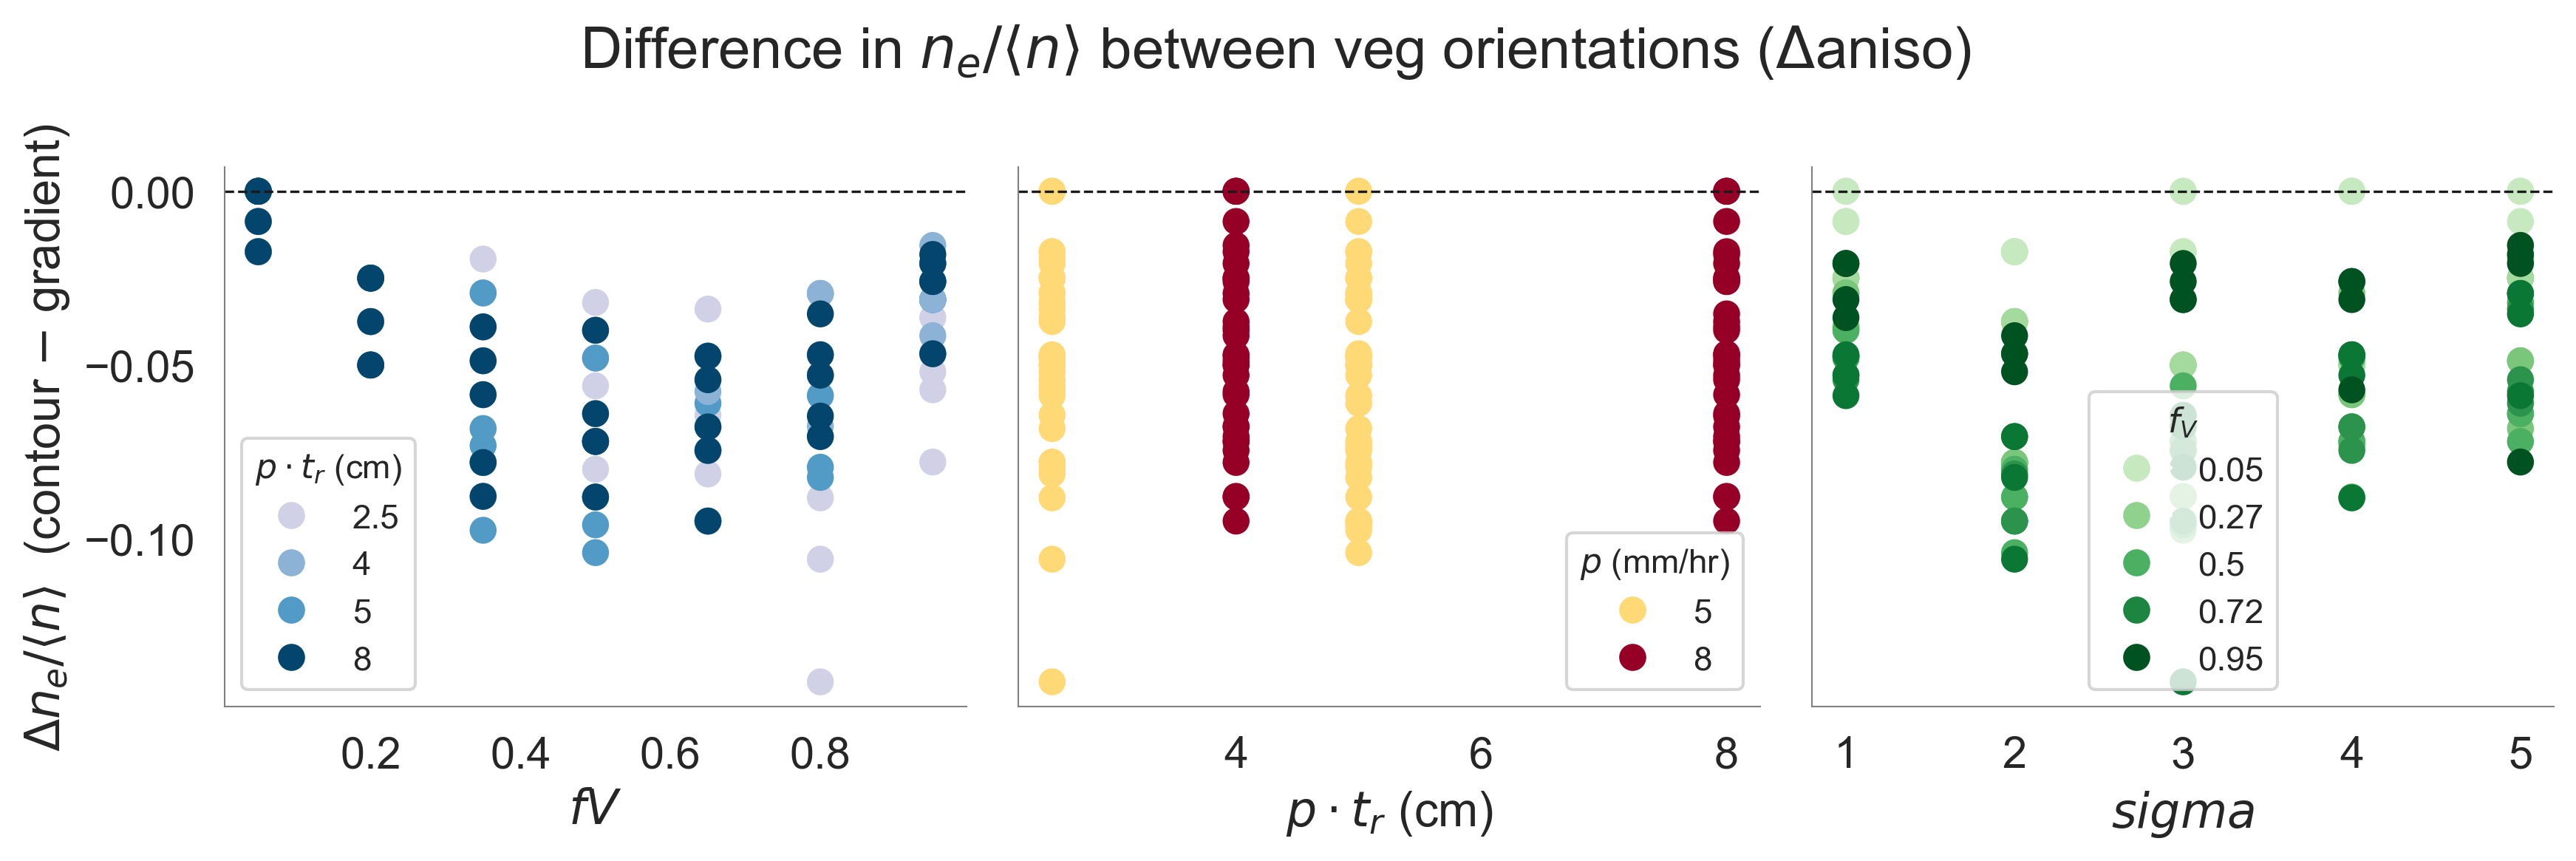

In [37]:
# Pivot so each row is a matched (fV, p, tr, sigma) group with one column per aniso value
# aniso: 2 = contour-aligned, -2 = gradient-aligned, 1 = isotropic
_other_vars = ['fV', 'p', 'tr', 'sigma']
_pivot = (
    summary.dropna(subset=['effect_ratio', 'sigma', 'aniso'])
           .groupby(_other_vars + ['aniso'])['effect_ratio']
           .median()
           .unstack('aniso')
           .reset_index()
)
_pivot['p*tr'] = _pivot['p'] * _pivot['tr'] / 60  # cm (mm/hr * min / 60)

# Difference: contour (aniso=2) minus gradient (aniso=-2)
_aniso_cols = [c for c in _pivot.columns if c not in _other_vars + ['p*tr']]
if 2 in _pivot.columns and -2 in _pivot.columns:
    _pivot['diff'] = _pivot[2] - _pivot[-2]
elif len(_aniso_cols) >= 2:
    _aniso_cols = sorted(_aniso_cols, reverse=True)  # highest first
    print(f'Warning: expected aniso columns 2 and -2; found {_aniso_cols}. Using {_aniso_cols[0]} − {_aniso_cols[1]}.')
    _pivot['diff'] = _pivot[_aniso_cols[0]] - _pivot[_aniso_cols[1]]
else:
    print(f'Warning: need ≥2 aniso levels to compute diff; found {_aniso_cols}. Setting diff=0.')
    _pivot['diff'] = 0.0

# hue variable and cmap per subplot; p*tr falls back to the 'p' palette
_hue_for  = {'fV': 'p*tr', 'p*tr': 'p', 'sigma': 'fV'}
_cmap_for = {'fV': 'p*tr', 'p*tr': 'p', 'sigma': 'fV'}  # key= x-var, value= hue var name for VAR_CMAPS lookup

def _get_cmap(hue_var):
    """Look up VAR_CMAPS using the hue variable."""
    cmap_name = VAR_CMAPS.get(hue_var, 'viridis')
    cmap = plt.get_cmap(cmap_name)
    # lighten very-dark sequential cmaps by using a truncated range
    return mpl.colors.LinearSegmentedColormap.from_list(
        f'trunc_{cmap_name}', cmap(np.linspace(0.25, 0.95, 256)))

# Plot diff vs each variable, coloured by the others
_plot_vars = ['fV', 'p*tr', 'sigma']
fig, axes = plt.subplots(1, len(_plot_vars), figsize=(4 * len(_plot_vars), 4), sharey=True)

for ci, (ax, xvar) in enumerate(zip(axes, _plot_vars)):
    hue_var = _hue_for[xvar]
    hue_vals = _pivot[hue_var]
    _cmap = _get_cmap(hue_var)
    norm = mpl.colors.Normalize(vmin=hue_vals.min(), vmax=hue_vals.max())
    colors = _cmap(norm(hue_vals))
    ax.scatter(_pivot[xvar], _pivot['diff'], c=colors, s=60, alpha=1)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel(r"$p \cdot t_r$ (cm)" if xvar == 'p*tr' else f"${xvar}$")
    ax.set_ylabel(r"$\Delta n_e/\langle n\rangle$  (contour $-$ gradient)" if ax is axes[0] else "")
    _unique_vals = np.sort(hue_vals.unique())
    _legend_vals = _unique_vals if len(_unique_vals) <= 4 else np.linspace(hue_vals.min(), hue_vals.max(), 5)
    _handles = [mpl.lines.Line2D([0],[0], marker='o', color='w', markersize=7,
                markerfacecolor=_cmap(norm(v)), label=f'{v:.2g}') for v in _legend_vals]
    _leg_titles = {'fV': r'$f_V$', 'p*tr': r'$p \cdot t_r$ (cm)', 'p': r'$p$ (mm/hr)', 'sigma': r'$\sigma$'}
    ax.legend(handles=_handles, title=_leg_titles.get(hue_var, hue_var),
              fontsize=11, title_fontsize=11, markerscale=1.4)

fig.suptitle(r"Difference in $n_e/\langle n\rangle$ between veg orientations ($\Delta$aniso)")
plt.tight_layout()
plt.show()


## Tracer flow visuals

_Visual diagnostics of tracer transport under varying storm intensities and durations._


In [ ]:
def format_plot(summary, xfld, yfld, cfld, cmap = cm.ocean, 
                alpha = 0.5, err_tol = 0.1, vmax = None, vmin = None,
                s = None, edgecolor = None):
    '''
    Will create a color-coded scatter plot for tracer fields
    '''
    if err_tol:
        inds = summary.query('abs_err < {0}'.format(err_tol)).index
    else: 
        inds = summary.index
    c = plt.scatter(summary.loc[inds][xfld].astype(float), 
                summary.loc[inds][yfld].astype(float), 
                c = summary.loc[inds][cfld].astype(float),  cmap = cmap, visible = 0, vmin = vmin, vmax = vmax)

    plt.scatter(summary.loc[inds][xfld].astype(float),  
                summary.loc[inds][yfld].astype(float),  
                c = summary.loc[inds][cfld].astype(float),  cmap = cmap, alpha =alpha,
                vmin = vmin, edgecolor = edgecolor,
                 vmax = vmax, s = s)

    plt.xlabel(format_name(xfld))
    plt.ylabel(format_name(yfld))
    plt.colorbar(c ,label = format_name(cfld))


In [ ]:
plt.figure(figsize = (6,4))
cfld = "aniso"
xfld = "curve"
yfld = 'effect_ratio'
subset = summary.query("hydro_err < 0.05 and fV > 0.1 and l == 200")
format_plot(subset, xfld, yfld, cfld, cmap = MAKO, alpha = 1)
plt.ylabel(rename[yfld])
plt.gca().set_xscale('log')
subset[['effect_ratio', 'curve']].corr().iloc[0, 1]
plt.show()


In [ ]:
# tortuosity here looks really low – visuals from GRL paper?
cfld = "sigma"
xfld = "curve"
yfld = 'effect_ratio'
subset = summary.query("hydro_err < 0.05 and fV > 0.15   and tr == 60")
format_plot(subset, xfld, yfld, cfld, cmap = MAKO, alpha = 1)
plt.ylabel(rename[yfld])

subset[['effect_ratio', 'curve']].corr().iloc[0, 1]


In [ ]:
# tortuosity here looks really low – visuals from GRL paper?
xfld = "LV"
cfld = "fV"
yfld = 'effect_ratio'
subset = summary.query("hydro_err < 0.05 and l > 10")
format_plot(subset, xfld, yfld, cfld, cmap = MAKO, alpha = 1, s=5)
plt.ylabel(rename[yfld])
# plt.gca().set_xscale('log')
subset[['effect_ratio', 'curve']].corr().iloc[0, 1]


In [ ]:
summary["fV"].to_numpy(float)


In [ ]:
def nrmse(x,y):
    
    return np.sqrt(np.sum((x - y)**2)/np.size(x))/np.mean(x)

def dislay_fit(subset, ax, target = 'f_cal',  cols = ['fV', 'l'], 
               cfld = "fV", colorbar = False):

    subset = subset.copy()   # prevent in-place mutation of the caller's DataFrame
    subset[cols] += 1

    res, subset, equation = wrap_fit(subset, cols , target )
    nrmse_val = nrmse(subset[target], make_prediction(res, cols, subset))
    
    c = ax.scatter( 
                 (subset[target]), 
                 (make_prediction(res, cols, subset)),
                 c = subset[cfld], alpha = 0.8, label = '$R^2 = {0:.2f}$'.format(res.rsquared, nrmse_val),
                 cmap = "coolwarm")

    ax.legend(loc = 'upper left', handletextpad=0.1)
    if colorbar == True:
        cbaxes = fig.add_axes([0.91, 0.1, 0.008, 0.75])
        plt.colorbar(c, label = format_name(cfld), cax  = cbaxes)

    ax.set_xlabel(format_name(target).replace("m1", "T"));
    ax.set_ylabel( 'predicted ' + format_name(target).replace("m1", "T"));

    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x, c = 'k', lw = .5)


    ax.set_ylim(np.percentile(subset[target].dropna(), 0)/2, )
    ax.set_xlim(np.percentile(subset[target].dropna(), 0)/2, )

    return ax, equation, res

plt.figure(figsize = (6,4))

ax, equation, res = dislay_fit(summary.query("fV >0"), ax = plt.gca(),
                               target = 'r_equiv',  cfld = 'fV',
                               cols = [  'fV',   'p', 'tr',   'sigma', #  'curve', 
                                       'Re_all', 
                                       'LB', 
                                      ])

plt.xlabel("$r_e$")
plt.ylabel("$\hat r_e$")

plt.title (equation);
plt.show()


In [ ]:
ax, equation, res = dislay_fit(summary.query("hydro_err < 0.1"), ax = plt.gca(), 
                               target = 'effect_ratio',  cfld = 'fV',
                                cols = [  'fV',   'p', 'tr', 'sigma',  'curve',  'LB', 'Re_all',  'aniso'
                                      ])


In [ ]:

ax, equation, res = dislay_fit(summary, ax = plt.gca(), target = 'effect_ratio', 
                               cols = ['Re_all', 'fV', 'LV'])


In [ ]:
summary["fV"].to_numpy(float)


In [ ]:
summary.groupby("l")[['curve', 'r_equiv']].corr().reset_index().drop(
    ['level_1', 'curve'], axis = 1).round(2)


In [ ]:
summary.query("abs_err < 0.1").groupby("l")[['curve', 'effect_ratio']].corr().reset_index().drop(
    ['level_1', 'curve'], axis = 1)


In [ ]:
# def plot_3D_trajectories(sim, positions, escape = '', ax = '', trapped = '', title = '', dcut = 1,  
#                          ucut = 70, min_curve = 0., point = 1, stack = 0, alpha = 0.1):
#     '''
#     '''
#     if dcut == 0:
#         dcut = 1
        
#     if ax == '':
#         fig = plt.figure(figsize= (6,5))
#         ax =    fig.add_subplot(111, projection='3d');

#     ax = plot_surface(sim, 'veg', title, ucut = ucut, dcut = dcut, 
#                       alpha = 0.5,vmax = 1.5, color = cm.Greens,
#                       plot_veg = 0, ax = ax, stack = stack);

#     for ind in range(len(positions)):

#         p = positions.iloc[ind]
#         xo = np.array(p.xo)
#         yo = np.array(p.yo)    
#         xo = xo[yo <= sim.l-dcut*sim.dx] 
#         yo = yo[yo <= sim.l-dcut*sim.dx] 
        
#         if len(xo) > 0 and p.escape == 1:
#             xo = np.concatenate((xo , [xo[-1]]))
#             yo = np.concatenate((yo , [sim.l-dcut*sim.dx]))
        
#         xo = xo[yo >= ucut*sim.dx]
#         yo = yo[yo >= ucut*sim.dx]
#         zo = np.array([sim.zc[int(xo[i]/sim.dx), int(yo[i]/sim.dx)] for i in range(len(xo))])
        
#         if escape != '':

#             if p.escape == 1 and np.std(xo) > min_curve:
#                 ax.plot(xo,  yo, zo, escape, alpha = alpha) 

#         if trapped != '':

#             if p.escape == 0 and np.std(xo) > min_curve:
#                 ax.plot(xo,  yo, zo, trapped, alpha = alpha)  ;    
                
#                 if point == 1:
#                     ax.plot(xo[-1],  yo[-1], zo[-1], trapped +  '.', ms = 5, alpha = 0.4) ;                         

#     # ax.set_xlim(ucut*sim.dx, sim.l-dcut*sim.dx)
#     ax.view_init(25, 20);

#     return ax


In [ ]:
# positions, recap = integrate_positions(sim, N = 500)
# plot_3D_trajectories(sim, positions, ax = '', 
#                      escape = 'b', trapped = 'b', alpha = 0.2,
#                      min_curve = 0.0, point = 0, 
#                      ucut = 1, dcut = 0);


### Evaluate hybrid predictions

_How does vegetation spatial arrangement ($\sigma$, anisotropy, orientation) drive the ratio $n_e / \langle n \rangle$?_


In [ ]:
# ---------- pick rows & resolve column names ----------
subset = summary.query("hydro_err < 0.05").copy() if "hydro_err" in summary.columns else summary.copy()

# ground truth <Sf>
direct_col = next((c for c in ["<Sf>", "<Sf>_direct"] if c in subset.columns), None)
if direct_col is None:
    raise KeyError("Need '<Sf>' or '<Sf>_direct' in the dataframe.")

# ---------- hybrid approximation (preferred only) ----------
hybrid_prefs = ["<Sf>_hybrid_quad", "<Sf>_hybrid2", "<Sf>_hybrid"]
hybrid_col = next((c for c in hybrid_prefs if c in subset.columns), None)

# fallback to a pure series if no hybrid present (still "only one curve" on plots)
if hybrid_col is None:
    series_prefs = ["<Sf>_exp2", "<Sf>_series2", "<Sf>_approx", "<Sf>_approx2"]
    hybrid_col = next((c for c in series_prefs if c in subset.columns), None)
    if hybrid_col is None:
        raise KeyError("No hybrid/series/approx column found.")

# ---------- labels ----------
term_labels = {
    direct_col: r"$\langle S_f\rangle$",
    hybrid_col: r"$\langle S_f\rangle_{\rm hybrid}$" if "hybrid" in hybrid_col else r"$\langle S_f\rangle_{\rm series}$",
}

# ---------- metrics ----------
def _err_stats(pred, truth):
    e = pred - truth
    m = np.isfinite(e) & np.isfinite(truth) & np.isfinite(pred)
    if m.sum() == 0:
        return dict(bias=np.nan, mae=np.nan, rmse=np.nan, mape=np.nan, r2=np.nan)
    bias = np.nanmean(e[m])
    mae  = np.nanmean(np.abs(e[m]))
    rmse = np.sqrt(np.nanmean(e[m]**2))
    denom = np.where(np.abs(truth[m]) > 1e-12, np.abs(truth[m]), np.nan)
    mape = np.nanmean(np.abs(e[m]) / denom)
    r = np.corrcoef(pred[m], truth[m])[0,1] if m.sum() > 2 else np.nan
    r2 = (r*r if np.isfinite(r) else np.nan)
    return dict(bias=bias, mae=mae, rmse=rmse, mape=mape, r2=r2)

# ---------- data ----------
y_true = subset[direct_col].to_numpy()
y_hyb  = subset[hybrid_col].to_numpy()
stats  = _err_stats(y_hyb, y_true)

print("\n=== Hybrid vs direct ===")
print("Hybrid column:", hybrid_col)
print({k: float(v) for k,v in stats.items()})

# =========================================================
# Two subplots: (1) hybrid vs direct, (2) histogram of error
# =========================================================
fig, (ax_scatter, ax_hist) = plt.subplots(1, 2, figsize=(12, 5.2))
plt.subplots_adjust(wspace=0.35)

# ---- (1) scatter: hybrid vs direct ----
m = np.isfinite(y_true) & np.isfinite(y_hyb)
ax_scatter.scatter(y_hyb[m], y_true[m], s=30, alpha=0.75, marker='.', label=term_labels[hybrid_col])

# 1:1 line + bounds
if m.any():
    lo = np.nanmin(np.concatenate([y_true[m], y_hyb[m]]))
    hi = np.nanmax(np.concatenate([y_true[m], y_hyb[m]]))
    if not np.isfinite(lo) or not np.isfinite(hi):
        lo, hi = 0.0, 1.0
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    a, b = lo - pad, hi + pad
    ax_scatter.plot([a, b], [a, b], lw=1.0, alpha=0.6, linestyle='--', color='k')
    ax_scatter.set_xlim(a, b)
    ax_scatter.set_ylim(a, b)

ax_scatter.set_xlabel(term_labels[hybrid_col])
ax_scatter.set_ylabel(term_labels[direct_col])
ax_scatter.set_title(r"Hybrid vs $\langle S_f\rangle$")
ax_scatter.grid(True, alpha=0.3)


# Annotate stats on the plot (3 decimals; MAPE in %)
txt = (
    fr"$R^2$ = {stats['r2']:.3f}" + "\n" +
    fr"bias = {stats['bias']:.3f}" + "\n" +
    fr"MAE = {stats['mae']:.3f}" + "\n" +
    fr"RMSE = {stats['rmse']:.3f}" + "\n" +
    (fr"MAPE = {100.0*stats['mape']:.1f}%" if np.isfinite(stats['mape']) else "MAPE = —")
)
# place in upper left of axes coords
ax_scatter.text(0.02, 0.98, txt, transform=ax_scatter.transAxes,
                va='top', ha='left', 
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.8', alpha=0.9))

# ---- (2) histogram: hybrid error ----
err = y_hyb - y_true
err_finite = err[np.isfinite(err)]
ax_hist.hist(err_finite, bins=30, alpha=0.85)
ax_hist.set_title("Hybrid error: (hybrid − direct)")
ax_hist.set_xlabel("Error")
ax_hist.set_ylabel("Count")
ax_hist.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ---------- pick rows & resolve column names ----------
subset = summary.query("hydro_err < 0.05").copy() if "hydro_err" in summary.columns else summary.copy()

# ground truth <Sf>
direct_col = next((c for c in ["<Sf>", "<Sf>_direct"] if c in subset.columns), None)
if direct_col is None:
    raise KeyError("Need '<Sf>' or '<Sf>_direct' in the dataframe.")

# ---------- hybrid approximation (preferred only) ----------
hybrid_prefs = ["<Sf>_hybrid_quad", "<Sf>_hybrid2", "<Sf>_hybrid"]
hybrid_col = next((c for c in hybrid_prefs if c in subset.columns), None)

# fallback to a pure series if no hybrid present (still "only one curve" on plots)
if hybrid_col is None:
    series_prefs = ["<Sf>_exp2", "<Sf>_series2", "<Sf>_approx", "<Sf>_approx2"]
    hybrid_col = next((c for c in series_prefs if c in subset.columns), None)
    if hybrid_col is None:
        raise KeyError("No hybrid/series/approx column found.")

# ---------- labels ----------
term_labels = {
    direct_col: r"$\langle S_f\rangle$",
    hybrid_col: r"$\langle S_f\rangle_{\rm hybrid}$" if "hybrid" in hybrid_col else r"$\langle S_f\rangle_{\rm series}$",
}

# ---------- metrics ----------
def _err_stats(pred, truth):
    e = pred - truth
    m = np.isfinite(e) & np.isfinite(truth) & np.isfinite(pred)
    if m.sum() == 0:
        return dict(bias=np.nan, mae=np.nan, rmse=np.nan, mape=np.nan, r2=np.nan)
    bias = np.nanmean(e[m])
    mae  = np.nanmean(np.abs(e[m]))
    rmse = np.sqrt(np.nanmean(e[m]**2))
    denom = np.where(np.abs(truth[m]) > 1e-12, np.abs(truth[m]), np.nan)
    mape = np.nanmean(np.abs(e[m]) / denom)
    r = np.corrcoef(pred[m], truth[m])[0,1] if m.sum() > 2 else np.nan
    r2 = (r*r if np.isfinite(r) else np.nan)
    return dict(bias=bias, mae=mae, rmse=rmse, mape=mape, r2=r2)

# ---------- data ----------
y_true = subset[direct_col].to_numpy()
y_hyb  = subset[hybrid_col].to_numpy()
stats  = _err_stats(y_hyb, y_true)

print("\n=== Hybrid vs direct ===")
print("Hybrid column:", hybrid_col)
print({k: float(v) for k,v in stats.items()})

# =========================================================
# Two subplots: (1) hybrid vs direct, (2) histogram of error
# =========================================================
fig, (ax_scatter, ax_hist) = plt.subplots(1, 2, figsize=(12, 5.2))
plt.subplots_adjust(wspace=0.35)

# ---- (1) scatter: hybrid vs direct ----
m = np.isfinite(y_true) & np.isfinite(y_hyb)
ax_scatter.scatter(y_hyb[m], y_true[m], s=30, alpha=0.75, marker='.', label=term_labels[hybrid_col])

# 1:1 line + bounds
if m.any():
    lo = np.nanmin(np.concatenate([y_true[m], y_hyb[m]]))
    hi = np.nanmax(np.concatenate([y_true[m], y_hyb[m]]))
    if not np.isfinite(lo) or not np.isfinite(hi):
        lo, hi = 0.0, 1.0
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    a, b = lo - pad, hi + pad
    ax_scatter.plot([a, b], [a, b], lw=1.0, alpha=0.6, linestyle='--', color='k')
    ax_scatter.set_xlim(a, b)
    ax_scatter.set_ylim(a, b)

ax_scatter.set_xlabel(term_labels[hybrid_col])
ax_scatter.set_ylabel(term_labels[direct_col])
ax_scatter.set_title(r"Hybrid vs $\langle S_f\rangle$")
ax_scatter.grid(True, alpha=0.3)


# Annotate stats on the plot (3 decimals; MAPE in %)
txt = (
    fr"$R^2$ = {stats['r2']:.3f}" + "\n" +
    fr"bias = {stats['bias']:.3f}" + "\n" +
    fr"MAE = {stats['mae']:.3f}" + "\n" +
    fr"RMSE = {stats['rmse']:.3f}" + "\n" +
    (fr"MAPE = {100.0*stats['mape']:.1f}%" if np.isfinite(stats['mape']) else "MAPE = —")
)
# place in upper left of axes coords
ax_scatter.text(0.02, 0.98, txt, transform=ax_scatter.transAxes,
                va='top', ha='left', 
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.8', alpha=0.9))

# ---- (2) histogram: hybrid error ----
err = y_hyb - y_true
err_finite = err[np.isfinite(err)]
ax_hist.hist(err_finite, bins=30, alpha=0.85)
ax_hist.set_title("Hybrid error: (hybrid − direct)")
ax_hist.set_xlabel("Error")
ax_hist.set_ylabel("Count")
ax_hist.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
summary.query("hydro_err < 0.3")[
    [c for c in summary.columns if 'Sf' in c and 'nd' not in c and 'hyb' not in c 
        and 'direct' not in c] + ['effect_ratio']].corr()[['effect_ratio','<Sf>', '<Sf>_nbar2_Ubar2']
                                                         ].sort_values(by = 'effect_ratio').round(3)


In [ ]:
summary = summary[[c for c in summary.columns if 'norm' not in c]]


In [ ]:
summary["fV"].to_numpy(float)


## Decomposition terms vs $n_e/\langle n \rangle$

_Which spatial-covariance $S_f$ terms best predict the effect ratio, and how do they vary with vegetation pattern?_


In [ ]:
summary["fV"].to_numpy(float)


In [ ]:
# =======================================================================
# Individual decomposition terms vs effect_ratio 
# =======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from typing import Optional, Dict, Tuple, List

# ------------------------------ helpers ------------------------------
def palette(n: int) -> List:
    base = 'tab10' if n <= 10 else 'tab20'
    cmap = plt.get_cmap(base)
    return [cmap(i % cmap.N) for i in range(max(n, 1))]


def factorize_categorical_rounded(df: pd.DataFrame, cat_col: str) -> Tuple[np.ndarray, list]:
    """Factorize a categorical column; if numeric-like, format labels to 2 decimals."""
    if cat_col in df.columns:
        cats = df[cat_col].astype("category")
        codes = cats.cat.codes.to_numpy()
        names = []
        for x in cats.cat.categories:
            try:
                names.append(f"{float(x):.2f}")
            except (ValueError, TypeError):
                names.append(str(x))
    else:
        codes = np.zeros(len(df), dtype=int)
        names = ["all"]
    return codes, names




def default_math_labels() -> Dict[str, str]:
    return {
        '<Sf>_nbar2_Ubar2': r"$\langle h\rangle^{-4/3}\,\langle n\rangle^2\,\langle U\rangle^2$",
        '<Sf>_nbar2_Up2':   r"$\langle h\rangle^{-4/3}\,\langle n\rangle^2\,\langle U'^2\rangle$",
        '<Sf>_Ubar2_np2':   r"$\langle h\rangle^{-4/3}\,\langle U\rangle^2\,\langle n'^2\rangle$",
        '<Sf>_cross_nU':    r"$\langle h\rangle^{-4/3}\,4\,\langle n\rangle\langle U\rangle\,\langle n'U'\rangle$",
        '<Sf>_C_Uphp_lin':   r"$-\frac{8}{3}\,\langle h\rangle^{-7/3}\,\langle n\rangle^2\,\langle U\rangle\,\langle U'h'\rangle$",
        '<Sf>_C_nphp_lin':   r"$-\frac{8}{3}\,\langle h\rangle^{-7/3}\,\langle U\rangle^2\,\langle n\rangle\,\langle n'h'\rangle$",
        '<Sf>_h2':       r"$\frac{14}{9}\,\langle h\rangle^{-10/3}\,\langle n\rangle^2\,\langle U\rangle^2\,\langle (h')^2\rangle$",
        '<Sf>_hyb_Up2':     r"$\langle h\rangle^{-4/3}\,\langle n\rangle^2\,\langle w_{\rm hyb}\,U'^2\rangle$",
        '<Sf>_hyb_np2':     r"$\langle h\rangle^{-4/3}\,\langle U\rangle^2\,\langle w_{\rm hyb}\,n'^2\rangle$",
        '<Sf>_hyb_cross':   r"$\langle h\rangle^{-4/3}\,4\,\langle n\rangle\langle U\rangle\,\langle w_{\rm hyb}\,n'U'\rangle$",
    }


In [ ]:

from typing import List, Tuple, Optional
import numpy as np
import pandas as pd

def _compute_limits_union_xy(
    df: pd.DataFrame,
    pairs: List[Tuple[str, str]],
    pad_frac: float = 0.05,) -> Optional[Tuple[Tuple[float, float], Tuple[float, float]]]:
    """
    Compute global x/y axis limits that cover multiple (xcol, ycol) pairs.

    For each pair, finite values are used to expand a running min/max.
    A fractional padding `pad_frac` is added to both ends of each axis.

    """
    xmin = ymin = np.inf
    xmax = ymax = -np.inf

    for xcol, ycol in pairs:
        if (xcol not in df.columns) or (ycol not in df.columns):
            continue
        x = df[xcol].to_numpy()
        y = df[ycol].to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        if not np.any(m):
            continue
        xmin = min(xmin, float(np.nanmin(x[m])))
        xmax = max(xmax, float(np.nanmax(x[m])))
        ymin = min(ymin, float(np.nanmin(y[m])))
        ymax = max(ymax, float(np.nanmax(y[m])))

    if not np.isfinite([xmin, xmax, ymin, ymax]).all():
        return None

    # Avoid zero span; pad based on span or magnitude fallback
    xspan = (xmax - xmin) if xmax > xmin else (abs(xmax) + 1.0)
    yspan = (ymax - ymin) if ymax > ymin else (abs(ymax) + 1.0)

    xpad = pad_frac * xspan
    ypad = pad_frac * yspan

    return (xmin - xpad, xmax + xpad), (ymin - ypad, ymax + ypad)


def collect_individual_sf_terms(df: pd.DataFrame,
                                include_hybrid_terms: bool = False,
                                exclude_base: bool = True) -> List[str]:
    """one
    Collect 'individual' <Sf>_* terms (exclude sums/approximations/etc.).
    Optionally include '<Sf>_hyb_*' pieces. Explicitly exclude any '*_base'.
    """
    exclude_exact = {"<Sf>_T0", "<Sf>_T1", "<Sf>_T2", "<Sf>_T0*", "<Sf>_T1*", "<Sf>_T2*"}
    exclude_substrings = [
        "hybrid",  
        "nd_", "sumK", "baseline", "series", "approx", "exp", 'hyb',
        "direct", "frac_series", "_share_abs", "norm", "error", "err"
    ]
    all_sf_cols = [c for c in df.columns if c.startswith("<Sf>_")]
    all_sf_cols = [c for c in all_sf_cols if 'hyb' not in c]


    terms = []
    for c in all_sf_cols:
        if c in exclude_exact:
            continue
        if exclude_base and ("_base" in c):
            continue
        # allow '<Sf>_hyb_*' only when requested
        if c.startswith("<Sf>_hyb_"):
            if include_hybrid_terms:
                terms.append(c)
            continue
        if any(s in c for s in exclude_substrings):
            continue
        terms.append(c)
    print(terms)
    # dedupe (preserve order)
    seen, ordered = set(), []
    for c in terms:
        if c not in seen:
            ordered.append(c); seen.add(c)
    return ordered

def compute_correlations(df: pd.DataFrame,
                         predictors: List[str],
                         effect_col: str = "effect_ratio",
                         top_n: int = 9) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Return full correlation table and a rounded top-N display table."""
    if effect_col not in df.columns:
        return (pd.DataFrame(columns=["predictor","pearson_r","r2"]),
                pd.DataFrame(columns=["predictor","pearson_r","r2"]))
    y = df[effect_col].to_numpy()
    rows = []
    for col in predictors:
        if col not in df.columns:
            continue
        x = df[col].to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3:
            continue
        r = np.corrcoef(x[m], y[m])[0, 1]
        rows.append((col, r, r*r))
    corr_df = pd.DataFrame(rows, columns=["predictor", "pearson_r", "r2"]).sort_values("r2", ascending=False)
    disp = corr_df.head(top_n).copy()
    disp["pearson_r"] = disp["pearson_r"].round(3)
    disp["r2"]        = disp["r2"].round(3)
    return corr_df, disp


In [ ]:
# === Modular decomposition → tables → plots ===
from typing import List, Tuple, Dict, Optional
from matplotlib.lines import Line2D

def greens_palette(n: int, cmap_name: str = 'Greens', start: float = 0.25, stop: float = 0.90):
    n = max(int(n), 1)
    cmap = plt.get_cmap(cmap_name)
    return [cmap(t) for t in np.linspace(start, stop, n)]


def _bin_column(series, n_bins):
    """Bin a numeric series into n_bins equal-width bins. Returns (codes array, bin label list)."""
    raw = pd.to_numeric(series, errors='coerce')
    cut = pd.cut(raw, bins=n_bins)
    codes = cut.cat.codes.to_numpy()
    labels = [f"{iv.left:.2g}–{iv.right:.2g}" for iv in cut.cat.categories]
    return codes, labels


# ---------- 1) Tables-only: gather predictors and compute correlations ----------
def build_decomp_predictor_tables(
    df: pd.DataFrame,
    effect_col: str = 'effect_ratio',
    include_hybrid_terms: bool = False,
    exclude_base: bool = True,
    top_n: int = 9,) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, str]]:
    """
    Build correlation tables for unnormalized <Sf>_* decomposition terms vs `effect_col`.
    """
    if effect_col not in df.columns:
        empty = pd.DataFrame(columns=['predictor', 'pearson_r', 'r2'])
        return empty, empty, {}

    indiv_terms = collect_individual_sf_terms(
        df, include_hybrid_terms=include_hybrid_terms, exclude_base=exclude_base
    )
    if not indiv_terms:
        empty = pd.DataFrame(columns=['predictor', 'pearson_r', 'r2'])
        return empty, empty, {}

    corr_df, disp_table = compute_correlations(
        df, indiv_terms, effect_col=effect_col, top_n=top_n
    )
    labels = default_math_labels()
    return corr_df, disp_table, labels


# ---------- 2) Plot A: predictors vs effect_ratio ----------
def plot_terms_vs_effect_ratio(
    df: pd.DataFrame,
    disp_table: pd.DataFrame,
    label_map: Dict[str, str],
    effect_col: str = 'effect_ratio',
    cat_col: str = 'tr',
    n_color_bins: int = 5,
    max_plots: int = 7,
    share_limits: bool = True,
    sharex: bool = False,
    sharey: bool = False,
    marker_size: int = 90,
    alpha: float = 0.8):
    """
    Grid of scatter plots: each top predictor (x) vs effect_ratio (y), colored by
    `cat_col` binned into `n_color_bins` equal-width bins.
    R^2 in each subplot legend (separate); figure-level color legend on the right.
    """
    if share_limits:
        sharex, sharey = True, True

    if disp_table.empty or effect_col not in df.columns:
        return None

    y = df[effect_col].to_numpy()
    k_plot = min(max_plots, len(disp_table))
    if k_plot == 0:
        return None

    ncols = min(3, k_plot)
    nrows = int(np.ceil(k_plot / ncols))

    # constrained_layout lets fig.legend(..., loc='outside right center') work cleanly
    fig, axs = plt.subplots(nrows, ncols, figsize=(5.8*ncols, 4.4*nrows),
                            sharex=sharex, sharey=sharey,
                            layout='constrained')
    axs = np.atleast_1d(axs).ravel()

    if share_limits:
        pairs = [(row['predictor'], effect_col) for _, row in disp_table.iloc[:k_plot].iterrows()]
        xlim, ylim = _compute_limits_union_xy(df, pairs)
    else:
        xlim = ylim = None

    # Bin cat_col for color
    if n_color_bins and n_color_bins > 1 and cat_col in df.columns:
        codes, bin_names = _bin_column(df[cat_col], n_color_bins)
    else:
        codes, bin_names = factorize_categorical_rounded(df, cat_col)

    n_cats = len(bin_names)
    colors = greens_palette(n_cats)

    for ax, (_, row) in zip(axs, disp_table.iloc[:k_plot].iterrows()):
        col = row['predictor']
        if col not in df.columns:
            ax.axis('off')
            continue

        x = df[col].to_numpy()
        m_valid = np.isfinite(x) & np.isfinite(y)

        for ci in range(n_cats):
            sel = m_valid & (codes == ci)
            if np.any(sel):
                ax.scatter(x[sel], y[sel], s=marker_size, alpha=alpha,
                           marker='.', color=colors[ci])

        ax.set_xlabel(label_map.get(col, col), fontsize=FS_LABEL)
        left_cols = axs.reshape(nrows, ncols)[:, 0] if nrows > 1 else axs[:1]
        show_ylabel = (not sharey) or (ax is axs[0]) or (ax in left_cols)
        ax.set_ylabel(r'$n_e/\langle n \rangle$' if show_ylabel else '', fontsize=FS_LABEL)
        ax.grid(True, alpha=0.3)
        ax.set_title(label_map.get(col, col), fontsize=FS_TITLE)

        # R^2 only in each subplot legend (no color here)
        r2_handle = Line2D([], [], linestyle='none',
                           label=f"$R^2={float(row['r2']):.3f}$")
        ax.legend(handles=[r2_handle], loc='upper left', frameon=True,
                  fontsize=FS_LEG, handlelength=0)

        if share_limits and (xlim is not None) and (ylim is not None):
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)

    for j in range(k_plot, len(axs)):
        axs[j].axis('off')

    # Separate figure-level color legend (outside right)
    color_handles = [Line2D([0], [0], marker='o', linestyle='None',
                            color=colors[i], label=bin_names[i], markersize=6)
                     for i in range(n_cats)]
    leg_title = r'$f_V$' if cat_col == 'fV' else cat_col
    fig.legend(handles=color_handles, title=leg_title,
               loc='outside right upper',
               frameon=True, fontsize=FS_LEG, title_fontsize=FS_LEG)

    return fig


# ---------- 3) Plot B: best predictor vs the other top predictors ----------
def plot_best_vs_other_terms(
    df: pd.DataFrame,
    disp_table: pd.DataFrame,
    label_map: Dict[str, str],
    cat_col: str = 'tr',
    n_color_bins: int = 5,
    max_plots: int = 7,
    share_limits: bool = True,
    sharex: bool = False,
    sharey: bool = False,
    marker_size: int = 70,
    alpha: float = 0.8):
    """
    Grid comparing the best predictor (x) vs each other top predictor (y).
    Colored by `cat_col` (binned). R^2 in per-subplot legend; color legend separate.
    """
    if disp_table.empty:
        return None

    best = disp_table['predictor'].iloc[0]
    if best not in df.columns:
        return None

    others_all = [p for p in disp_table['predictor'].tolist() if p != best and (p in df.columns)]
    if not others_all:
        return None

    if share_limits:
        sharex, sharey = True, True

    k = min(max_plots, len(others_all))
    ncols = min(3, k)
    nrows = int(np.ceil(k / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(5.8*ncols, 4.4*nrows),
                            sharex=sharex, sharey=sharey, layout='constrained')
    axs = np.atleast_1d(axs).ravel()

    if share_limits:
        pairs = [(best, other) for other in others_all[:k]]
        xlim, ylim = _compute_limits_union_xy(df, pairs)
    else:
        xlim = ylim = None

    if n_color_bins and n_color_bins > 1 and cat_col in df.columns:
        codes, bin_names = _bin_column(df[cat_col], n_color_bins)
    else:
        codes, bin_names = factorize_categorical_rounded(df, cat_col)

    n_cats = len(bin_names)
    colors = greens_palette(n_cats)
    x_best = df[best].to_numpy()

    for ax, other in zip(axs, others_all[:k]):
        y_other = df[other].to_numpy()
        m2 = np.isfinite(x_best) & np.isfinite(y_other)

        for ci in range(n_cats):
            sel = m2 & (codes == ci)
            if np.any(sel):
                ax.scatter(x_best[sel], y_other[sel], s=marker_size, alpha=alpha,
                           marker='.', color=colors[ci])

        ax.set_xlabel(label_map.get(best, best))
        ax.set_ylabel(label_map.get(other, other))
        r2_val = (np.corrcoef(x_best[m2], y_other[m2])[0, 1]**2) if np.sum(m2) >= 3 else float('nan')
        r2_handle = Line2D([], [], linestyle='none', label=f'$R^2={r2_val:.3f}$')
        ax.legend(handles=[r2_handle], loc='upper left', frameon=True,
                  fontsize=FS_LEG, handlelength=0)
        ax.grid(True, alpha=0.3)
        if share_limits and (xlim is not None) and (ylim is not None):
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)

    for j in range(k, len(axs)):
        axs[j].axis('off')

    color_handles = [Line2D([0], [0], marker='o', linestyle='None',
                            color=colors[i], label=bin_names[i], markersize=5)
                     for i in range(n_cats)]
    leg_title = r'$f_V$' if cat_col == 'fV' else cat_col
    fig.legend(handles=color_handles, title=leg_title,
               loc='outside right upper',
               frameon=True, fontsize=FS_LEG, title_fontsize=FS_LEG)

    return fig


# ------------------------------ example usage ------------------------------
# 1) Tables:
corr_df, disp_table, labels = build_decomp_predictor_tables(
    subset, effect_col='effect_ratio', include_hybrid_terms=True, exclude_base=True, top_n=9
)
print('\n=== Individual decomposition terms vs effect_ratio (univariate R^2) ===')
if not disp_table.empty:
    print(disp_table.to_string(index=False))

# 2) Plot A: predictors vs effect_ratio
fig_terms = plot_terms_vs_effect_ratio(
    subset, disp_table, labels,
    effect_col='effect_ratio', cat_col='fV', n_color_bins=6,
    max_plots=6, share_limits=True, sharey=True, marker_size=100
)

# 3) Plot B: best predictor vs each of the other top predictors
fig_best = plot_best_vs_other_terms(
    subset, disp_table, labels,
    cat_col='fV', n_color_bins=5, max_plots=6, share_limits=False, marker_size=80
)
plt.show()


In [ ]:
disp_table


In [ ]:
 summary["fV"].to_numpy(float)


In [ ]:
# --- consolidated (interactive color-by + optional shared x-axis) ---
# extras=("c_var","T0") for first-block-like behavior
extras = ("T0", "Tsum")

from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import ipywidgets as widgets

# ---- Dimensionless ratios for suggested extra panels
summary["c_var"] = summary["<Up2>"] / np.clip(summary["<U>"]**2, 1e-18, np.inf)  # c = <U'^2>/<U>^2
summary["k_nvar"] = summary["<np2>"] / np.clip(summary["<n>"]**2, 1e-18, np.inf)  # k = <n'^2>/<n>^2

# ---- Build T0+T1+T2 series sum (requires these columns)
h = summary["<h>"].to_numpy(float)
u = summary["<U>"].to_numpy(float)
n = summary["<n>"].to_numpy(float)
up2 = summary["<Up2>"].to_numpy(float)
np2 = summary["<np2>"].to_numpy(float)
n_up = summary["<np Up>"].to_numpy(float)
u_hp = summary["<Up hp>"].to_numpy(float)
n_hp = summary["<np hp>"].to_numpy(float)
hp2 = summary["<hp2>"].to_numpy(float)

h_pref0 = np.power(np.clip(h, 1e-12, np.inf), -4 / 3)
h_pref1 = np.power(np.clip(h, 1e-12, np.inf), -7 / 3)
h_pref2 = np.power(np.clip(h, 1e-12, np.inf), -10 / 3)

# Full T0
t0 = h_pref0 * (n**2 * u**2 + n**2 * up2 + u**2 * np2 + 4 * n * u * n_up)
# Leading term (retained for reference)
t0_lead = h_pref0 * n**2 * u**2

t1 = (-4 / 3) * h_pref1 * (2 * n**2 * u * u_hp + 2 * n * u**2 * n_hp)
t2 = (14 / 9) * h_pref2 * (n**2 * u**2 * hp2)

summary["T0"] = t0
summary["T0_lead"] = t0_lead
summary["Tsum"] = t0 + t1 + t2
summary["<Sf>_h2"] = t2.astype(float)

# ---- Predictors to plot (7 base + 2 extras)
predictors = [
    "<Sf>_nbar2_Ubar2",
    "<Sf>_nbar2_Up2",
    "<Sf>_Ubar2_np2",
    "<Sf>_cross_nU",
    "<Sf>_C_Uphp_lin",
    "<Sf>_C_nphp_lin",
    "<Sf>_h2",
] + list(extras)

xlabels = {
    "<Sf>_nbar2_Ubar2": r"$\langle h\rangle^{-4/3}\,\langle n\rangle^{2}\,\langle U\rangle^{2}$",
    "<Sf>_nbar2_Up2": r"$\langle h\rangle^{-4/3}\,\langle n\rangle^{2}\,\langle U'^2\rangle$",
    "<Sf>_Ubar2_np2": r"$\langle h\rangle^{-4/3}\,\langle U\rangle^{2}\,\langle n'^2\rangle$",
    "<Sf>_cross_nU": r"$4\,\langle h\rangle^{-4/3}\,\langle n\rangle\,\langle U\rangle\,\langle n'U'\rangle$",
    "<Sf>_C_Uphp_lin": r"$-\frac{4}{3}\,\langle h\rangle^{-7/3}\,2\,\langle n\rangle^{2}\,\langle U\rangle\,\langle U'h'\rangle$",
    "<Sf>_C_nphp_lin": r"$-\frac{4}{3}\,\langle h\rangle^{-7/3}\,2\,\langle n\rangle\,\langle U\rangle^{2}\,\langle n'h'\rangle$",
    "<Sf>_h2": r"$\frac{14}{9}\,\langle h\rangle^{-10/3}\,\langle n\rangle^{2}\,\langle U\rangle^{2}\,\langle h'^2\rangle$",
    "c_var": r"$c=\langle U'^2\rangle/\langle U\rangle^2$",
    "T0": r"$T_{0}$",
    "Tsum": r"$T_{0+1+2}$",
}

title_prefix = {
    "<Sf>_nbar2_Ubar2": "Uniform",
    "<Sf>_nbar2_Up2": "Velocity Variance",
    "<Sf>_Ubar2_np2": "Roughness Variance",
    "<Sf>_cross_nU": "Cross Term",
    "<Sf>_C_Uphp_lin": "$U'h'$",
    "<Sf>_C_nphp_lin": "$n'h'$",
    "<Sf>_h2": "$h'^2$",
    "c_var": "Variance Ratio $c$",
    "T0": "Series Sum $T_{0}$",
    "Tsum": "Series Sum $T_{0+1+2}$",
}

have = [p for p in predictors if p in summary.columns]
y = summary["effect_ratio"].to_numpy(float)

def r2_fn(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    r = np.corrcoef(a[m], b[m])[0, 1]
    return r * r


def _discrete_color_setup(color_by):
    vals = summary[color_by].to_numpy()
    if color_by == "fV":
        vals = np.round(vals.astype(float) / 0.05) * 0.05
    vals = np.array(vals)
    finite = pd.Series(vals).dropna().unique()
    cats = np.sort(finite)
    cmap_name = VAR_CMAPS.get(color_by, "viridis")
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(t) for t in np.linspace(0.4, 0.95, len(cats) if len(cats) > 0 else 1)]
    cat_to_idx = {v: i for i, v in enumerate(cats)}
    idx = np.array([cat_to_idx.get(v, np.nan) for v in vals], dtype=float)
    handles = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=colors[i],
               markeredgecolor='k', markeredgewidth=0.5, markersize=8, label=f"{cats[i]:g}")
        for i in range(len(cats))
    ]
    return idx, cats, colors, handles


def _plot_decomp(color_by="fV", share_x=False):
    idx, cats, colors, legend_handles = _discrete_color_setup(color_by)

    nplots = len(have)
    ncols = 3
    nrows = int(np.ceil(nplots / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(5 * ncols, 5 * nrows),
        sharex=share_x,
        constrained_layout=False,
    )
    axes = np.atleast_1d(axes).ravel()
    hspace = 0.25 if share_x else 0.38
    plt.subplots_adjust(hspace=hspace, right=0.86)

    # Share y-axis between left and center columns (columns 0 and 1)
    for row in range(nrows):
        idx_left = row * ncols
        idx_center = row * ncols + 1
        if idx_center < len(axes):
            axes[idx_center].sharey(axes[idx_left])

    for i, (ax, col) in enumerate(zip(axes, have)):
        x = summary[col].to_numpy(float)
        m0 = np.isfinite(x) & np.isfinite(y) & np.isfinite(idx)

        if len(cats) == 0:
            ax.scatter(x[m0], y[m0], s=30, alpha=0.90, marker='o', color='gray', edgecolors='k', linewidths=0.1)
        else:
            for j, _cat_val in enumerate(cats):
                sel = m0 & (idx == j)
                if np.any(sel):
                    ax.scatter(
                        x[sel], y[sel],
                        s=30, alpha=0.90, marker='o',
                        color=colors[j], edgecolors='k', linewidths=0.1,
                    )

        r2 = r2_fn(x, y)
        ax.set_title(f"{title_prefix[col]}")
        ax.set_xlabel(xlabels[col])
        ax.set_ylabel(r"$n_e/\langle n\rangle$")
        ax.grid(True, alpha=0.25)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

        # Hide y-tick labels on center column (column 1)
        if i % ncols == 1:
            ax.tick_params(axis='y', labelleft=False)

        # Add R² annotation as text in the plot area
        if np.isfinite(r2):
            ax.text(0.05, 0.95, f"$R^2={r2:.2f}$", 
                   transform=ax.transAxes, 
                   fontsize=11, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none'))

    for ax in axes[len(have):]:
        ax.axis("off")

    fig.legend(
        handles=legend_handles,
        title=rename.get(color_by, color_by),
        loc="center left",
        bbox_to_anchor=(0.9, 0.8),
        frameon=True,
    )

    plt.show()
    plt.close(fig)


_color_candidates = ["fV", "sigma", "aniso", "p", "tr", "l", "<n>", "veg_type"]
_color_options = [c for c in _color_candidates if c in summary.columns]

_decomp_dd = widgets.Dropdown(
    options=_color_options,
    value="fV" if "fV" in _color_options else _color_options[0],
    description="Colour by:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='220px'),
)
_decomp_cb = widgets.Checkbox(
    value=False,
    description='Share x-axis',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='180px'),
)

_decomp_out = widgets.Output()

def _trigger_decomp(change=None):
    with _decomp_out:
        _decomp_out.clear_output(wait=True)
        _plot_decomp(_decomp_dd.value, _decomp_cb.value)

_decomp_dd.observe(_trigger_decomp, names='value')
_decomp_cb.observe(_trigger_decomp, names='value')
_trigger_decomp()
display(widgets.VBox([widgets.HBox([_decomp_dd, _decomp_cb]), _decomp_out]))

In [ ]:
!open .

## Not useful

In [ ]:
# ## TODO: delete this one
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# import seaborn as sns

# # --- config ---
# terms = [
#     '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU', '<Sf>_nbar2_Up2',
#     '<Sf>_Ubar2_np2', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_h2'
# ]



# xfld_left  = 'effect_ratio'   # left column x
# xfld_right = 'fV'             # right column x
# cfld       = 'sigma'
# query      = 'hydro_err < 0.1 and aniso == 1'

# # labels only
# rename_map = globals().get('rename', {})
# rev_rename = {v: k for k, v in rename_map.items()} if rename_map else {}

# def resolve(col, cols): return col if col in cols else rev_rename.get(col, col)

# df = summary.query(query).copy()

# # resolve fields
# xfld_left  = resolve(xfld_left,  df.columns)
# xfld_right = resolve(xfld_right, df.columns)
# cfld       = resolve(cfld,       df.columns)
# terms      = [resolve(t, df.columns) for t in terms]

# # guard
# required = set(terms + [xfld_left, xfld_right, cfld])
# missing = [c for c in required if c not in df.columns]
# if missing:
#     raise KeyError(f"Missing columns in `summary`: {missing}")

# # ----------------------------
# # Legend style: fV bins (left)
# # ----------------------------
# step = 0.2
# fv_rounded = np.round(df[xfld_right].to_numpy(float) / step) * step
# # keep only finite
# cats = np.unique(fv_rounded[np.isfinite(fv_rounded)])

# # color ramp like your example (GnBu slice)
# cmap_fv = plt.get_cmap("GnBu")
# fv_colors = [cmap_fv(t) for t in np.linspace(0.35, 0.95, max(len(cats), 1))]

# fv_color_map = {c: fv_colors[i] for i, c in enumerate(cats)}
# # build handles like your code (marker with black edge)
# fv_legend_handles = [
#     Line2D([0],[0], marker='o', color='none',
#            markerfacecolor=fv_color_map[c], markeredgecolor='k',
#            markeredgewidth=0.5, markersize=8, label=f"{c:.2f}")
#     for c in cats
# ]

# # ----------------------------
# # Legend style: sigma (right)
# # ----------------------------
# hue_vals = df[cfld].dropna().unique()
# try:    hue_order = sorted(hue_vals, key=float)
# except: hue_order = sorted(hue_vals)
# palette_sigma = sns.color_palette("mako", n_colors=len(hue_order))
# sigma_color_map = {s: palette_sigma[i] for i, s in enumerate(hue_order)}
# sigma_legend_handles = [
#     Line2D([0],[0], marker='o', color='none',
#            markerfacecolor=sigma_color_map[s], markeredgecolor='k',
#            markeredgewidth=0.5, markersize=8, label=str(s))
#     for s in hue_order
# ]

# # x-order for right column (boxplot vs fV)
# x_right_vals = df[xfld_right].dropna().unique()
# try:    x_order_right = sorted(x_right_vals, key=float)
# except: x_order_right = sorted(x_right_vals)

# # --- layout: 7 rows × 2 cols ---
# nrows = len(terms)
# fig, axes = plt.subplots(nrows, 2, figsize=(14, 2.8*nrows), sharey = 'row', sharex='col')
# if nrows == 1:
#     axes = np.array([axes])

# for i, yfld in enumerate(terms):
#     axL, axR = axes[i, 0], axes[i, 1]
#     y_lab  = rename_map.get(yfld, yfld)
#     xL_lab = rename_map.get(xfld_left, xfld_left)
#     xR_lab = rename_map.get(xfld_right, xfld_right)
#     sig_lab= rename_map.get(cfld, cfld)

#     # LEFT: scatter (colored by fV bins; legend only on top-left)
#     x = df[xfld_left].to_numpy(float) # TODO: normalize? /df['<U>']**2/df['<n>']**2*df['<h>']**(4/3)
#     y = df[yfld].to_numpy(float)
#     mfin = np.isfinite(x) & np.isfinite(y) & np.isfinite(fv_rounded)
#     for c in cats:
#         sel = mfin & (fv_rounded == c)
#         if np.any(sel):
#             axL.scatter(x[sel], y[sel], s=20, alpha=0.9, marker='o',
#                         color=fv_color_map[c], edgecolors='k', linewidths=0.1)
#     axL.set_ylabel(y_lab)
#     axL.set_xlabel("" if i < nrows - 1 else xL_lab)

#     # RIGHT: boxplot (hue = sigma; legend only on top-right)
#     dR = df.dropna(subset=[yfld, xfld_right, cfld])
#     sns.boxplot(
#         data=dR, x=xfld_right, y=yfld,
#         hue=cfld, hue_order=hue_order, palette=palette_sigma,
#         order=x_order_right, ax=axR, showfliers=False
#     )
#     if axR.get_legend() is not None:
#         axR.get_legend().remove()
#     axR.set_ylabel("")
#     axR.set_xlabel("" if i < nrows - 1 else xR_lab)
# a
# # place legends in the top panels only
# axes[0, 0].legend(
#     handles=fv_legend_handles,
#     title=rename_map.get(xfld_right, xfld_right),  # "fV"
#     loc="upper right", frameon=False
# )
# axes[0, 1].legend(
#     handles=sigma_legend_handles,
#     title=rename_map.get(cfld, cfld),              # "sigma"
#     loc="upper left", frameon=False
# )

# fig.tight_layout()

# # <n><U><n'U'>/
plt.show()


## Q(b) — Summary: $n_e/\langle n \rangle$ vs spatial pattern parameters

_Key figures showing how the effect ratio varies with $\sigma$, anisotropy, $f_V$, and vegetation orientation._


In [ ]:
(summary.Cd/summary.Cd.mean()).hist()
plt.xlabel("$C_d/$mean$(C_d)$")
plt.ylabel('count')


In [ ]:
# plt.pcolormesh(summary.query("l == 200 and sigma == 10 and aniso == 1").iloc[0]['veg'], cmap = "Greens")


In [ ]:
# plt.pcolormesh(summary.query("l == 200 and sigma == 3 and aniso < 0").iloc[-1]['veg'], cmap = "Greens")


In [ ]:
summary.query("hydro_err < 0.05 and IF_err < .05")[['Re_all', 'effect_ratio_geom']].corr('spearman')


In [ ]:
# subset = summary.query(query).copy()
# summary.groupby("aniso")['effect_ratio'].mean()


In [ ]:
# TODO: delete this one
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

# --- build discrete categories for <n> (rounded to nearest 0.05) ---
nvals = np.asarray(summary['<n>'], dtype=float)
step = 0.04
n_round = np.round(nvals / step) * step
cats = np.unique(n_round[np.isfinite(n_round)])
cat_to_idx = {v: i for i, v in enumerate(cats)}
idx = np.array([cat_to_idx.get(v, np.nan) for v in n_round], dtype=float)

# palette: discrete slice of GnBu (avoid very light end)
cmap = plt.get_cmap("GnBu")
colors = [cmap(t) for t in np.linspace(0.35, 0.95, len(cats))]

legend_handles = [
    Line2D([0],[0], marker='o', color='none', markerfacecolor=colors[i],
           markeredgecolor='k', markeredgewidth=0.4, markersize=6,
           label=f"{cats[i]:.2f}")
    for i in range(len(cats))
]

def scatter_by_category(ax, x, y, idx, colors, cats):
    m0 = np.isfinite(x) & np.isfinite(y) & np.isfinite(idx)
    for i, _ in enumerate(cats):
        sel = m0 & (idx == i)
        if np.any(sel):
            ax.scatter(x[sel], y[sel], s=36, alpha=0.9, marker='o',
                       color=colors[i], edgecolors='k', linewidths=0.25)

# -------------------- Plot 1: normalized variances vs effect ratio --------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)

# Left: <U'^2>/<U>^2  vs  ne/<n>
x0 = summary['<Up2>'] / summary['<U>']**2
y0 = summary['effect_ratio']
scatter_by_category(axes[0], x0, y0, idx, colors, cats)
axes[0].set_xlabel(r"$\langle U'^2\rangle / \langle U\rangle^{2}$")
axes[0].set_ylabel(r"$n_e / \langle n\rangle$")

# Right: <h'^2>/<h>^2  vs  ne/<n>
x1 = summary['<hp2>'] / summary['<h>']**2
y1 = summary['effect_ratio']
scatter_by_category(axes[1], x1, y1, idx, colors, cats)
axes[1].set_xlabel(r"$\langle h'^2\rangle / \langle h\rangle^{2}$")
axes[1].set_ylabel(r"$n_e / \langle n\rangle$")

# One legend in the upper-right panel
axes[0].legend(handles=legend_handles, title=r"$\langle n\rangle$",
               loc="upper right", frameon=False, ncol=1)

for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
plt.tight_layout()


# -------------------- Plot 2: raw variances vs effect ratio (with legend) --------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)

# Left: <U'^2>  vs  ne/<n>
x0 = summary['<Up2>']
y0 = summary['effect_ratio']
scatter_by_category(axes[0], x0, y0, idx, colors, cats)
axes[0].set_xlabel(r"$\langle U'^2\rangle$")
axes[0].set_ylabel(r"$n_e / \langle n\rangle$")

# Right: <h'^2>  vs  ne/<n>
x1 = summary['<hp2>']
y1 = summary['effect_ratio']
scatter_by_category(axes[1], x1, y1, idx, colors, cats)
axes[1].set_xlabel(r"$\langle h'^2\rangle$")
axes[1].set_ylabel(r"$n_e / \langle n\rangle$")

# Legend in upper-right panel
axes[1].legend(handles=legend_handles, title=r"$\langle n\rangle$",
               loc="upper right", frameon=False, ncol=1)

for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
plt.tight_layout()
plt.show()


In [ ]:
yfld = "effect_ratio"
xfld  = 'Re'
cfld = 'sigma'
sfld = 'sigma'

df = summary.query("hydro_err < 0.05 and tr == 60 and p == 8").rename(rename, axis = 1)
df = df.loc[:,~df.columns.duplicated()]

g = sns.scatterplot(data = df,
                    x = renameit(xfld), 
                    y = renameit(yfld), 
                    size = renameit(sfld),  
                    hue = renameit(cfld), 
                    palette = mako(len(summary[cfld].unique()))
                   )
g.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1)    
# plt.semilogx()


In [ ]:


# --- terms to plot (filter to those present just in case) ---
terms_all = [
    '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU', '<Sf>_nbar2_Up2',
    '<Sf>_Ubar2_np2', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_h2'
]
terms = [t for t in terms_all if t in summary.columns]
if not terms:
    raise ValueError("None of the S_f term columns were found in `summary`.")

xfld = 'fV'
cfld = 'sigma'
q_left   = 'hydro_err < 0.05 and aniso < 0'   # along-slope bands
q_right  = 'hydro_err < 0.05 and aniso >= 1'   # cross-slope bands
q_scatt  = 'hydro_err < 0.05'                 # all (no anisotropy filter)

# pretty labels (if you have a 'rename' dict; fall back to raw names)
rename_map = globals().get('rename', {})
def label(col): return rename_map.get(col, col)

# --- consistent orders and palette (based on hydro_err < 0.1 subset) ---
df_all = summary.query('hydro_err < 0.1').copy()

# hue ordering for sigma
hue_vals = df_all[cfld].dropna().unique()
try:
    hue_order = sorted(hue_vals, key=float)
except Exception:
    hue_order = sorted(hue_vals)

palette_sigma = sns.color_palette("mako", n_colors=len(hue_order))  # consistent across all panels

# x order for fV (numeric sort if possible)
x_vals = df_all[xfld].dropna().unique()
try:
    x_order = sorted(x_vals, key=float)
except Exception:
    x_order = sorted(x_vals)

# --- figure layout: 7 rows × 3 cols ---
nrows = len(terms)
fig, axes = plt.subplots(
    nrows, 3, figsize=(18, 3.2*nrows),
    sharex=False, sharey=False
)
axes = np.asarray(axes)

for i, term in enumerate(terms):
    # ---------- LEFT: effect_ratio vs term (scatter, color by sigma) ----------
    axS = axes[i, 0]
    dS = summary.query(q_scatt).copy()
    if not dS.empty:
        sns.scatterplot(
            data=dS, x=term, y='effect_ratio', hue=cfld,
            hue_order=hue_order, palette=palette_sigma,
            s=25, alpha=0.6, edgecolor='none', ax=axS, legend=False
        )
        # least-squares line + R^2
        x = dS[term].to_numpy(dtype=float)
        y = dS['effect_ratio'].to_numpy(dtype=float)
        msk = np.isfinite(x) & np.isfinite(y)
        if msk.sum() > 1:
            m, b = np.polyfit(x[msk], y[msk], 1)
            xx = np.linspace(np.nanpercentile(x[msk], 2), np.nanpercentile(x[msk], 98), 100)
            yy = m*xx + b
            axS.plot(xx, yy, lw=2, alpha=0.85, color='k')
            yhat = m*x[msk] + b
            ss_res = np.sum((y[msk] - yhat)**2)
            ss_tot = np.sum((y[msk] - y[msk].mean())**2)
            r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
            axS.text(0.02, 0.96, rf"$R^2={r2:.2f}$",
                     transform=axS.transAxes, ha='left', va='top', fontsize=14)
    axS.axhline(0.5, c='gray', lw=1, alpha=0.6)
    axS.set_ylabel(r"$n_e/\langle n\rangle$")
    axS.set_xlabel(label(term))  # <-- show xlabel on EVERY left (scatter) panel

    # ---------- MIDDLE: along-slope bands (boxplot) ----------
    axM = axes[i, 1]
    dL = summary.query(q_left)
    if not dL.empty:
        sns.boxplot(
            data=dL, x=xfld, y=term, hue=cfld,
            order=x_order, hue_order=hue_order,
            palette=palette_sigma, showfliers=False, ax=axM
        )
    axM.set_ylabel(label(term))
    axM.set_xlabel("" if i < nrows-1 else label(xfld))
    if axM.get_legend() is not None:
        axM.get_legend().remove()

    # ---------- RIGHT: cross-slope bands (boxplot) ----------
    axR = axes[i, 2]
    dR = summary.query(q_right)
    if not dR.empty:
        sns.boxplot(
            data=dR, x=xfld, y=term, hue=cfld,
            order=x_order, hue_order=hue_order,
            palette=palette_sigma, showfliers=False, ax=axR
        )
    axR.set_ylabel("")
    axR.set_xlabel("" if i < nrows-1 else label(xfld))

    # ----- make RIGHT TWO COLUMNS share axes (per row) -----
    # (x-axis is categorical but we still ensure identical limits/ticks;
    #  y-axis range is unified across the two boxplots)
    ymin = min(axM.get_ylim()[0], axR.get_ylim()[0])
    ymax = max(axM.get_ylim()[1], axR.get_ylim()[1])
#     axM.set_ylim(ymin, ymax)
#     axR.set_ylim(ymin, ymax)

    # align x tick labels/category order (already same via 'order=x_order')
    axR.set_xlim(axM.get_xlim())

    # titles + single legend
    if i == 0:
        axS.set_title("Effect ratio vs term")
        axM.set_title("Along-slope bands")
        axR.set_title("Cross-slope bands")
        if axR.get_legend() is not None:
            axR.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                       title=label(cfld), frameon=False)
    else:
        if axR.get_legend() is not None:
            axR.get_legend().remove()

# cosmetics
for ax in axes.ravel():
    ax.grid(True, alpha=0.2)
sns.despine(fig=fig)
plt.tight_layout()
plt.show()
plt.close(fig)


In [ ]:
import contextlib, os, sys

with open(os.devnull, 'w') as dn, contextlib.redirect_stderr(dn):
    # call the function/library that prints the MallocStackLogging line
    pass


# --- Setup ---------------------------------------------------------------
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor

# ---------- 0) Grouped means (sanity / baseline) ------------------------
grp = (
    summary
    .groupby(['fV', 'sigma', 'aniso', 'tr', 'l', 'p'], dropna=False)[['effect_ratio']]
    .mean()
    .reset_index()
)
display(grp.head())

# ---------- 1) Supervised prediction targets ----------------------------
target_effect = 'effect_ratio'

term_cols = [
    '<Sf>_nbar2_Ubar2',
    '<Sf>_cross_nU',
    '<Sf>_nbar2_Up2',
    '<Sf>_Ubar2_np2',
    '<Sf>_C_Uphp_lin',
    '<Sf>_C_nphp_lin',
    '<Sf>_h2',
]
# Keep only rows that have these columns present
needed = ['fV','sigma','aniso','tr','l','p', target_effect] + term_cols
df = summary.loc[:, [c for c in needed if c in summary.columns]].copy()

# Optionally filter out NaNs
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['fV','sigma','aniso','tr','l','p', target_effect])

# ---------- 2) Features / columns ---------------------------------------
X = df[['fV','sigma','aniso','tr','l','p']]
y_effect = df[target_effect].to_numpy(dtype=float)

# For multi-output, require rows with all terms present
df_terms = df.dropna(subset=term_cols).copy()
X_terms = df_terms[['fV','sigma','aniso','tr','l','p']]
Y_terms = df_terms[term_cols].to_numpy(dtype=float)

# Decide which are categorical vs numeric (treat integer-like as numeric unless you want one-hot)
# If 'aniso' is categorical (e.g., strings or {0,1} with interaction meaning), one-hot it:
cat_cols = []
if X['aniso'].dtype.kind in {'O','U','S'}:
    cat_cols.append('aniso')

# If you prefer to one-hot 'sigma' or 'tr' when they are low-cardinality design factors:
# cat_cols += ['sigma', 'tr']

num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ],
    remainder='drop'
)

# ---------- 3) Models ----------------------------------------------------
# (A) Effect ratio: try a simple regularized linear model and a tree ensemble
ridge_pipe = Pipeline([
    ('prep', preprocess),
    ('model', Ridge(alpha=1.0, random_state=0))
])

rf_pipe = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        random_state=0, n_jobs=-1))
])

def evaluate_single(X, y, pipe, label):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    r2 = r2_score(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    print(f"[{label}] R^2={r2:.3f}, RMSE={rmse:.4f}")
    return pipe, (r2, rmse)

print("=== Effect ratio prediction ===")
ridge_effect, _ = evaluate_single(X, y_effect, ridge_pipe, "Ridge (effect_ratio)")
rf_effect, _    = evaluate_single(X, y_effect, rf_pipe,    "RandomForest (effect_ratio)")

# ---------- 4) Multi-output for the 7 terms ------------------------------
# Use the same preprocess; wrap a regressor for multi-output
ridge_multi = Pipeline([
    ('prep', preprocess),
    ('model', MultiOutputRegressor(Ridge(alpha=1.0, random_state=0)))
])

rf_multi = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        random_state=0, n_jobs=-1))
])

def evaluate_multi(Xm, Ym, pipe, label, colnames):
    Xtr, Xte, Ytr, Yte = train_test_split(Xm, Ym, test_size=0.25, random_state=42)
    pipe.fit(Xtr, Ytr)
    Yhat = pipe.predict(Xte)
    # overall macro R^2 / RMSE across outputs
    r2s, rmses = [], []
    for j in range(Ym.shape[1]):
        r2s.append(r2_score(Yte[:, j], Yhat[:, j]))
        rmses.append(np.sqrt(mean_squared_error(Yte[:, j], Yhat[:, j])))
    print(f"\n== {label} (7-term multi-output) ==")
    for name, r2j, rmj in zip(colnames, r2s, rmses):
        print(f"{name:>18s}: R^2={r2j:6.3f}  RMSE={rmj:.4e}")

    return pipe, (r2s, rmses)

print("\n=== Decomposition terms prediction ===")
ridge_terms, _ = evaluate_multi(X_terms, Y_terms, ridge_multi, "Ridge", term_cols)
rf_terms, _    = evaluate_multi(X_terms, Y_terms, rf_multi,    "RandomForest", term_cols)

# ---------- 5)  cross-validation for effect_ratio --------------
cv = KFold(n_splits=5, shuffle=True, random_state=0)
cv_r2 = cross_val_score(rf_pipe, X, y_effect, cv=cv, scoring='r2')
print(f"\nRF effect_ratio 5-fold R^2: mean={cv_r2.mean():.3f}, std={cv_r2.std():.3f}")

# ---------- 6)  feature importance (RF only; after fitting) ----
rf_effect_model = rf_effect.named_steps['model']
# map back transformed feature names
feat_names = []
# numeric
feat_names += num_cols
# categorical one-hot (if any)
if cat_cols:
    ohe = rf_effect.named_steps['prep'].named_transformers_['cat']
    cat_names = ohe.get_feature_names_out(cat_cols).tolist()
    feat_names = num_cols + cat_names

importances = rf_effect_model.feature_importances_
order = np.argsort(importances)[::-1]
print("\nFeature importances (RF; effect_ratio):")
for idx in order:
    print(f"{feat_names[idx]:>20s}: {importances[idx]:.3f}")


In [ ]:
# --- Sensitivity of terms to sigma + aniso, controlling for fV, tr, l, p ---
# Outputs standardized betas and partial R² for each target (incl. effect_ratio).

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

def _is_numeric(s: pd.Series) -> bool:
    return pd.api.types.is_numeric_dtype(s)

def _build_design(df: pd.DataFrame, feature_cols, cat_cols):
    """Standardize numeric features; one-hot encode categorical; return matrix and names."""
    num_cols = [c for c in feature_cols if c not in cat_cols]
    X_num = df[num_cols].astype(float).copy() if num_cols else pd.DataFrame(index=df.index)
    X_cat = pd.get_dummies(df[cat_cols], drop_first=True).astype(float) if cat_cols else pd.DataFrame(index=df.index)

    if len(num_cols):
        scaler = StandardScaler()
        X_num_std = pd.DataFrame(scaler.fit_transform(X_num), columns=[c+"_std" for c in num_cols], index=df.index)
    else:
        X_num_std = pd.DataFrame(index=df.index)

    X = pd.concat([X_num_std, X_cat], axis=1)
    names = X.columns.tolist()
    return X, names, num_cols, X_cat.columns.tolist()

def _fit_ols(y, X, names):
    Xc = sm.add_constant(X, has_constant='add')
    model = sm.OLS(y, Xc).fit()
    # map params to original feature names (without 'const')
    params = pd.Series(model.params, index=['const'] + names)
    pvals  = pd.Series(model.pvalues, index=['const'] + names)
    sse    = float(model.ssr)  # sum of squared residuals
    r2     = float(model.rsquared)
    return model, params, pvals, sse, r2

def _partial_r2(y, X_full, names_full, drop_cols):
    """Partial R² for a *set* of columns (drop_cols) given the rest."""
    # full
    _, _, _, sse_full, _ = _fit_ols(y, X_full, names_full)
    # reduced (drop the specified columns)
    keep_mask = [n not in drop_cols for n in names_full]
    X_red = X_full.loc[:, keep_mask]
    names_red = [n for n in names_full if n not in drop_cols]
    _, _, _, sse_red, _ = _fit_ols(y, X_red, names_red)
    # partial R² = (SSE_reduced - SSE_full)/SSE_reduced
    if sse_red <= 0:
        return np.nan
    return max(0.0, min(1.0, (sse_red - sse_full)/sse_red))

def sensitivity_to_sigma_aniso(df: pd.DataFrame,
                               targets=None,
                               controls=('fV','tr','l','p'),
                               sigma_col='sigma',
                               aniso_col='aniso',
                               subset_expr=None):
    """
    For each target (effect_ratio or <Sf>_* term), fit OLS:
        y ~ sigma + aniso + controls
    Report standardized beta for sigma/aniso (if numeric), their p-values,
    and partial R² (incremental) for sigma/aniso conditional on controls (+ the other one).
    """
    # optional subset (e.g., hydro_err < 0.05)
    if subset_expr is not None:
        df = df.query(subset_expr).copy()

    # default targets: effect_ratio + 7-term decomposition (if present)
    default_terms = [
        '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU', '<Sf>_nbar2_Up2',
        '<Sf>_Ubar2_np2', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_h2'
    ]
    if targets is None:
        targets = ['effect_ratio'] + [t for t in default_terms if t in df.columns]

    # keep rows with all needed columns present
    need_cols = list(set([sigma_col, aniso_col, *controls, *targets]))
    data = df.loc[:, [c for c in need_cols if c in df.columns]].replace([np.inf, -np.inf], np.nan).dropna()
    # coerce object columns to numeric where possible (pickle stores ints as object)
    for _col in data.columns:
        try:
            data[_col] = pd.to_numeric(data[_col])
        except (ValueError, TypeError):
            pass
    if data.empty:
        raise ValueError("No valid rows after dropping NaNs/infs across required columns.")

    # determine which features are categorical (non-numeric)
    cat_cols = []
    for c in [sigma_col, aniso_col, *controls]:
        if c not in data.columns: 
            continue
        if not _is_numeric(data[c]):
            cat_cols.append(c)

    # build design matrix (standardize numeric features, one-hot the categorical)
    feat_cols = [c for c in [sigma_col, aniso_col, *controls] if c in data.columns]
    X_raw = data[feat_cols].copy()
    X, X_names, num_cols, cat_names = _build_design(data, feat_cols, cat_cols)

    # find which standardized/one-hot columns correspond to sigma/aniso
    sigma_is_numeric = (sigma_col in num_cols)
    aniso_is_numeric = (aniso_col in num_cols)

    sigma_std_name = (sigma_col + "_std") if sigma_is_numeric else None
    aniso_std_name = (aniso_col + "_std") if aniso_is_numeric else None

    # if categorical, collect the dummy names to drop as a block for partial R²
    sigma_dummy_names = [n for n in X_names if (not sigma_is_numeric) and (n.startswith(sigma_col+'_'))]
    aniso_dummy_names = [n for n in X_names if (not aniso_is_numeric) and (n.startswith(aniso_col+'_'))]

    # standardize y to report standardized betas (β_std = β * sd(X)/sd(Y))
    out_rows = []
    for y_col in targets:
        y = data[y_col].astype(float).to_numpy()

        # If y is constant, skip
        if np.nanstd(y) == 0:
            out_rows.append({
                'target': y_col, 'beta_sigma_std': np.nan, 'p_sigma': np.nan, 'partial_R2_sigma': np.nan,
                'beta_aniso_std': np.nan, 'p_aniso': np.nan, 'partial_R2_aniso': np.nan,
                'R2_full': np.nan, 'n': len(y)
            })
            continue

        # standardize y
        y_mean, y_std = np.nanmean(y), np.nanstd(y, ddof=0)
        y_stdized = (y - y_mean) / y_std

        # fit full model on standardized y
        model_full, params_full, pvals_full, sse_full, r2_full = _fit_ols(y_stdized, X, X_names)

        # standardized betas (if numeric)
        beta_sigma_std = float(params_full.get(sigma_std_name, np.nan)) if sigma_is_numeric else np.nan
        beta_aniso_std = float(params_full.get(aniso_std_name, np.nan)) if aniso_is_numeric else np.nan

        # p-values (if numeric term exists as single column)
        p_sigma = float(pvals_full.get(sigma_std_name, np.nan)) if sigma_is_numeric else np.nan
        p_aniso = float(pvals_full.get(aniso_std_name, np.nan)) if aniso_is_numeric else np.nan

        # partial R² for sigma
        if sigma_is_numeric:
            pr2_sigma = _partial_r2(y_stdized, pd.DataFrame(X, columns=X_names, index=data.index), X_names,
                                    drop_cols=[sigma_std_name])
        else:
            pr2_sigma = _partial_r2(y_stdized, pd.DataFrame(X, columns=X_names, index=data.index), X_names,
                                    drop_cols=sigma_dummy_names)

        # partial R² for aniso
        if aniso_is_numeric:
            pr2_aniso = _partial_r2(y_stdized, pd.DataFrame(X, columns=X_names, index=data.index), X_names,
                                    drop_cols=[aniso_std_name])
        else:
            pr2_aniso = _partial_r2(y_stdized, pd.DataFrame(X, columns=X_names, index=data.index), X_names,
                                    drop_cols=aniso_dummy_names)

        out_rows.append({
            'target': y_col,
            'beta_sigma_std': beta_sigma_std, 'p_sigma': p_sigma, 'partial_R2_sigma': pr2_sigma,
            'beta_aniso_std': beta_aniso_std, 'p_aniso': p_aniso, 'partial_R2_aniso': pr2_aniso,
            'R2_full': r2_full,
            'n': len(y)
        })

    res = pd.DataFrame(out_rows).sort_values(['partial_R2_sigma','partial_R2_aniso'], ascending=False)
    return res

# ---- Run it --------------------------------------------------------------
# Example: focus on cleaner cases if available
subset_expr = "hydro_err < 0.05" if 'hydro_err' in summary.columns else None
sens_table = sensitivity_to_sigma_aniso(
    summary,
    targets=None,                 # effect_ratio + 7 terms (if present)
    controls=('fV','tr','l','p'),
    sigma_col='sigma',
    aniso_col='aniso',
    subset_expr=subset_expr
)

# Show the table (largest conditional effects first)
# sens_table.round(4)

# increasing lengthscale 


In [ ]:
import pandas as pd
from IPython.display import display

def prettify_sensitivity_table(sens_table: pd.DataFrame, decimals: int = 3) -> pd.DataFrame:
    """
    Build a readable sensitivity table (no LaTeX/formula column).
    Rows ordered with effect_ratio first, then the 7 decomposition terms.
    Values are rounded to `decimals`, while N stays integer-like.
    """
    # Column renames (apply only if present)
    col_map = {
        'target'           : 'TargetKey',
        'beta_sigma_std'   : 'β (sigma)',
        'p_sigma'          : 'p-value (sigma)',
        'partial_R2_sigma' : 'Partial R² (sigma)',
        'beta_aniso_std'   : 'β (aniso)',
        'p_aniso'          : 'p-value (aniso)',
        'partial_R2_aniso' : 'Partial R² (aniso)',
        'R2_full'          : 'Model R² (all covariates)',
        'n'                : 'N',
    }
    df = sens_table.rename(columns={k: v for k, v in col_map.items() if k in sens_table.columns}).copy()

    # Ensure we have a TargetKey column
    if 'TargetKey' not in df.columns:
        for cand in ('Target', 'target', 'y', 'Outcome'):
            if cand in df.columns:
                df = df.rename(columns={cand: 'TargetKey'})
                break
        if 'TargetKey' not in df.columns:
            df['TargetKey'] = pd.Series(index=df.index, dtype=object)

    # Short, human-readable labels (no LaTeX)
    term_labels = {
        'effect_ratio'      : 'Effect ratio n_e/⟨n⟩',
        '<Sf>_nbar2_Ubar2'  : 'T0 base',
        '<Sf>_cross_nU'     : 'T0 cross term',
        '<Sf>_nbar2_Up2'    : 'T0 velocity variance',
        '<Sf>_Ubar2_np2'    : 'T0 roughness variance',
        '<Sf>_C_Uphp_lin'   : "T1: U'h'",
        '<Sf>_C_nphp_lin'   : "T1: n'h'",
        '<Sf>_h2'           : "T2: h'^2",
    }
    df['Term'] = df['TargetKey'].map(term_labels).fillna(df['TargetKey'].astype(str))

    # Desired row order
    desired = [
        'effect_ratio',
        '<Sf>_nbar2_Ubar2',
        '<Sf>_cross_nU',
        '<Sf>_nbar2_Up2',
        '<Sf>_Ubar2_np2',
        '<Sf>_C_Uphp_lin',
        '<Sf>_C_nphp_lin',
        '<Sf>_h2',
    ]
    order = {k: i for i, k in enumerate(desired)}
    df['_order'] = df['TargetKey'].map(lambda k: order.get(k, len(desired)))
    df = df.sort_values('_order').drop(columns=['_order']).reset_index(drop=True)

    # Column order
    preferred = [
        'Term',
        'β (sigma)', 'p-value (sigma)', 'Partial R² (sigma)',
        'β (aniso)', 'p-value (aniso)', 'Partial R² (aniso)',
        'Model R² (all covariates)', 'N'
    ]
    cols = [c for c in preferred if c in df.columns] + \
           [c for c in df.columns if c not in preferred + ['TargetKey']]
    df = df[cols]

    # Numeric rounding (keep N as Int64)
    float_cols = [c for c in df.columns if pd.api.types.is_float_dtype(df[c]) and c != 'N']
    for c in float_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce').round(decimals)
    if 'N' in df.columns:
        df['N'] = pd.to_numeric(df['N'], errors='coerce').astype('Int64')

    return df

def display_sensitivity_table(pretty_df: pd.DataFrame, decimals: int = 3):
    """Display with 3-dec formatting (N shown as integer) and hidden index."""
    fmt = {c: f'{{:.{decimals}f}}' for c in pretty_df.select_dtypes(include='number').columns if c != 'N'}
    try:
        display(pretty_df.style.format(fmt).hide(axis='index'))
    except Exception:
        display(pretty_df)

# -------- Example --------
sens_table_pretty = prettify_sensitivity_table(sens_table, decimals=3)
display_sensitivity_table(sens_table_pretty, decimals=3)

# increasing patch lengthscale increases the effective resistance beyond what the mean n would predict.
